# Week-26

ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # deep red / burgundy
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#bab6f2",
    "Directed": "#6edeed",
    "Directed-Negative": "#1f78b4",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

reconstruction_metric_palette = {
    "Connectance": "#4E5A9A",          # muted indigo
    "MeanGenerality": "#A23E48",       # muted wine red
    "MeanVulnerability": "#B07D2B",    # muted bronze
    "MeanTrophicHeight": "#2F6F73",    # muted blue-teal
}

## TrainRatio 60: web-level equivalence results

,Metric,Population,N webs,Empirical mean,Pseudo mean,Mean delta,Relative bias (%),90% CI relative error,Eq +/-10%,Eq +/-20%,Eq +/-30%
0,Connectance,PrimaryMean20,290,0.1324,0.1126,-0.0198,-15.20,"[-16.04%, -14.37%]",No,Yes,Yes
1,Mean generality,PrimaryMean20,290,10.5377,9.0045,-1.5332,-11.68,"[-12.59%, -10.76%]",No,Yes,Yes
2,Mean vulnerability,PrimaryMean20,290,8.2904,7.1972,-1.0932,-10.44,"[-11.33%, -9.55%]",No,Yes,Yes
3,Mean trophic height (>=10 valid runs),ConditionalAtLeast10ValidRuns,289,2.6438,3.0399,+0.3961,+12.12,"[9.55%, 14.68%]",No,Yes,Yes
4,Mean trophic height (20/20 sensitivity),Complete20Sensitivity,184,2.4681,2.6146,+0.1464,+5.12,"[3.77%, 6.47%]",Yes,Yes,Yes


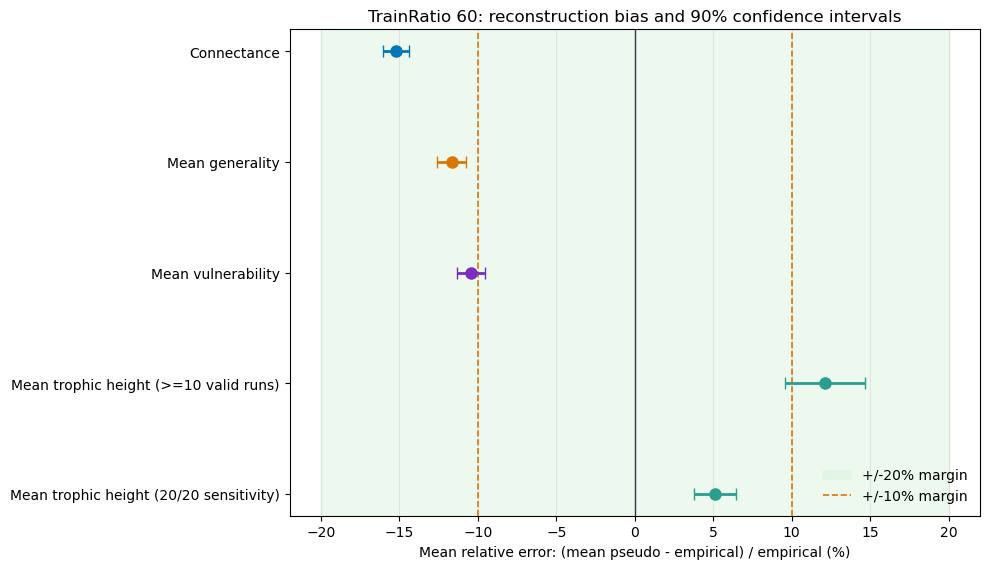

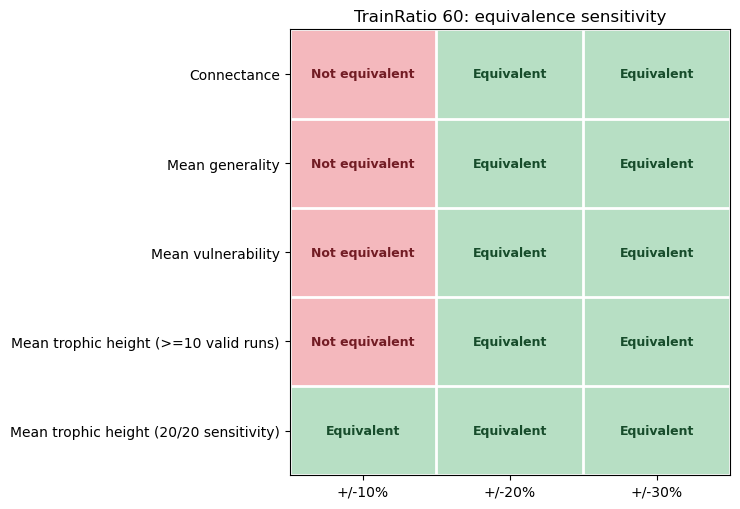

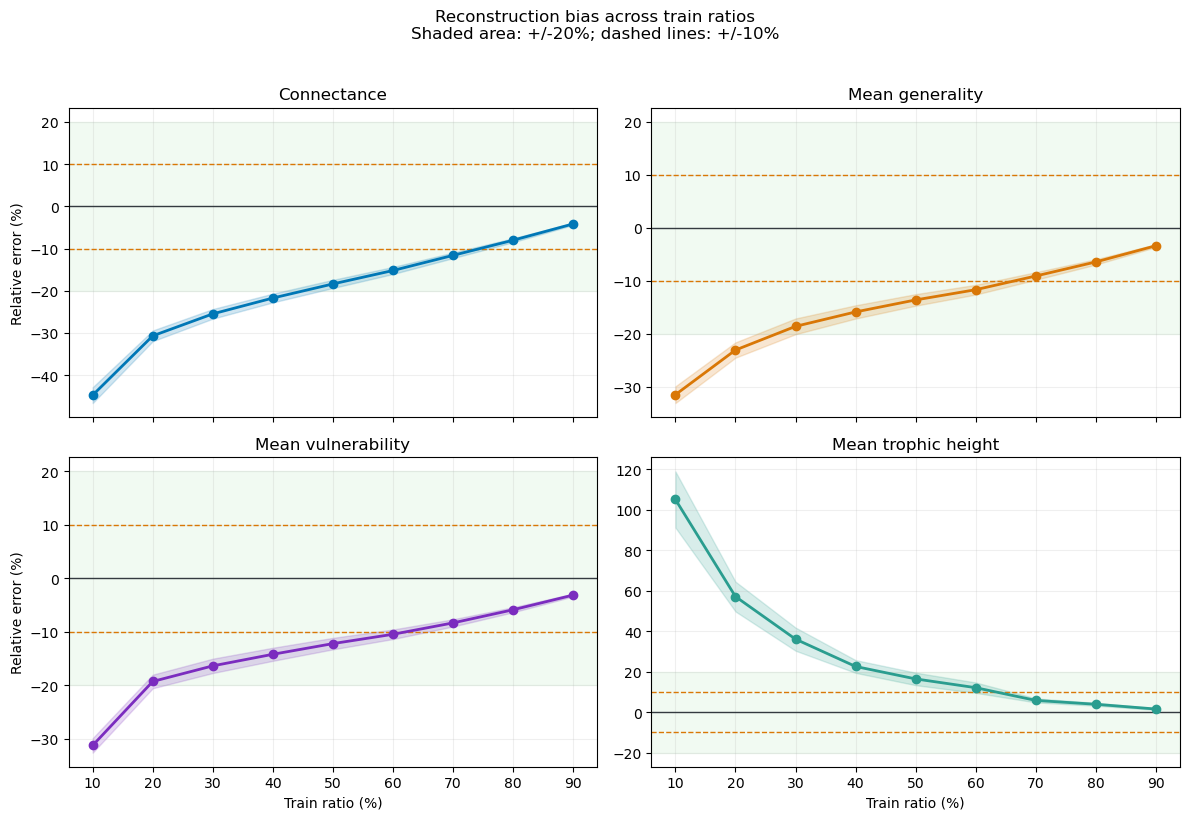

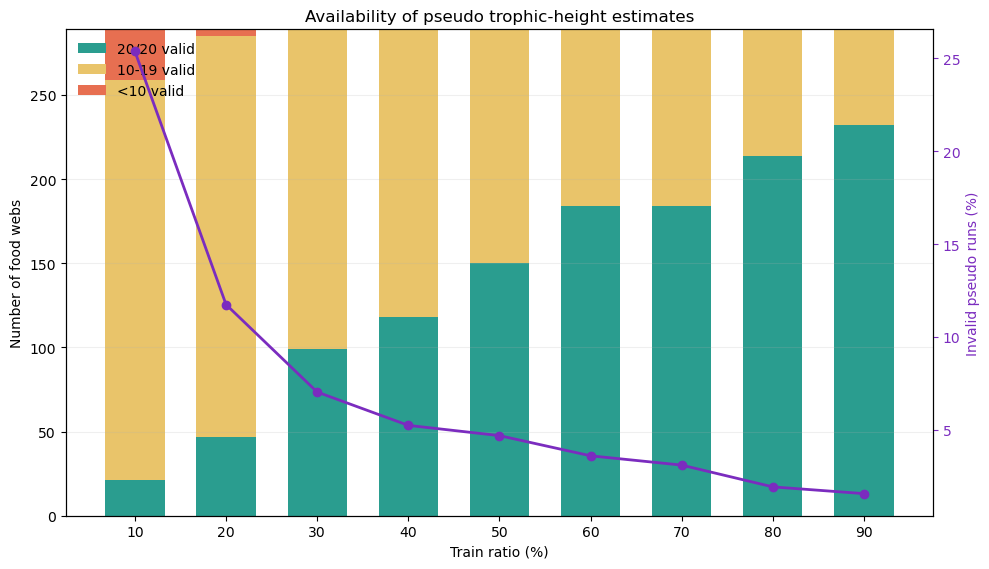

## Trophic-height discrepancies with Lachlan

,Food web,Ecosystem,MATLAB log,Lachlan,Difference,MATLAB species,Lachlan species
53,Carpinteria,terrestrial aboveground,8.2526,6.7514,+1.5012,160,160
55,Chesapeake Bay,marine,4.7052,3.4081,+1.2971,521,521
271,Sutton Stream,streams,2.1089,2.0712,+0.0377,88,87
30,Blackrock Stream,streams,2.1594,2.1378,+0.0216,88,87
105,Gearagh,terrestrial belowground,2.7244,2.7260,-0.0016,117,116


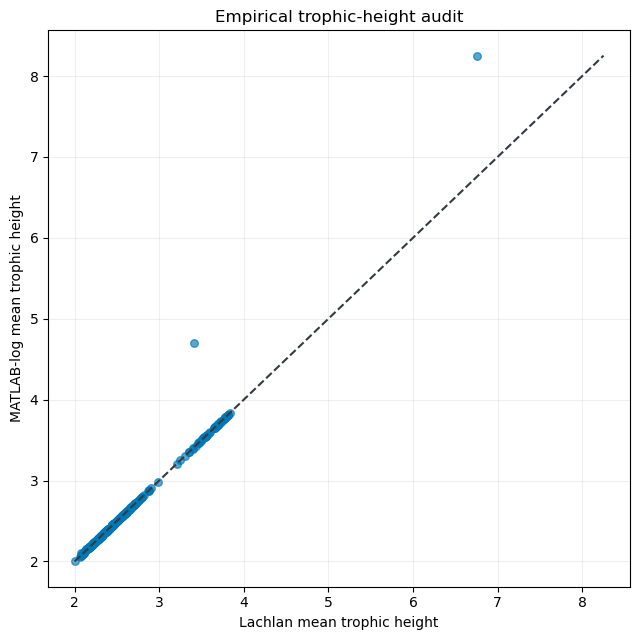

## Empirical reference values

,Reference,Metric,SourceMetric,NumFoodWebs,Mean,SD,SEM,SDPercentOfMean,SEMPercentOfMean
0,WLNMLogs,Connectance,Connectance,290,0.1324,0.0473,0.0028,35.69%,2.10%
1,WLNMLogs,MeanGenerality,MeanGenerality,290,10.5377,7.3473,0.4315,69.72%,4.09%
2,WLNMLogs,MeanVulnerability,MeanVulnerability,290,8.2904,5.6076,0.3293,67.64%,3.97%
3,WLNMLogs,MeanTrophicHeight,NetworkXMeanTrophicLevel,289,2.6438,0.6028,0.0355,22.80%,1.34%
4,LachlanMeanTLCSV,MeanTrophicHeight,NetworkX trophic_levels plus Lachlan postprocessing,289,2.6340,0.5478,0.0322,20.80%,1.22%


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src" / "matlab").exists():
            return candidate
    raise FileNotFoundError("Could not locate qmul-phd-framework repository root.")


ROOT = find_repo_root()
ATHEN_DIR = (
    ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)

eq60 = pd.read_csv(ATHEN_DIR / "athen_equivalence_sensitivity_train60.csv")
eq_all = pd.read_csv(ATHEN_DIR / "athen_equivalence_sensitivity_all_ratios.csv")
metric60 = pd.read_csv(ATHEN_DIR / "athen_metric_summary_train60.csv")
validity = pd.read_csv(ATHEN_DIR / "athen_trophic_height_validity.csv")
audit = pd.read_csv(ATHEN_DIR / "athen_trophic_height_lachlan_audit.csv")
references = pd.read_csv(ATHEN_DIR / "athen_empirical_reference_summary.csv")

METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
    "MeanTrophicHeight": "Mean trophic height",
}

METRIC_COLORS = {
    "Connectance": "#0077b6",
    "MeanGenerality": "#d97706",
    "MeanVulnerability": "#7b2cbf",
    "MeanTrophicHeight": "#2a9d8f",
}

SAVE_FIGURES = False
FIGURE_DIR = ATHEN_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)


def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


# ---------------------------------------------------------------------
# TrainRatio 60 summary table
# ---------------------------------------------------------------------
primary_mask = (
    (eq60["AnalysisPopulation"] == "PrimaryMean20")
    | (eq60["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns")
    | (
        (eq60["Metric"] == "MeanTrophicHeight")
        & (eq60["AnalysisPopulation"] == "Complete20Sensitivity")
    )
)

selected60 = eq60.loc[primary_mask].copy()

selected60["DisplayMetric"] = selected60["Metric"].map(METRIC_LABELS)
selected60.loc[
    selected60["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns",
    "DisplayMetric",
] = "Mean trophic height (>=10 valid runs)"
selected60.loc[
    selected60["AnalysisPopulation"] == "Complete20Sensitivity",
    "DisplayMetric",
] = "Mean trophic height (20/20 sensitivity)"

descriptive = (
    selected60
    .drop_duplicates(["DisplayMetric", "AnalysisPopulation"])
    [[
        "DisplayMetric",
        "AnalysisPopulation",
        "NumFoodWebs",
        "MeanEmpirical",
        "MeanPseudo",
        "MeanDelta",
        "MeanRelativeErrorPercent",
        "RelativeCI90LowerPercent",
        "RelativeCI90UpperPercent",
    ]]
    .copy()
)

descriptive["90% CI relative error"] = descriptive.apply(
    lambda row: (
        f"[{row['RelativeCI90LowerPercent']:.2f}%, "
        f"{row['RelativeCI90UpperPercent']:.2f}%]"
    ),
    axis=1,
)

sensitivity = selected60.pivot(
    index="DisplayMetric",
    columns="MarginPercent",
    values="Equivalent",
).reset_index()

sensitivity = sensitivity.rename(
    columns={
        10.0: "Eq +/-10%",
        20.0: "Eq +/-20%",
        30.0: "Eq +/-30%",
    }
)

summary_table = descriptive.merge(sensitivity, on="DisplayMetric", how="left")
summary_table = summary_table.rename(
    columns={
        "DisplayMetric": "Metric",
        "AnalysisPopulation": "Population",
        "NumFoodWebs": "N webs",
        "MeanEmpirical": "Empirical mean",
        "MeanPseudo": "Pseudo mean",
        "MeanDelta": "Mean delta",
        "MeanRelativeErrorPercent": "Relative bias (%)",
    }
)

eq_columns = ["Eq +/-10%", "Eq +/-20%", "Eq +/-30%"]
for column in eq_columns:
    summary_table[column] = summary_table[column].map({1: "Yes", 0: "No"})


def shade_equivalence(column):
    return [
        (
            "background-color: #d8f3dc; color: #174c2b; font-weight: 600"
            if value == "Yes"
            else "background-color: #f8d7da; color: #721c24; font-weight: 600"
        )
        for value in column
    ]


display(Markdown("## TrainRatio 60: web-level equivalence results"))

styled_summary = (
    summary_table[
        [
            "Metric",
            "Population",
            "N webs",
            "Empirical mean",
            "Pseudo mean",
            "Mean delta",
            "Relative bias (%)",
            "90% CI relative error",
            *eq_columns,
        ]
    ]
    .style
    .format(
        {
            "Empirical mean": "{:.4f}",
            "Pseudo mean": "{:.4f}",
            "Mean delta": "{:+.4f}",
            "Relative bias (%)": "{:+.2f}",
        }
    )
    .apply(shade_equivalence, subset=eq_columns)
)

display(styled_summary)


# ---------------------------------------------------------------------
# Figure 1: Forest plot for TrainRatio 60
# ---------------------------------------------------------------------
forest = selected60[selected60["MarginPercent"] == 20].copy()

plot_order = [
    "Connectance",
    "Mean generality",
    "Mean vulnerability",
    "Mean trophic height (>=10 valid runs)",
    "Mean trophic height (20/20 sensitivity)",
]

forest["PlotOrder"] = forest["DisplayMetric"].map(
    {name: index for index, name in enumerate(plot_order)}
)
forest = forest.sort_values("PlotOrder", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.8))

ax.axvspan(-20, 20, color="#d8f3dc", alpha=0.45, label="+/-20% margin")
ax.axvline(-10, color="#d97706", linestyle="--", linewidth=1.2)
ax.axvline(10, color="#d97706", linestyle="--", linewidth=1.2, label="+/-10% margin")
ax.axvline(0, color="#343a40", linewidth=1)

for y, (_, row) in enumerate(forest.iterrows()):
    mean = row["MeanRelativeErrorPercent"]
    lower = row["RelativeCI90LowerPercent"]
    upper = row["RelativeCI90UpperPercent"]
    color = METRIC_COLORS[row["Metric"]]

    ax.errorbar(
        mean,
        y,
        xerr=[[mean - lower], [upper - mean]],
        fmt="o",
        color=color,
        ecolor=color,
        markersize=8,
        capsize=4,
        linewidth=2,
    )

ax.set_yticks(range(len(forest)))
ax.set_yticklabels(forest["DisplayMetric"])
ax.set_xlabel("Mean relative error: (mean pseudo - empirical) / empirical (%)")
ax.set_title("TrainRatio 60: reconstruction bias and 90% confidence intervals")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

finish_figure(fig, "athen_train60_relative_error_forest.png")


# ---------------------------------------------------------------------
# Figure 2: Equivalence sensitivity matrix at TrainRatio 60
# ---------------------------------------------------------------------
heat = selected60.pivot(
    index="DisplayMetric",
    columns="MarginPercent",
    values="Equivalent",
).reindex(plot_order)

heat = heat[[10.0, 20.0, 30.0]]

fig, ax = plt.subplots(figsize=(7.5, 5.2))
cmap = ListedColormap(["#f4b8bd", "#b7dfc4"])

ax.imshow(heat.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f"+/-{int(value)}%" for value in heat.columns])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("TrainRatio 60: equivalence sensitivity")

for row_index in range(heat.shape[0]):
    for column_index in range(heat.shape[1]):
        value = int(heat.iloc[row_index, column_index])
        ax.text(
            column_index,
            row_index,
            "Equivalent" if value else "Not equivalent",
            ha="center",
            va="center",
            fontsize=9,
            color="#174c2b" if value else "#721c24",
            fontweight="bold",
        )

ax.set_xticks(np.arange(-0.5, len(heat.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

finish_figure(fig, "athen_train60_equivalence_sensitivity.png")


# ---------------------------------------------------------------------
# Figure 3: Relative bias across all train ratios
# ---------------------------------------------------------------------
trend = eq_all[
    (eq_all["MarginPercent"] == 20)
    & (eq_all["AnalysisPopulation"] != "Complete20Sensitivity")
].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, metric in zip(axes, METRIC_LABELS):
    data = trend[trend["Metric"] == metric].sort_values("TrainRatio")
    color = METRIC_COLORS[metric]

    ax.axhspan(-20, 20, color="#d8f3dc", alpha=0.35)
    ax.axhline(-10, color="#d97706", linestyle="--", linewidth=1)
    ax.axhline(10, color="#d97706", linestyle="--", linewidth=1)
    ax.axhline(0, color="#343a40", linewidth=1)

    ax.plot(
        data["TrainRatio"],
        data["MeanRelativeErrorPercent"],
        color=color,
        marker="o",
        linewidth=2,
    )
    ax.fill_between(
        data["TrainRatio"],
        data["RelativeCI90LowerPercent"],
        data["RelativeCI90UpperPercent"],
        color=color,
        alpha=0.18,
    )

    ax.set_title(METRIC_LABELS[metric])
    ax.set_xticks(range(10, 100, 10))
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Relative error (%)")
axes[2].set_ylabel("Relative error (%)")
axes[2].set_xlabel("Train ratio (%)")
axes[3].set_xlabel("Train ratio (%)")

fig.suptitle(
    "Reconstruction bias across train ratios\n"
    "Shaded area: +/-20%; dashed lines: +/-10%",
    y=1.02,
)

finish_figure(fig, "athen_relative_error_all_train_ratios.png")


# ---------------------------------------------------------------------
# Figure 4: Trophic-height data validity
# ---------------------------------------------------------------------
validity = validity.sort_values("TrainRatio").copy()
validity["PseudoMetricInvalidPercent"] = (
    100
    * validity["PseudoMetricInvalidRuns"]
    / (validity["PseudoMetricValidRuns"] + validity["PseudoMetricInvalidRuns"])
)

fig, ax = plt.subplots(figsize=(10, 5.8))

x = np.arange(len(validity))
width = 0.65

ax.bar(
    x,
    validity["Complete20FoodWebs"],
    width,
    label="20/20 valid",
    color="#2a9d8f",
)
ax.bar(
    x,
    validity["Partial10To19FoodWebs"],
    width,
    bottom=validity["Complete20FoodWebs"],
    label="10-19 valid",
    color="#e9c46a",
)
ax.bar(
    x,
    validity["Below10ValidFoodWebs"],
    width,
    bottom=(
        validity["Complete20FoodWebs"]
        + validity["Partial10To19FoodWebs"]
    ),
    label="<10 valid",
    color="#e76f51",
)

ax.set_xticks(x)
ax.set_xticklabels(validity["TrainRatio"].astype(int))
ax.set_xlabel("Train ratio (%)")
ax.set_ylabel("Number of food webs")
ax.set_title("Availability of pseudo trophic-height estimates")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.2)

ax2 = ax.twinx()
ax2.plot(
    x,
    validity["PseudoMetricInvalidPercent"],
    color="#7b2cbf",
    marker="o",
    linewidth=2,
    label="Invalid pseudo runs (%)",
)
ax2.set_ylabel("Invalid pseudo runs (%)", color="#7b2cbf")
ax2.tick_params(axis="y", colors="#7b2cbf")

finish_figure(fig, "athen_trophic_height_validity.png")


# ---------------------------------------------------------------------
# Figure 5: MATLAB logs versus Lachlan trophic-height values
# ---------------------------------------------------------------------
audit_valid = audit[
    audit["LogEmpiricalTrophicHeight"].notna()
    & audit["LachlanTrophicHeight"].notna()
].copy()

mismatches = (
    audit_valid[audit_valid["AbsoluteDifference"] > 0.001]
    .sort_values("AbsoluteDifference", ascending=False)
)

display(Markdown("## Trophic-height discrepancies with Lachlan"))

display(
    mismatches[
        [
            "BaseFoodWeb",
            "EcosystemType",
            "LogEmpiricalTrophicHeight",
            "LachlanTrophicHeight",
            "DifferenceLogMinusLachlan",
            "LogNumSpeciesFull",
            "LachlanNumSpeciesFull",
        ]
    ]
    .rename(
        columns={
            "BaseFoodWeb": "Food web",
            "EcosystemType": "Ecosystem",
            "LogEmpiricalTrophicHeight": "MATLAB log",
            "LachlanTrophicHeight": "Lachlan",
            "DifferenceLogMinusLachlan": "Difference",
            "LogNumSpeciesFull": "MATLAB species",
            "LachlanNumSpeciesFull": "Lachlan species",
        }
    )
    .style
    .format(
        {
            "MATLAB log": "{:.4f}",
            "Lachlan": "{:.4f}",
            "Difference": "{:+.4f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(
    audit_valid["LachlanTrophicHeight"],
    audit_valid["LogEmpiricalTrophicHeight"],
    color="#0077b6",
    alpha=0.65,
    s=30,
)

minimum = min(
    audit_valid["LachlanTrophicHeight"].min(),
    audit_valid["LogEmpiricalTrophicHeight"].min(),
)
maximum = max(
    audit_valid["LachlanTrophicHeight"].max(),
    audit_valid["LogEmpiricalTrophicHeight"].max(),
)

ax.plot([minimum, maximum], [minimum, maximum], color="#343a40", linestyle="--")
ax.set_xlabel("Lachlan mean trophic height")
ax.set_ylabel("MATLAB-log mean trophic height")
ax.set_title("Empirical trophic-height audit")
ax.grid(alpha=0.2)

finish_figure(fig, "athen_trophic_height_lachlan_audit.png")


# ---------------------------------------------------------------------
# Empirical reference summary
# ---------------------------------------------------------------------
display(Markdown("## Empirical reference values"))

display(
    references.style.format(
        {
            "Mean": "{:.4f}",
            "SD": "{:.4f}",
            "SEM": "{:.4f}",
            "SDPercentOfMean": "{:.2f}%",
            "SEMPercentOfMean": "{:.2f}%",
        }
    )
)

## TrainRatio 60: equivalence sensitivity

,Metric,Population,N webs,Empirical mean,Pseudo mean,Mean delta,Relative bias (%),90% CI,Eq +/-10%,Eq +/-15%,Eq +/-20%,Eq +/-30%
0,Connectance,PrimaryMean20,290,0.1324,0.1126,-0.0198,-15.20,"[-16.04%, -14.37%]",No,No,Yes,Yes
1,Mean generality,PrimaryMean20,290,10.5377,9.0045,-1.5332,-11.68,"[-12.59%, -10.76%]",No,Yes,Yes,Yes
2,Mean vulnerability,PrimaryMean20,290,8.2904,7.1972,-1.0932,-10.44,"[-11.33%, -9.55%]",No,Yes,Yes,Yes
3,Mean trophic height (>=10 valid runs),ConditionalAtLeast10ValidRuns,289,2.6438,3.0399,+0.3961,+12.12,"[9.55%, 14.68%]",No,Yes,Yes,Yes
4,Mean trophic height (20/20 sensitivity),Complete20Sensitivity,184,2.4681,2.6146,+0.1464,+5.12,"[3.77%, 6.47%]",Yes,Yes,Yes,Yes


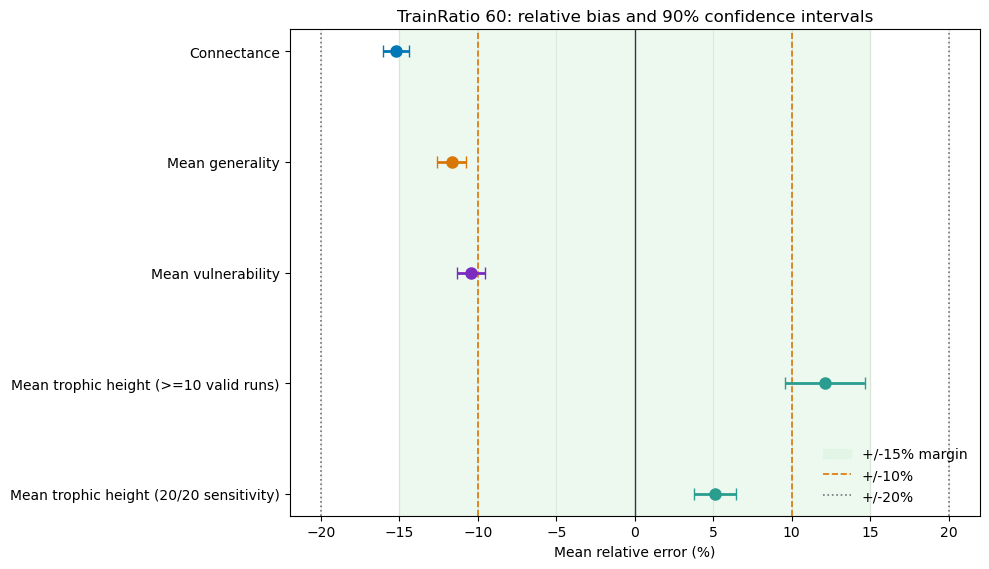

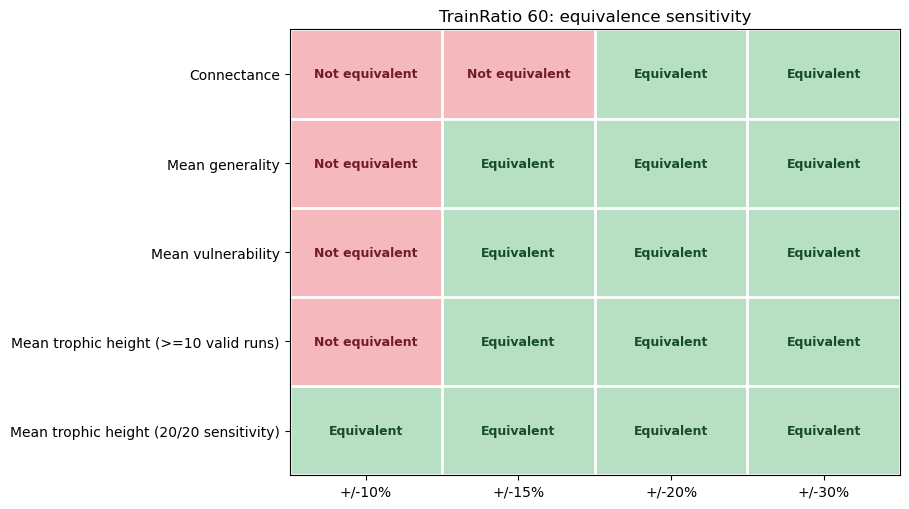

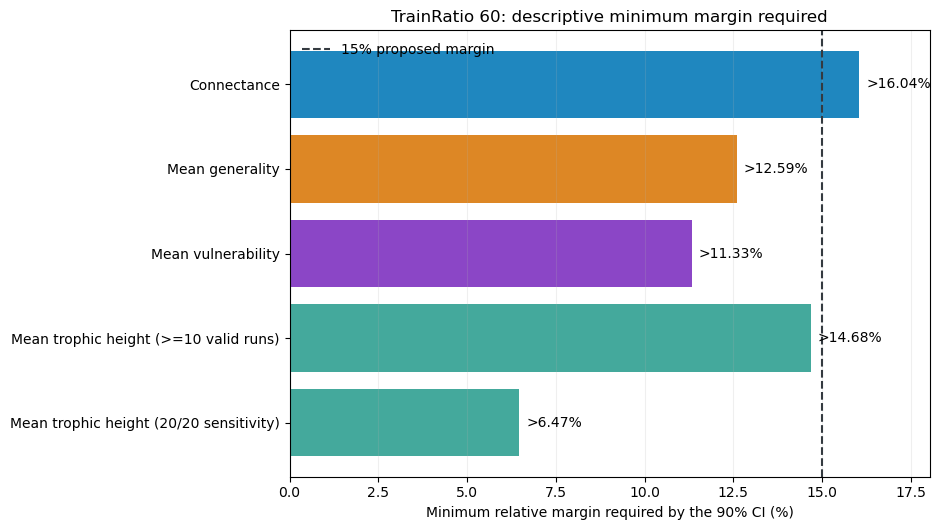

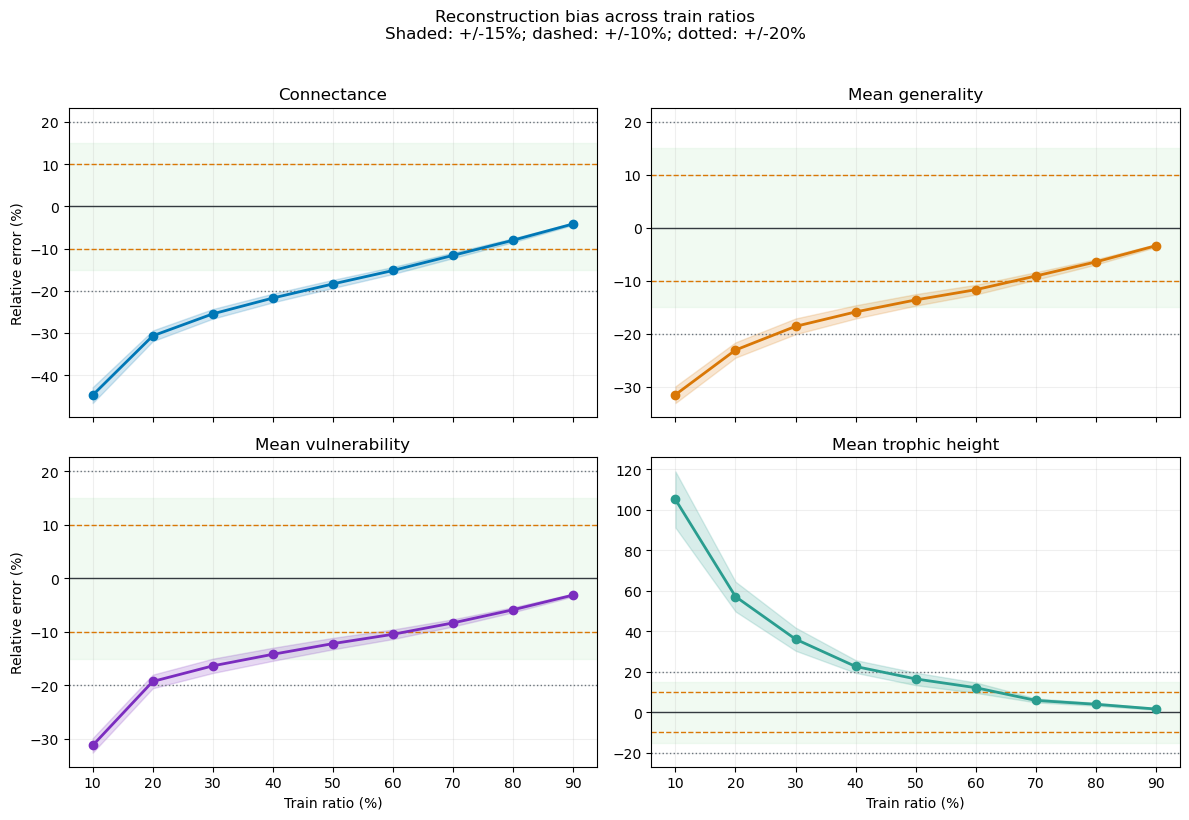

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown


# ---------------------------------------------------------------------
# Paths and data
# ---------------------------------------------------------------------
def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src" / "matlab").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


ROOT = find_repo_root()

ATHEN_DIR = (
    ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)

FIGURE_DIR = ATHEN_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = True
MARGINS = [10, 15, 20, 30]

eq60 = pd.read_csv(ATHEN_DIR / "athen_equivalence_sensitivity_train60.csv")
eq_all = pd.read_csv(ATHEN_DIR / "athen_equivalence_sensitivity_all_ratios.csv")
minimum60 = pd.read_csv(ATHEN_DIR / "athen_minimum_margin_required_train60.csv")

METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
    "MeanTrophicHeight": "Mean trophic height",
}

METRIC_COLORS = {
    "Connectance": "#0077b6",
    "MeanGenerality": "#d97706",
    "MeanVulnerability": "#7b2cbf",
    "MeanTrophicHeight": "#2a9d8f",
}


def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(
            FIGURE_DIR / filename,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
    plt.show()


# ---------------------------------------------------------------------
# Select primary and trophic sensitivity populations
# ---------------------------------------------------------------------
selected = eq60[
    (eq60["AnalysisPopulation"] == "PrimaryMean20")
    | (eq60["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns")
    | (eq60["AnalysisPopulation"] == "Complete20Sensitivity")
].copy()

selected["DisplayMetric"] = selected["Metric"].map(METRIC_LABELS)

selected.loc[
    selected["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns",
    "DisplayMetric",
] = "Mean trophic height (>=10 valid runs)"

selected.loc[
    selected["AnalysisPopulation"] == "Complete20Sensitivity",
    "DisplayMetric",
] = "Mean trophic height (20/20 sensitivity)"

PLOT_ORDER = [
    "Connectance",
    "Mean generality",
    "Mean vulnerability",
    "Mean trophic height (>=10 valid runs)",
    "Mean trophic height (20/20 sensitivity)",
]


# ---------------------------------------------------------------------
# Results table
# ---------------------------------------------------------------------
descriptive = (
    selected
    .drop_duplicates(["DisplayMetric", "AnalysisPopulation"])
    [[
        "DisplayMetric",
        "AnalysisPopulation",
        "NumFoodWebs",
        "MeanEmpirical",
        "MeanPseudo",
        "MeanDelta",
        "MeanRelativeErrorPercent",
        "RelativeCI90LowerPercent",
        "RelativeCI90UpperPercent",
    ]]
    .copy()
)

descriptive["90% CI"] = descriptive.apply(
    lambda row: (
        f"[{row['RelativeCI90LowerPercent']:.2f}%, "
        f"{row['RelativeCI90UpperPercent']:.2f}%]"
    ),
    axis=1,
)

sensitivity = selected.pivot(
    index="DisplayMetric",
    columns="MarginPercent",
    values="Equivalent",
).reset_index()

sensitivity = sensitivity.rename(
    columns={margin: f"Eq +/-{margin}%" for margin in MARGINS}
)

summary = descriptive.merge(sensitivity, on="DisplayMetric", how="left")

summary = summary.rename(
    columns={
        "DisplayMetric": "Metric",
        "AnalysisPopulation": "Population",
        "NumFoodWebs": "N webs",
        "MeanEmpirical": "Empirical mean",
        "MeanPseudo": "Pseudo mean",
        "MeanDelta": "Mean delta",
        "MeanRelativeErrorPercent": "Relative bias (%)",
    }
)

equivalence_columns = [f"Eq +/-{margin}%" for margin in MARGINS]

for column in equivalence_columns:
    summary[column] = summary[column].map({1: "Yes", 0: "No"})


def shade_equivalence(column):
    return [
        (
            "background-color: #d8f3dc; color: #174c2b; font-weight: 600"
            if value == "Yes"
            else "background-color: #f8d7da; color: #721c24; font-weight: 600"
        )
        for value in column
    ]


display(Markdown("## TrainRatio 60: equivalence sensitivity"))

display(
    summary[
        [
            "Metric",
            "Population",
            "N webs",
            "Empirical mean",
            "Pseudo mean",
            "Mean delta",
            "Relative bias (%)",
            "90% CI",
            *equivalence_columns,
        ]
    ]
    .style
    .format(
        {
            "Empirical mean": "{:.4f}",
            "Pseudo mean": "{:.4f}",
            "Mean delta": "{:+.4f}",
            "Relative bias (%)": "{:+.2f}",
        }
    )
    .apply(shade_equivalence, subset=equivalence_columns)
)


# ---------------------------------------------------------------------
# Forest plot highlighting the proposed 15% margin
# ---------------------------------------------------------------------
forest = selected[selected["MarginPercent"] == 15].copy()

forest["PlotOrder"] = forest["DisplayMetric"].map(
    {name: index for index, name in enumerate(PLOT_ORDER)}
)
forest = forest.sort_values("PlotOrder", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.8))

ax.axvspan(-15, 15, color="#d8f3dc", alpha=0.45, label="+/-15% margin")
ax.axvline(-10, color="#d97706", linestyle="--", linewidth=1.2)
ax.axvline(10, color="#d97706", linestyle="--", linewidth=1.2, label="+/-10%")
ax.axvline(-20, color="#6c757d", linestyle=":", linewidth=1.2)
ax.axvline(20, color="#6c757d", linestyle=":", linewidth=1.2, label="+/-20%")
ax.axvline(0, color="#343a40", linewidth=1)

for y, (_, row) in enumerate(forest.iterrows()):
    mean = row["MeanRelativeErrorPercent"]
    lower = row["RelativeCI90LowerPercent"]
    upper = row["RelativeCI90UpperPercent"]

    ax.errorbar(
        mean,
        y,
        xerr=[[mean - lower], [upper - mean]],
        fmt="o",
        color=METRIC_COLORS[row["Metric"]],
        ecolor=METRIC_COLORS[row["Metric"]],
        markersize=8,
        capsize=4,
        linewidth=2,
    )

ax.set_yticks(range(len(forest)))
ax.set_yticklabels(forest["DisplayMetric"])
ax.set_xlabel("Mean relative error (%)")
ax.set_title("TrainRatio 60: relative bias and 90% confidence intervals")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

finish_figure(fig, "athen_train60_relative_error_forest.png")


# ---------------------------------------------------------------------
# Equivalence sensitivity matrix: 10%, 15%, 20%, 30%
# ---------------------------------------------------------------------
heat = selected.pivot(
    index="DisplayMetric",
    columns="MarginPercent",
    values="Equivalent",
).reindex(PLOT_ORDER)[MARGINS]

fig, ax = plt.subplots(figsize=(9.2, 5.2))

ax.imshow(
    heat.values,
    cmap=ListedColormap(["#f4b8bd", "#b7dfc4"]),
    vmin=0,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(range(len(MARGINS)))
ax.set_xticklabels([f"+/-{margin}%" for margin in MARGINS])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("TrainRatio 60: equivalence sensitivity")

for row_index in range(heat.shape[0]):
    for column_index in range(heat.shape[1]):
        value = int(heat.iloc[row_index, column_index])

        ax.text(
            column_index,
            row_index,
            "Equivalent" if value else "Not equivalent",
            ha="center",
            va="center",
            fontsize=9,
            color="#174c2b" if value else "#721c24",
            fontweight="bold",
        )

ax.set_xticks(np.arange(-0.5, len(MARGINS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

finish_figure(fig, "athen_train60_equivalence_sensitivity.png")


# ---------------------------------------------------------------------
# Minimum descriptive margin required
# ---------------------------------------------------------------------
minimum = minimum60.copy()

minimum["DisplayMetric"] = minimum["Metric"].map(METRIC_LABELS)

minimum.loc[
    minimum["AnalysisPopulation"] == "ConditionalAtLeast10ValidRuns",
    "DisplayMetric",
] = "Mean trophic height (>=10 valid runs)"

minimum.loc[
    minimum["AnalysisPopulation"] == "Complete20Sensitivity",
    "DisplayMetric",
] = "Mean trophic height (20/20 sensitivity)"

minimum["PlotOrder"] = minimum["DisplayMetric"].map(
    {name: index for index, name in enumerate(PLOT_ORDER)}
)
minimum = minimum.sort_values("PlotOrder", ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 5.4))

colors = [METRIC_COLORS[metric] for metric in minimum["Metric"]]

bars = ax.barh(
    minimum["DisplayMetric"],
    minimum["MinimumMarginPercentExclusive"],
    color=colors,
    alpha=0.88,
)

ax.axvline(
    15,
    color="#343a40",
    linestyle="--",
    linewidth=1.5,
    label="15% proposed margin",
)

for bar, value in zip(bars, minimum["MinimumMarginPercentExclusive"]):
    ax.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f">{value:.2f}%",
        va="center",
    )

ax.set_xlabel("Minimum relative margin required by the 90% CI (%)")
ax.set_title("TrainRatio 60: descriptive minimum margin required")
ax.set_xlim(0, max(18, minimum["MinimumMarginPercentExclusive"].max() + 2))
ax.grid(axis="x", alpha=0.2)
ax.legend(frameon=False)

finish_figure(fig, "athen_train60_minimum_margin_required.png")


# ---------------------------------------------------------------------
# Relative bias across train ratios, with 15% highlighted
# ---------------------------------------------------------------------
trend = eq_all[
    (eq_all["MarginPercent"] == 15)
    & (eq_all["AnalysisPopulation"] != "Complete20Sensitivity")
].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, metric in zip(axes, METRIC_LABELS):
    data = trend[trend["Metric"] == metric].sort_values("TrainRatio")
    color = METRIC_COLORS[metric]

    ax.axhspan(-15, 15, color="#d8f3dc", alpha=0.35)
    ax.axhline(-10, color="#d97706", linestyle="--", linewidth=1)
    ax.axhline(10, color="#d97706", linestyle="--", linewidth=1)
    ax.axhline(-20, color="#6c757d", linestyle=":", linewidth=1)
    ax.axhline(20, color="#6c757d", linestyle=":", linewidth=1)
    ax.axhline(0, color="#343a40", linewidth=1)

    ax.plot(
        data["TrainRatio"],
        data["MeanRelativeErrorPercent"],
        color=color,
        marker="o",
        linewidth=2,
    )

    ax.fill_between(
        data["TrainRatio"],
        data["RelativeCI90LowerPercent"],
        data["RelativeCI90UpperPercent"],
        color=color,
        alpha=0.18,
    )

    ax.set_title(METRIC_LABELS[metric])
    ax.set_xticks(range(10, 100, 10))
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Relative error (%)")
axes[2].set_ylabel("Relative error (%)")
axes[2].set_xlabel("Train ratio (%)")
axes[3].set_xlabel("Train ratio (%)")

fig.suptitle(
    "Reconstruction bias across train ratios\n"
    "Shaded: +/-15%; dashed: +/-10%; dotted: +/-20%",
    y=1.02,
)

finish_figure(fig, "athen_relative_error_all_train_ratios.png")

1. Fix method to calculate trophic height using networkx

2. Calculate the 4 metrics for the Mill Stream from the Ledger et al. Es posible calcular la version no ponderada teniendo la version ponderada.

3. Calcular SEM

4. Mean trophic height

5. Columna K is comparable with column C (SEM)

6. The test is a sanity test

7. The test show that 2 correspond to each other



---



Fig 5, remove all the stacks, remove p and delta values

Add the description of the statistics to the method manuscript

## Mill Stream benchmarks

,Metric,Mean,SEM,Relative SEM (%),Definition
0,Connectance,0.0900,0.0100,11.11%,L / S^2 (unweighted)
1,Mean generality,11.6800,1.1100,9.50%,L / number of consumers (unweighted)
2,Mean vulnerability,6.6300,0.6300,9.50%,L / number of resources (unweighted)
3,Mean trophic height,1.5400,0.0040,0.26%,Prey-averaged trophic level; basal species included at level 1


## TrainRatio 60: overall results

,Metric,N webs,Empirical mean,Mean pseudo,Mean delta,Mean relative error (90% CI),Ledger relative SEM (%),Corresponds?
0,Connectance,290,0.1283,0.1090,-0.0193,"-15.19% [-16.03%, -14.35%]",11.11%,False
1,Mean generality,290,10.5418,9.0060,-1.5358,"-11.68% [-12.59%, -10.76%]",9.50%,False
2,Mean vulnerability,290,8.2909,7.1990,-1.0919,"-10.43% [-11.32%, -9.54%]",9.50%,False
3,Mean trophic height,290,2.1898,2.5425,+0.3526,"+11.56% [+8.99%, +14.12%]",0.26%,False


## Lakes

...

,Metric,N webs,Empirical mean,Mean pseudo,Mean delta,Mean relative error (90% CI),Ledger relative SEM (%),Corresponds?
3,Connectance,21,0.0999,0.0868,-0.0130,"-12.12% [-15.68%, -8.56%]",11.11%,False
8,Mean generality,21,11.7948,10.7295,-1.0653,"-10.47% [-14.09%, -6.84%]",9.50%,False
13,Mean vulnerability,21,8.7144,7.5901,-1.1243,"-11.28% [-14.87%, -7.69%]",9.50%,False
18,Mean trophic height,21,2.4018,2.7807,+0.3789,"+13.83% [+7.20%, +20.47%]",0.26%,False


## Terrestrial belowground

,Metric,N webs,Empirical mean,Mean pseudo,Mean delta,Mean relative error (90% CI),Ledger relative SEM (%),Corresponds?
4,Connectance,52,0.1141,0.0961,-0.0180,"-15.82% [-16.76%, -14.89%]",11.11%,False
9,Mean generality,52,15.1657,13.0091,-2.1566,"-14.27% [-15.35%, -13.19%]",9.50%,False
14,Mean vulnerability,52,15.1244,13.0798,-2.0446,"-13.42% [-14.62%, -12.22%]",9.50%,False
19,Mean trophic height,52,3.3558,4.6004,+1.2447,"+36.02% [+28.31%, +43.73%]",0.26%,False


## Figures

### Ledger Train60 Overall Relative Error

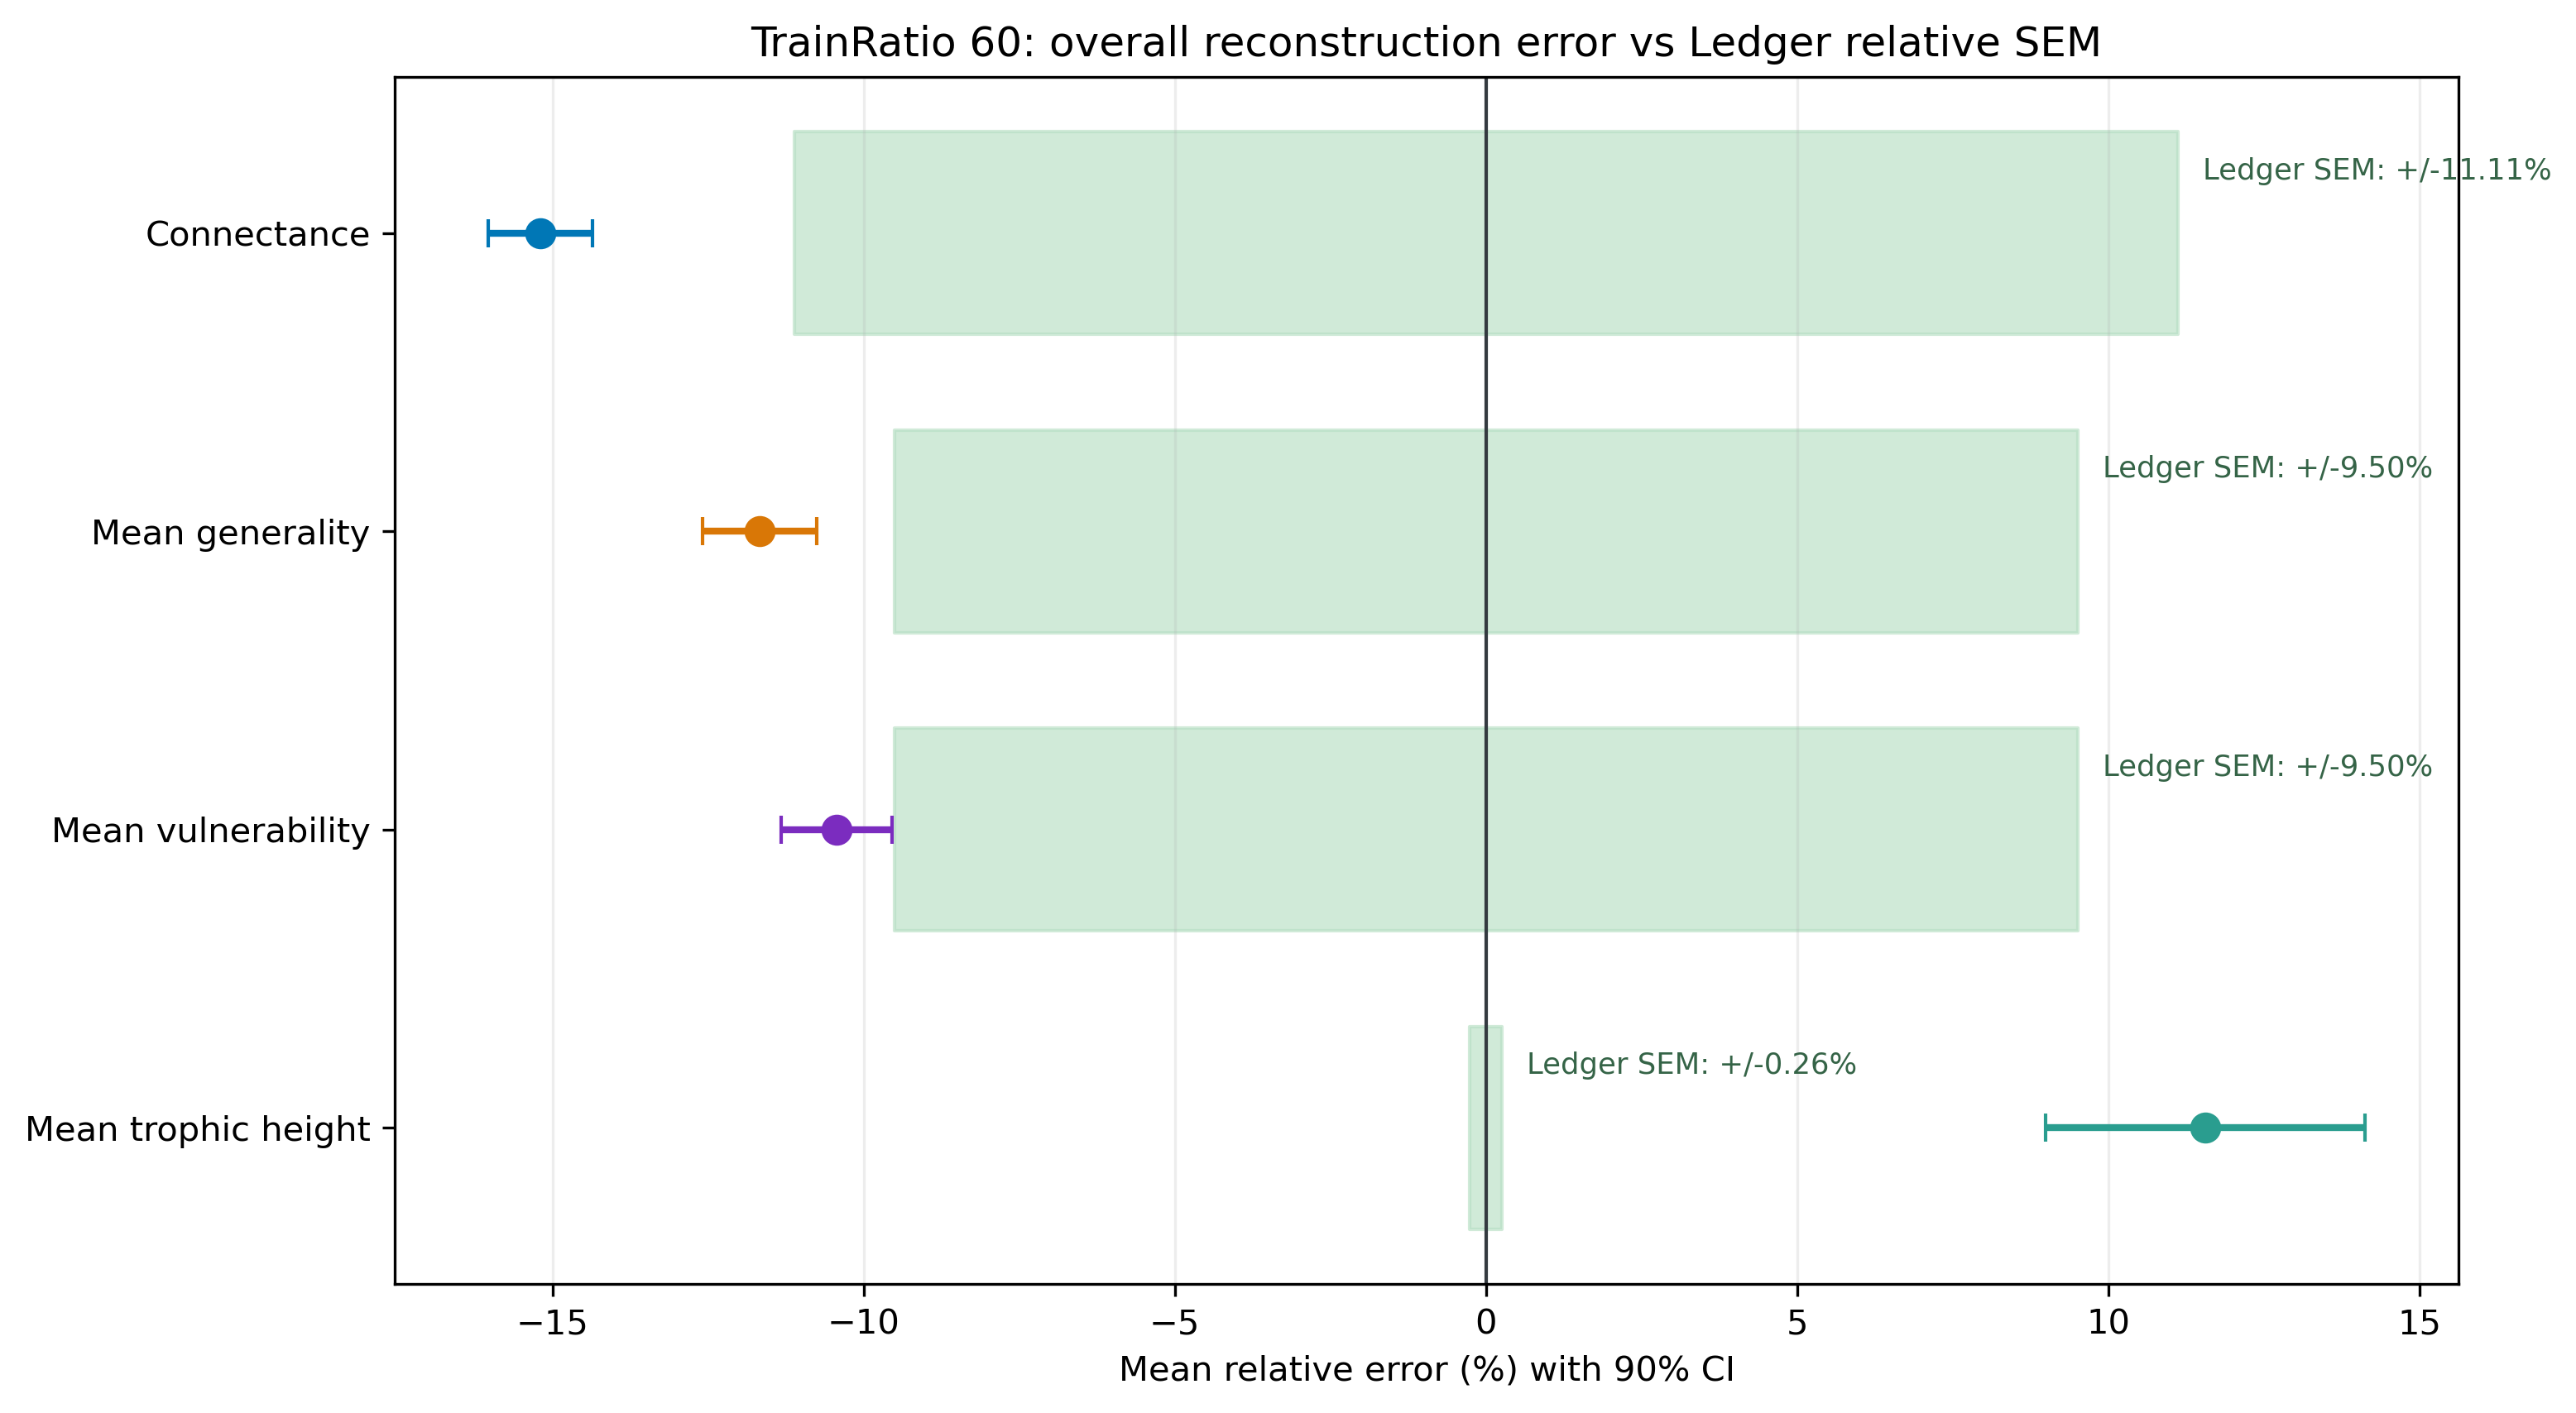

### Ledger Train60 Ecosystem Relative Error

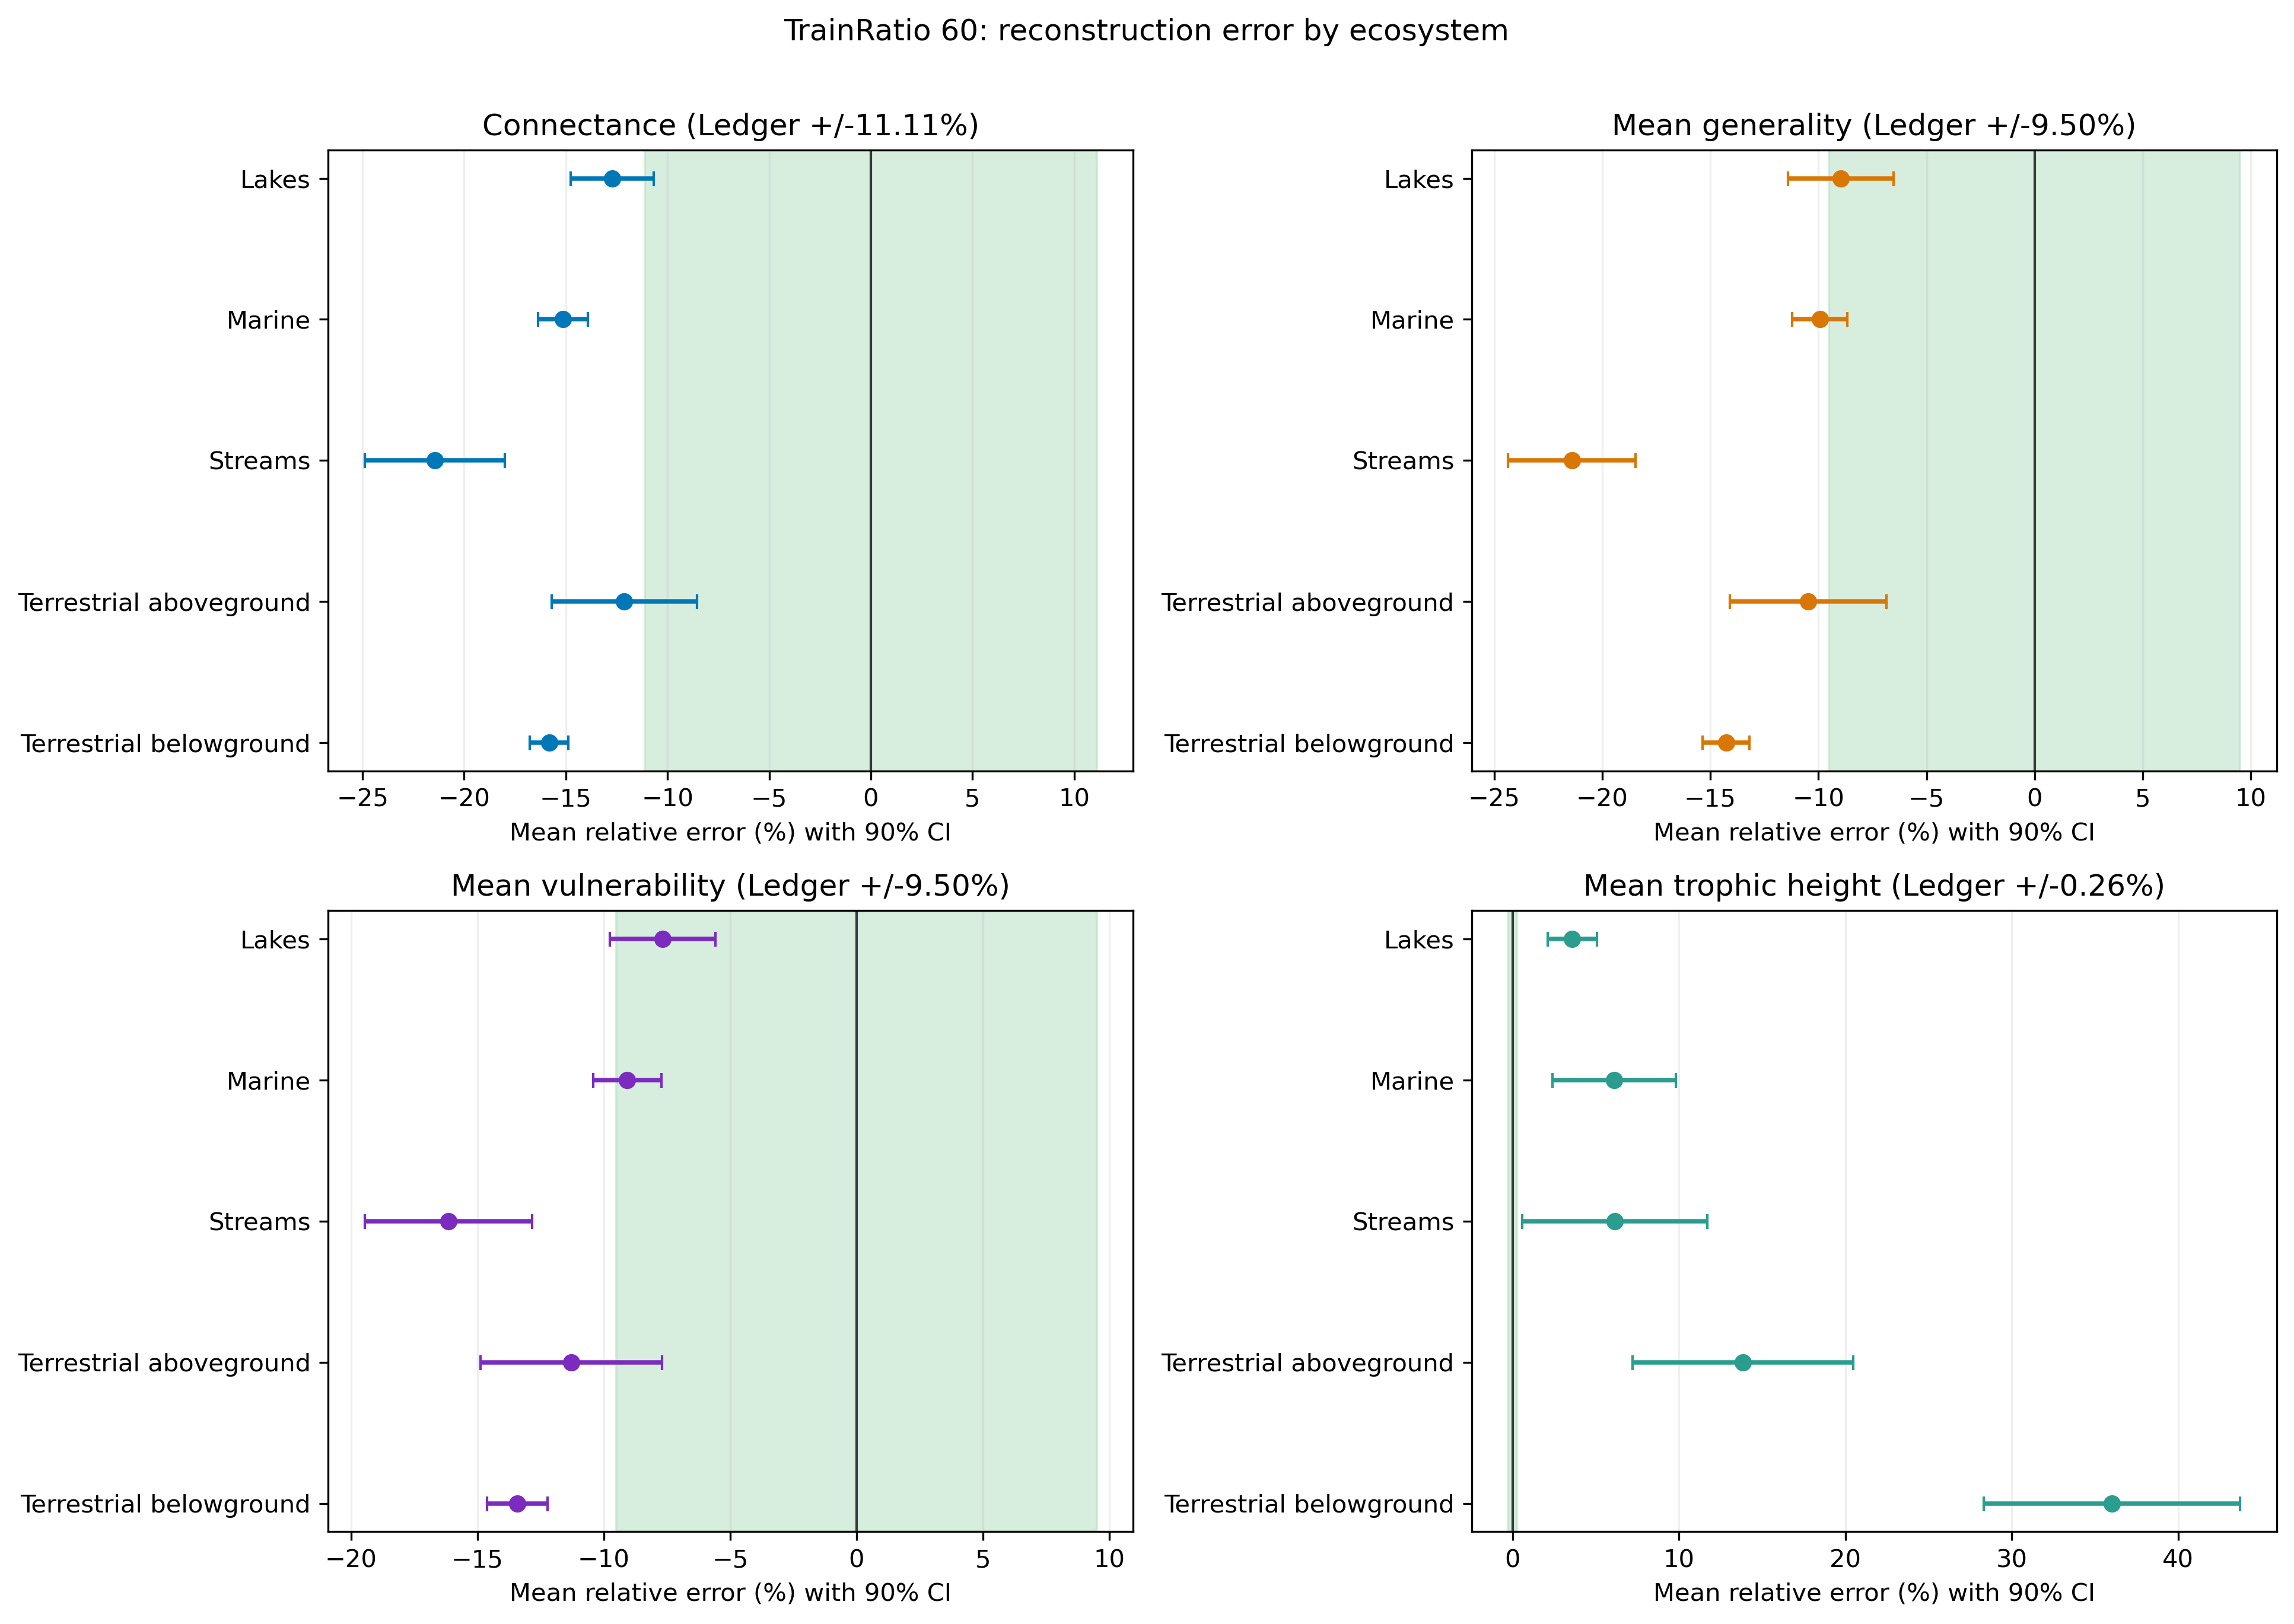

### Ledger Train60 Ecosystem Error Heatmap

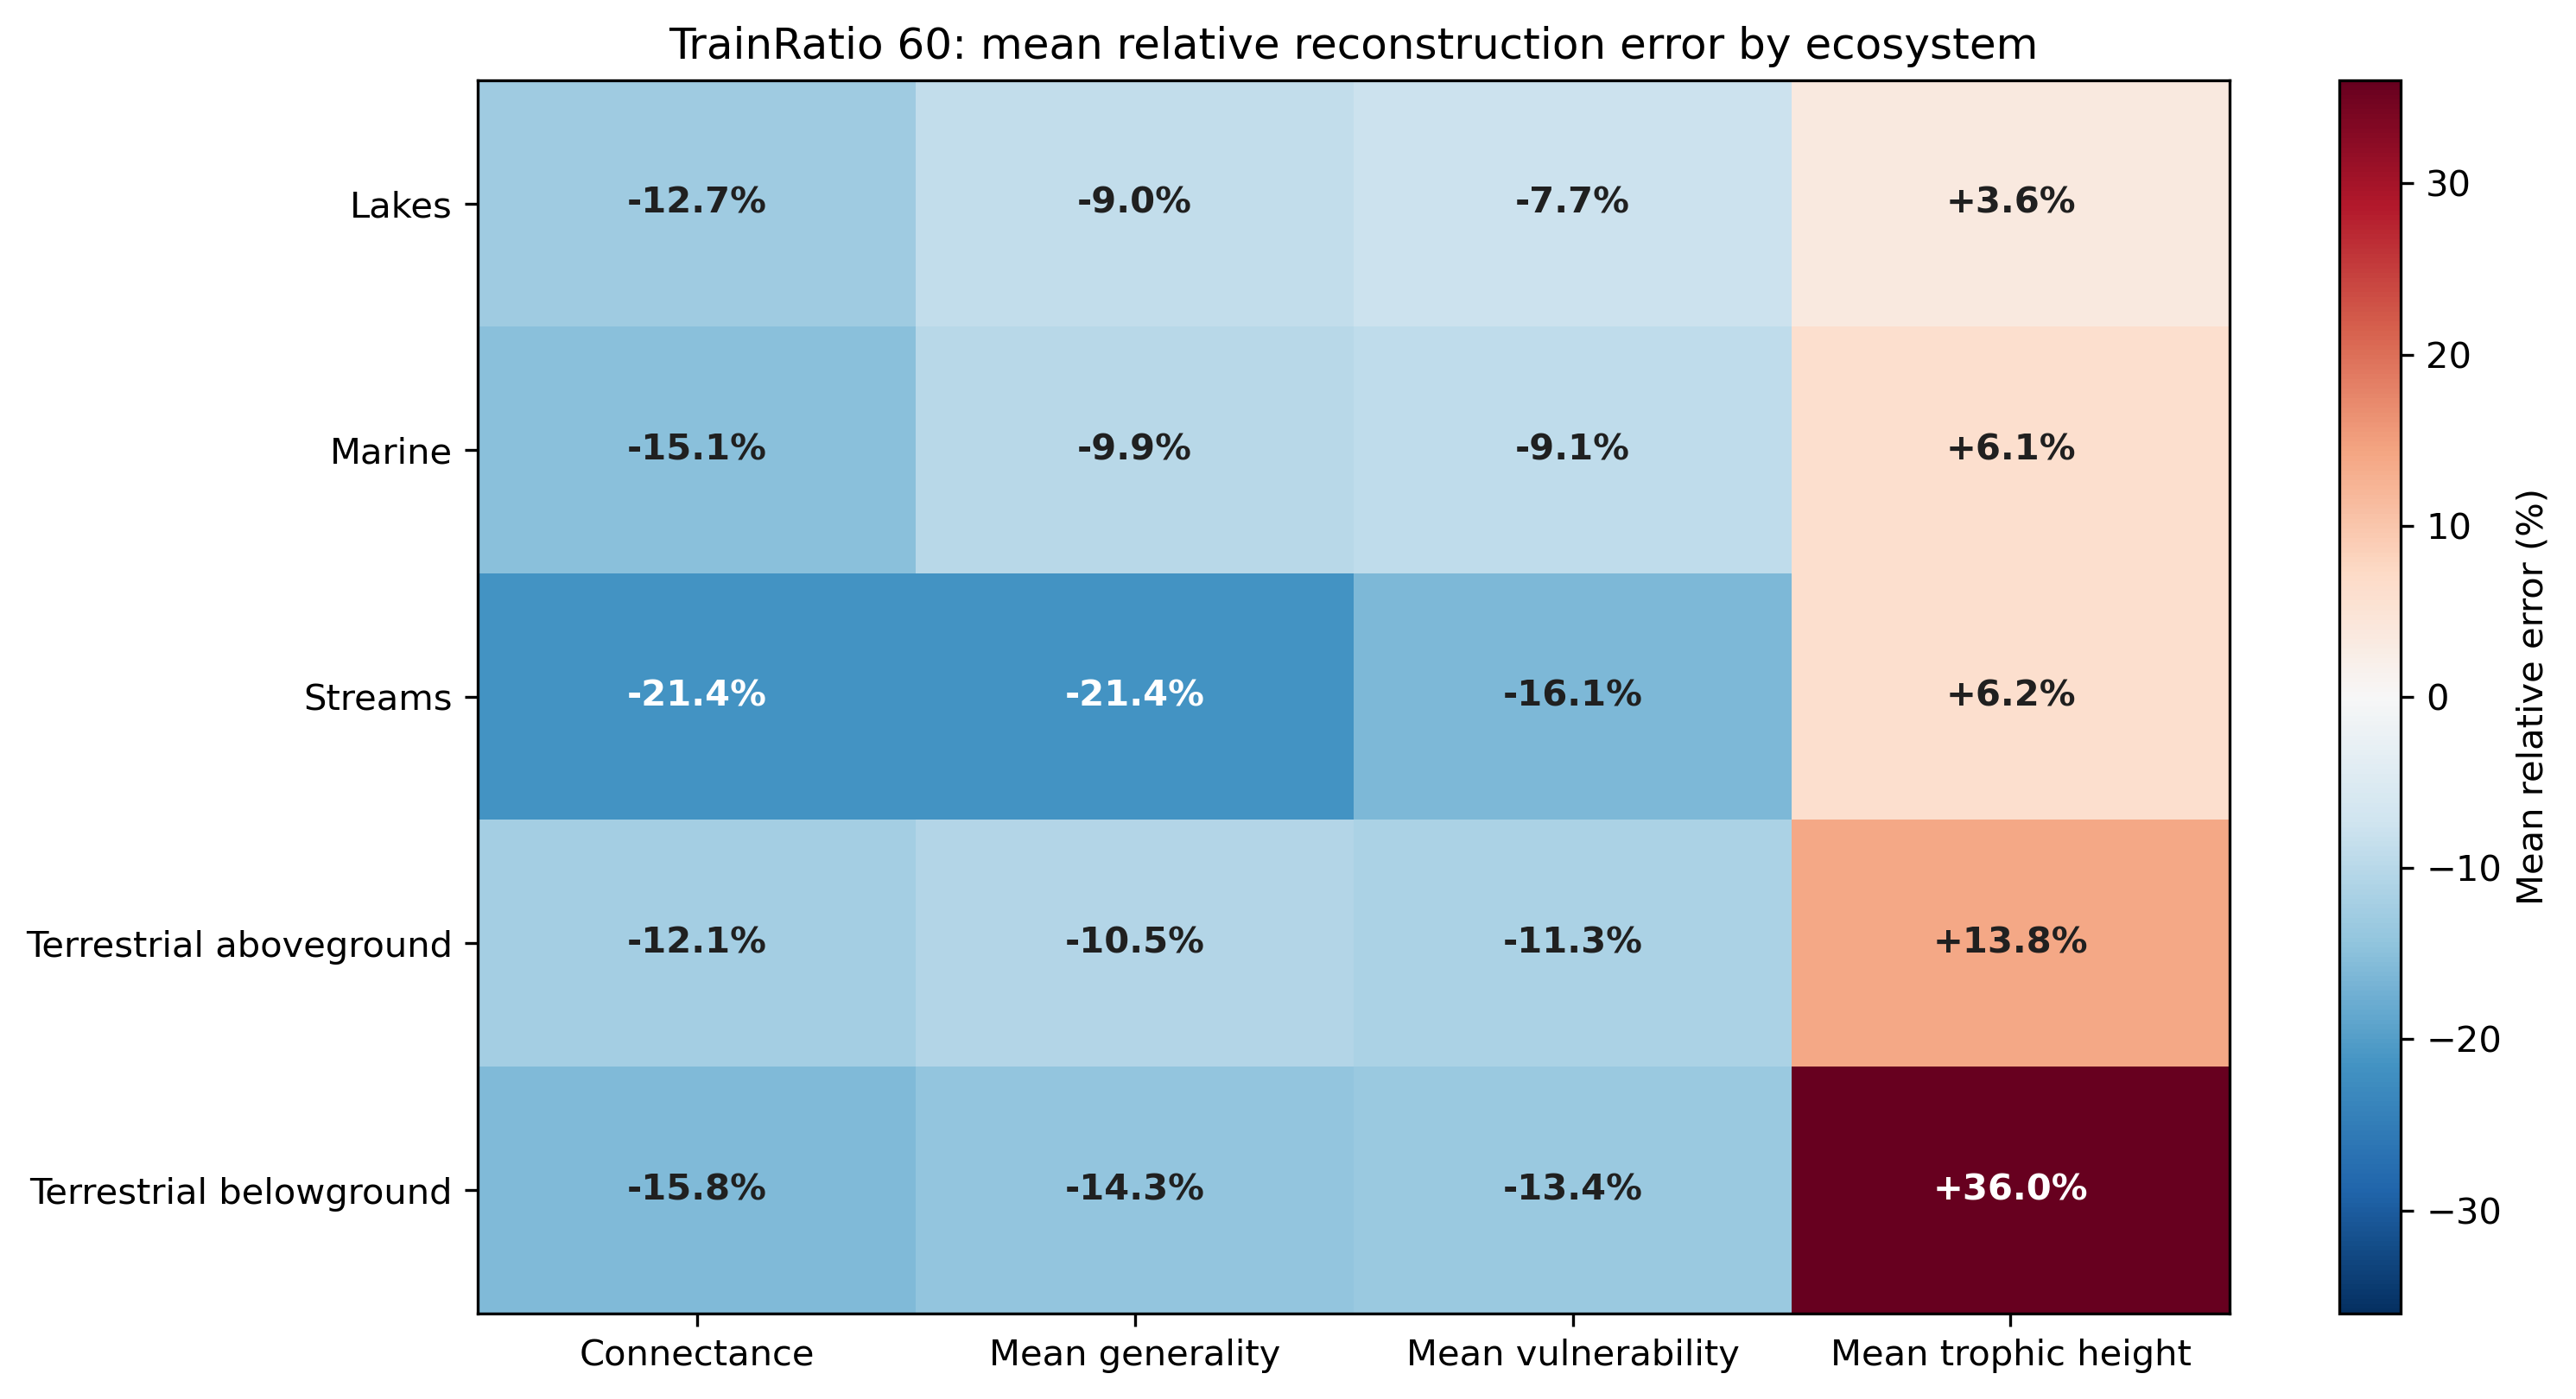

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown, Image


# Locate repository root
root = Path.cwd().resolve()
while root != root.parent and not (root / "src/matlab").exists():
    root = root.parent

DATA_DIR = (
    root
    / "src/matlab/data/"
    "result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/"
    "statistical_tests/athen/ledger_sanity"
)
FIGURE_DIR = DATA_DIR / "figures"

benchmarks = pd.read_csv(DATA_DIR / "ledger_benchmarks.csv")
overall = pd.read_csv(DATA_DIR / "ledger_sanity_train60_overall.csv")
ecosystems = pd.read_csv(DATA_DIR / "ledger_sanity_train60_by_ecosystem.csv")
excel_table = pd.read_csv(DATA_DIR / "ledger_excel_table_train60.csv")


def conclusion_colour(value):
    return (
        "background-color: #d7f5dd; color: #174c2b"
        if bool(value)
        else "background-color: #f8d7da; color: #721c24"
    )


# Ledger benchmarks
display(Markdown("## Mill Stream benchmarks"))

benchmark_view = benchmarks[
    ["MetricLabel", "Mean", "SEM", "RelativeSEMPercent", "Definition"]
].rename(columns={
    "MetricLabel": "Metric",
    "RelativeSEMPercent": "Relative SEM (%)",
})

display(
    benchmark_view.style.format({
        "Mean": "{:.4f}",
        "SEM": "{:.4f}",
        "Relative SEM (%)": "{:.2f}%",
    })
)


# Overall TrainRatio 60 results
display(Markdown("## TrainRatio 60: overall results"))

overall_view = overall[[
    "MetricLabel",
    "NumFoodWebs",
    "MeanEmpirical",
    "MeanPseudo",
    "MeanDelta",
    "RelativeError90CI",
    "LedgerRelativeSEMPercent",
    "CI90WithinLedgerRelativeSEM",
]].rename(columns={
    "MetricLabel": "Metric",
    "NumFoodWebs": "N webs",
    "MeanEmpirical": "Empirical mean",
    "MeanPseudo": "Mean pseudo",
    "MeanDelta": "Mean delta",
    "RelativeError90CI": "Mean relative error (90% CI)",
    "LedgerRelativeSEMPercent": "Ledger relative SEM (%)",
    "CI90WithinLedgerRelativeSEM": "Corresponds?",
})

overall_view["Corresponds?"] = overall_view["Corresponds?"].astype(bool)

display(
    overall_view.style
    .format({
        "Empirical mean": "{:.4f}",
        "Mean pseudo": "{:.4f}",
        "Mean delta": "{:+.4f}",
        "Ledger relative SEM (%)": "{:.2f}%",
    })
    .map(conclusion_colour, subset=["Corresponds?"])
)


# Results by ecosystem
ecosystem_labels = {
    "lakes": "Lakes",
    "marine": "Marine",
    "streams": "Streams",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}

for ecosystem, label in ecosystem_labels.items():
    display(Markdown(f"## {label}"))

    subset = ecosystems[
        ecosystems["EcosystemType"].eq(ecosystem)
    ][[
        "MetricLabel",
        "NumFoodWebs",
        "MeanEmpirical",
        "MeanPseudo",
        "MeanDelta",
        "RelativeError90CI",
        "LedgerRelativeSEMPercent",
        "CI90WithinLedgerRelativeSEM",
    ]].rename(columns={
        "MetricLabel": "Metric",
        "NumFoodWebs": "N webs",
        "MeanEmpirical": "Empirical mean",
        "MeanPseudo": "Mean pseudo",
        "MeanDelta": "Mean delta",
        "RelativeError90CI": "Mean relative error (90% CI)",
        "LedgerRelativeSEMPercent": "Ledger relative SEM (%)",
        "CI90WithinLedgerRelativeSEM": "Corresponds?",
    })

    subset["Corresponds?"] = subset["Corresponds?"].astype(bool)

    display(
        subset.style
        .format({
            "Empirical mean": "{:.4f}",
            "Mean pseudo": "{:.4f}",
            "Mean delta": "{:+.4f}",
            "Ledger relative SEM (%)": "{:.2f}%",
        })
        .map(conclusion_colour, subset=["Corresponds?"])
    )


# Generated figures
figure_files = [
    "ledger_train60_overall_relative_error.png",
    "ledger_train60_ecosystem_relative_error.png",
    "ledger_train60_ecosystem_error_heatmap.png",
]

display(Markdown("## Figures"))

for filename in figure_files:
    path = FIGURE_DIR / filename
    display(Markdown(f"### {path.stem.replace('_', ' ').title()}"))
    display(Image(filename=str(path), width=1100))

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Applied TrainRatio filter: TrainRatio == 90
[INFO] Rows after filtering, without averaging runs: 11460
Version
dir_neg     5800
original    5660
dtype: int64

=== Metric summary: mean and variance across food webs ===


,Version,Metric,Mean,Variance
0,Original,ROC-AUC,0.8469,0.053336
1,Original,PR-AUC,0.5888,0.059152
2,Original,F1,0.6667,0.099205
3,Original,MCC,0.5385,0.132832
4,Original,Precision,0.7050,0.108205
5,Original,Recall,0.6667,0.110103
6,Original,TSS,0.5000,0.124101
7,Directed-Negative,ROC-AUC,0.8889,0.015691
8,Directed-Negative,PR-AUC,0.6328,0.059231
9,Directed-Negative,F1,0.7330,0.057746


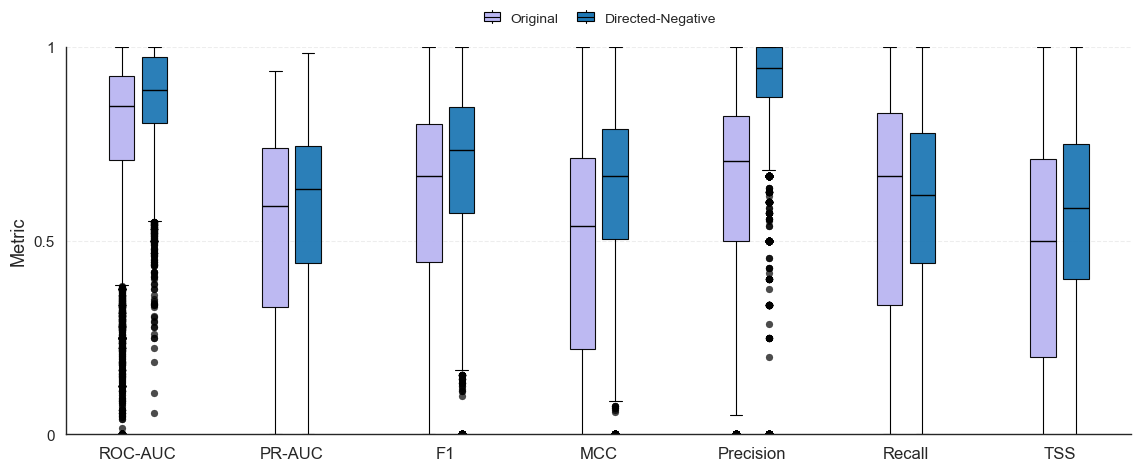

In [2]:
import os
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]
K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])

    # Filter only TrainRatio = 90
    if TRAIN_RATIO_TARGET is not None:
        if TRAIN_RATIO_COL not in df.columns:
            print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
            return None

        df = df[df[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

        if df.empty:
            return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    records = []
    df = df.reset_index(drop=True)

    for run_idx, row in df.iterrows():
        out = {
            "Foodweb": parse_foodweb_from_name(csv_path.name),
            "Version": version,
            "Run": run_idx + 1,
            "n_rows": int(len(df)),
            "file": csv_path.name,
            "folder": str(csv_path.parent),
        }

        valid_any = False

        for metric in METRICS:
            if metric in df.columns:
                val = row[metric]
                out[f"{metric}_mean"] = float(val) if pd.notna(val) else np.nan

                if pd.notna(val):
                    valid_any = True
            else:
                out[f"{metric}_mean"] = np.nan

        if valid_any:
            records.append(out)

    if not records:
        return None

    return records

def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        recs = load_one_csv(p, version=version)
        if recs is not None:
            rows.extend(recs)

    return rows

# =========================
# Load all CSVs
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check patterns or CSV columns.")


# =========================
# Apply NODE_THRESHOLD logic
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", nodes_col]].copy()
allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")
print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# =========================
# Keep one row per Foodweb × Version × Run
# This preserves the 20 repeated runs per food web.
# Expected observations per version: 290 × 20 = 5800
# =========================
print(f"[INFO] Rows after filtering, without averaging runs: {len(df_all)}")
print(df_all.groupby("Version").size())

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        # Slight downward shift for visual alignment with text
        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        # Smaller box so whiskers sit clearly outside
        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        # Whisker ends must stay outside the box
        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# =========================
# Plot: single-panel boxplots comparing versions across metrics
# =========================
order = ["original", "dir_neg"]
label_map = {
    "original": "Original",
    "dir_neg": "Directed-Negative",
}

palette = {
    "original": "#bab6f2",
    "directed": "#6edeed",
    "dir_neg": "#1f78b4",
}

plot_metrics = [
    ("ROC_AUC_mean", "ROC-AUC"),
    ("PR_AUC_mean", "PR-AUC"),
    ("F1Score_mean", "F1"),
    ("TestMCC_mean", "MCC"),
    ("Precision_mean", "Precision"),
    ("Recall_mean", "Recall"),
    ("TestTSS_mean", "TSS"),
]

# =========================
# Print metric summary table
# =========================
summary_rows = []

for version in order:
    for metric_col, metric_label in plot_metrics:
        vals = (
            df_all.loc[df_all["Version"] == version, metric_col]
            .dropna()
        )

        summary_rows.append({
            "Version": label_map.get(version, version),
            "Metric": metric_label,
            "Mean": vals.median(),
            "Variance": vals.var(ddof=1),
        })

summary_table = pd.DataFrame(summary_rows)

summary_table["Mean"] = summary_table["Mean"].round(4)
summary_table["Variance"] = summary_table["Variance"].round(6)

print("\n=== Metric summary: mean and variance across food webs ===")
display(summary_table)

# ---

fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

# Small offsets so versions within the same metric stay close together
offsets = np.array([-0.16, 0.16])
box_width = 0.25

legend_handles = []

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            df_all.loc[df_all["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    bp = ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.7,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels([label for _, label in plot_metrics], rotation=0, ha="center", fontsize=12)

ax.set_ylabel("Metric", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(order),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_37938/3591239872.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FOODWEB"] = derive_foodweb_from_filename(path)
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_37938/3591239872.py:154: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)


[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 290


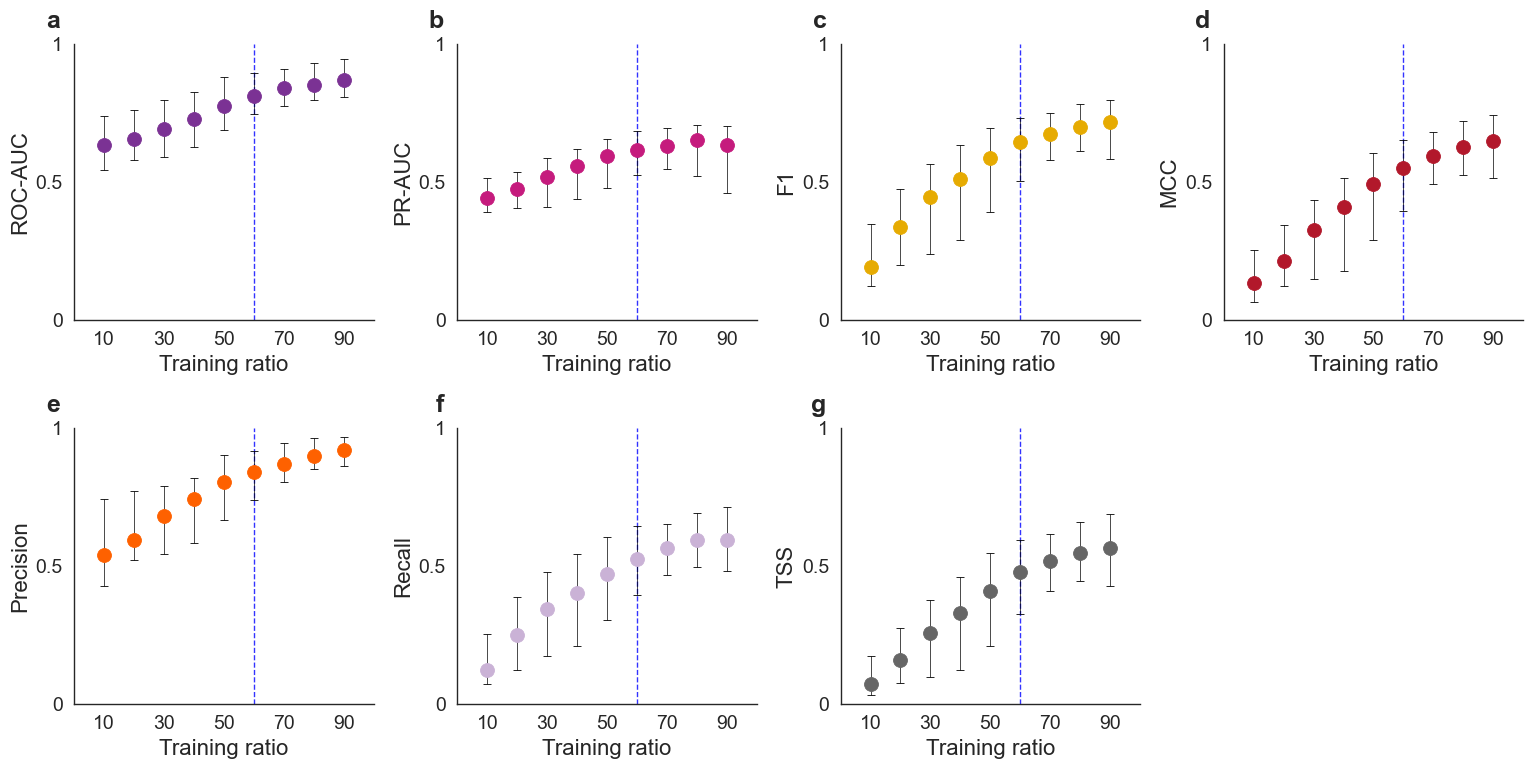

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.35)
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

# Display labels only
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = False
Y_MIN = 0.0

# Static y-axis for all panels
INDEPENDENT_Y = False
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # brown
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_tax_mass_results_random_wlnm_dir_neg", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    # Keep all plotted train-ratio values, but only label the main x-axis ticks.
    visible_ticks = [10, 30, 50, 70, 90]
    ax.set_xticks(visible_ticks)
    ax.set_xticklabels([str(t) for t in visible_ticks])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
# No ecosystem split: each food web contributes one mean value per train ratio and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Foodwebs used in final plot: {n_webs}")

# Consistent metric colors
metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}

# =========================
# Final plot: 2 rows for metric panels
# =========================
n_metrics = len(metrics_present)
n_rows = 2
n_cols = int(np.ceil(n_metrics / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 8.0),
    sharex=False,
    sharey=False
)

# Make axes always 2D, then flatten for easy indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

axes_flat = axes.flatten()

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(metrics_present):
    ax = axes_flat[i]

    sub = summary[
        summary["Metric"] == metric
    ].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    # Vertical reference line at train ratio = 60
    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    # Independent y zoom per panel
    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    # No panel title; use the metric name as the y-axis title for each panel
    ax.set_title("")

    # Add x-axis label to all panels
    ax.set_xlabel("Training ratio", fontsize=16)

    # y-axis title for each panel
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=16)

    # Panel letters
    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

# Hide any unused subplot(s)
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

[INFO] Loaded paired input: 23,145 web x run x metric rows
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/train_ratio_60/run_level_boxplots_train60.png


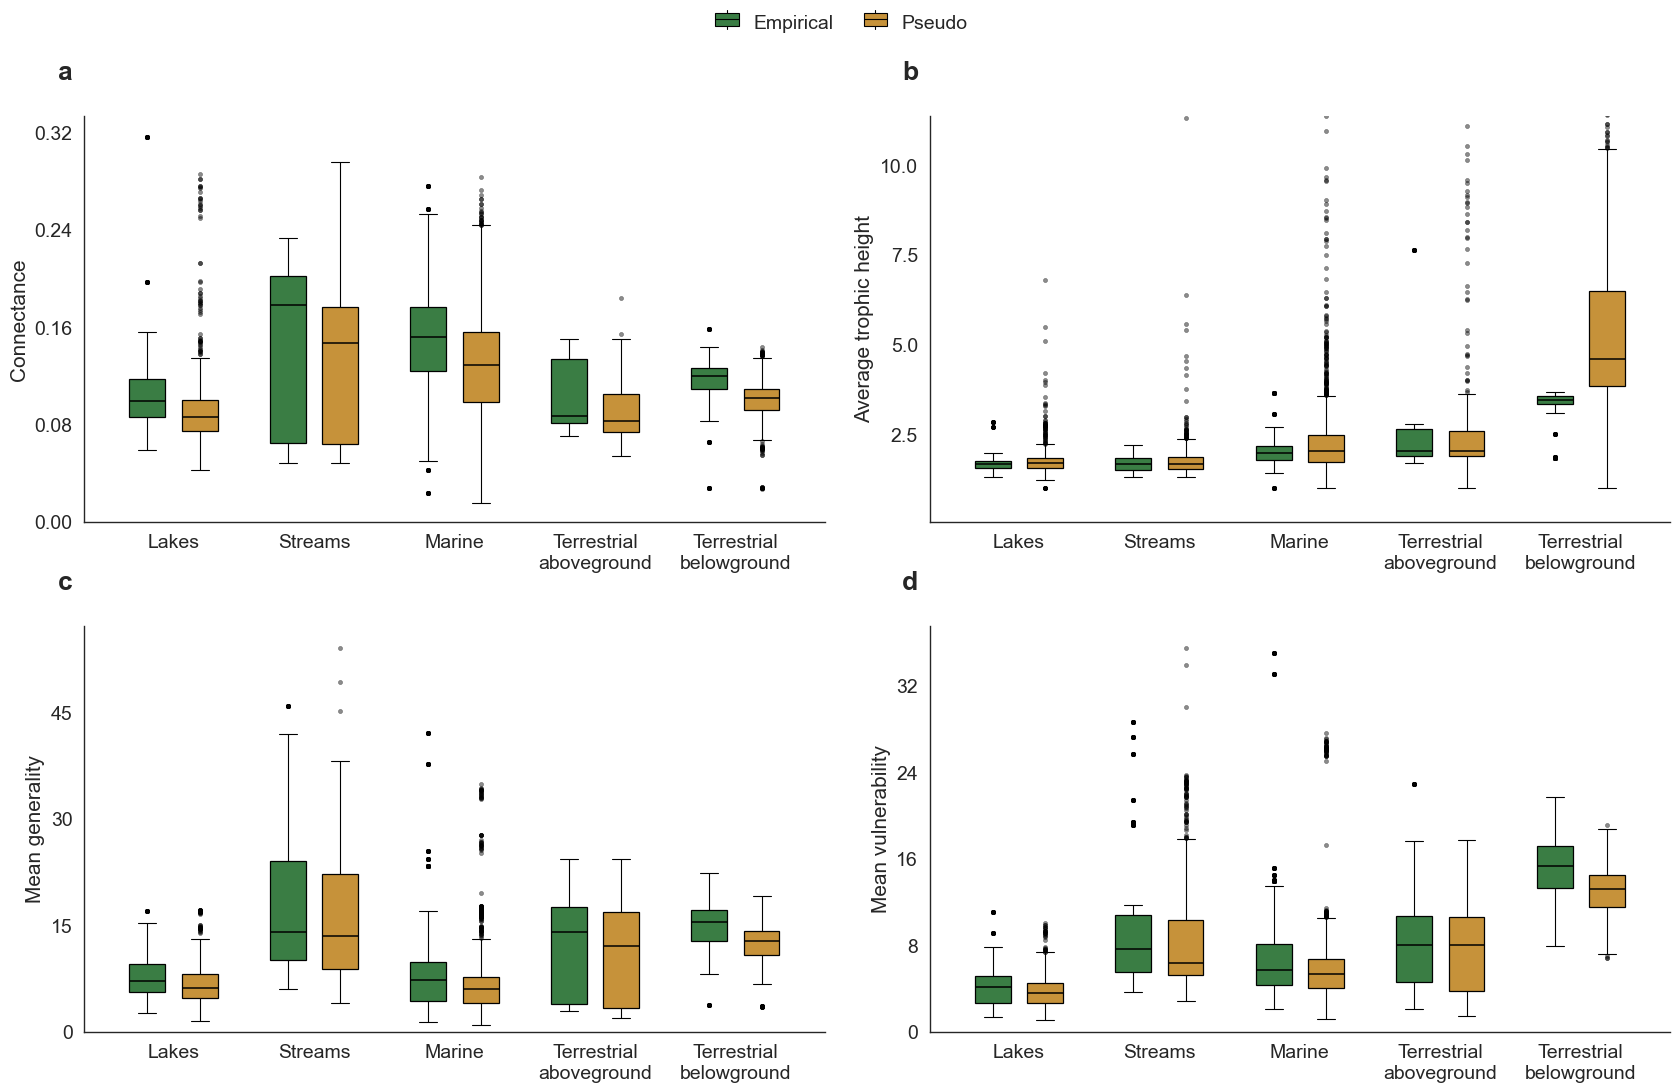

In [5]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

TRAIN_RATIO = 60

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
    / f"train_ratio_{TRAIN_RATIO}"
)

PAIRED_INPUT = EOIN_DIR / f"eoin_paired_input_train{TRAIN_RATIO}.csv"

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

# Metrics where fliers should be hidden to improve readability.
# This affects only the visual display, not the boxplot statistics.
HIDE_FLIERS_METRICS = {}

# Metrics where the y-axis should focus on the Tukey non-outlier range.
ZOOM_TO_BOXPLOT_RANGE_METRICS = {
    "average_trophic_height",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())


def draw_box(ax, values, position, facecolor, showfliers=True):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_zoom_ylim_with_some_outliers(
    grouped_values,
    lower_bound=0.0,
    pad_fraction=0.10,
    upper_percentile=97.5,
):
    """
    Compute y-limits that:
    - always show the full boxes and whiskers
    - keep some moderate outliers visible
    - hide only the most extreme outliers

    grouped_values: list of 1D arrays, one per displayed boxplot.
    """
    visible_lows = []
    visible_highs = []
    all_values = []

    for values in grouped_values:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        all_values.extend(values.tolist())

        q1, q3 = np.nanpercentile(values, [25, 75])
        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr

            non_fliers = values[
                (values >= lower_fence) &
                (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(non_fliers)
            upper_whisker = np.nanmax(non_fliers)

        visible_lows.extend([q1, lower_whisker])
        visible_highs.extend([q3, upper_whisker])

    if not visible_lows or not visible_highs:
        return None

    all_values = np.asarray(all_values, dtype=float)
    all_values = all_values[np.isfinite(all_values)]

    whisker_min = np.nanmin(visible_lows)
    whisker_max = np.nanmax(visible_highs)

    # High percentile to keep moderate outliers visible but suppress extremes
    percentile_cap = np.nanpercentile(all_values, upper_percentile)

    local_min = whisker_min
    local_max = max(whisker_max, percentile_cap)

    data_range = local_max - local_min if local_max > local_min else 0.05

    local_min = max(lower_bound, local_min - pad_fraction * data_range)
    local_max = local_max + pad_fraction * data_range

    if np.isclose(local_min, local_max):
        local_min = max(lower_bound, local_min - 0.02)
        local_max = local_max + 0.02

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# LOAD CORRECTED RUN-LEVEL DATA
# ============================================================
paired_input = pd.read_csv(PAIRED_INPUT)

paired_input["metric"] = paired_input["metric"].astype(str)
paired_input["ecosystem"] = paired_input["ecosystem"].astype(str)

for col in ["real", "pseudo"]:
    paired_input[col] = pd.to_numeric(paired_input[col], errors="coerce")

print(f"[INFO] Loaded paired input: {len(paired_input):,} web x run x metric rows")

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = paired_input[paired_input["metric"] == metric].copy()
    panel_df = panel_df.dropna(subset=["real", "pseudo", "ecosystem"])

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING

    all_values = []
    boxplot_groups = []
    show_fliers = metric not in HIDE_FLIERS_METRICS

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        real_values = pd.to_numeric(eco_df["real"], errors="coerce").dropna().values
        pseudo_values = pd.to_numeric(eco_df["pseudo"], errors="coerce").dropna().values

        if len(real_values):
            draw_box(
                ax=ax,
                values=real_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
                showfliers=show_fliers,
            )
            all_values.extend(real_values)
            boxplot_groups.append(real_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Pseudo"],
                showfliers=show_fliers,
            )
            all_values.extend(pseudo_values)
            boxplot_groups.append(pseudo_values)

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    panel_vals = np.asarray(all_values, dtype=float)
    panel_vals = panel_vals[np.isfinite(panel_vals)]

    if panel_vals.size:
        if metric in ZOOM_TO_BOXPLOT_RANGE_METRICS:
            ylim = get_boxplot_zoom_ylim_with_some_outliers(
                boxplot_groups,
                lower_bound=0.0,
                pad_fraction=0.10,
                upper_percentile=97.5,
            )
            if ylim is not None:
                ax.set_ylim(*ylim)
        else:
            local_min = np.nanmin(panel_vals)
            local_max = np.nanmax(panel_vals)
            data_range = local_max - local_min if local_max > local_min else 0.05

            local_min = max(0.0, local_min - 0.06 * data_range)
            local_max = local_max + 0.06 * data_range

            if np.isclose(local_min, local_max):
                local_min = max(0.0, local_min - 0.02)
                local_max = local_max + 0.02

            ax.set_ylim(local_min, local_max)

        ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

# ============================================================
# GLOBAL LEGEND ABOVE ALL PANELS
# ============================================================
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={dict: HandlerMiniBoxplot()},
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=0)

OUT_PATH = EOIN_DIR / f"run_level_boxplots_train{TRAIN_RATIO}.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

Using LOG_DIR: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs
Found 870 CSV files matching pattern: *tax_mass_results_random_wlnm_dir_neg_kfold*.csv

df_means shape:
(104400, 11)

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64


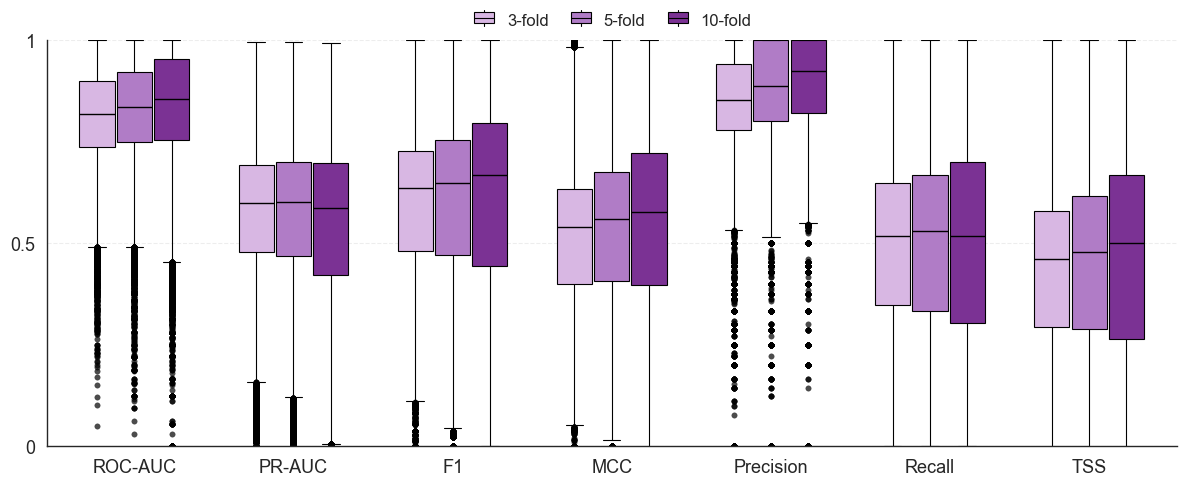

In [14]:
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# -----------------------------
# Config
# -----------------------------
LOG_DIR_REL = Path(
    "src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
)

# Important: files are named ..._kfold_cvK3.csv, ..._kfold_cvK5.csv, ..._kfold_cvK10.csv
PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold*.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]

METRIC_SOURCES = {
    "ROC_AUC": ["ROC_AUC"],
    "PR_AUC": ["PR_AUC"],
    "F1Score": ["F1Score", "TestF1Score", "PseudoF1Score"],
    "TestMCC": ["TestMCC", "PseudoMCC"],
    "Precision": ["Precision", "TestPrecision", "PseudoPrecision"],
    "Recall": ["Recall", "TestRecall", "PseudoRecall"],
    "TestTSS": ["TestTSS", "PseudoTSS"],
}

METRICS = list(METRIC_SOURCES.keys())

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]


def resolve_log_dir(rel_path: Path) -> Path:
    rel_path = Path(rel_path)

    if rel_path.is_absolute():
        return rel_path

    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / rel_path
        if candidate.is_dir():
            return candidate.resolve()

    return (Path.cwd() / rel_path).resolve()


LOG_DIR = resolve_log_dir(LOG_DIR_REL)


def cvk_label(k: int) -> str:
    return f"{k}-fold"


def foodweb_name_from_path(p: str) -> str:
    name = Path(p).name
    return re.sub(
        r"_tax_mass_results_random_wlnm_dir_neg_kfold(?:_cvK\d+)?\.csv$",
        "",
        name,
    )


def find_metric_columns(df: pd.DataFrame):
    selected = {}
    missing = []

    for metric, candidates in METRIC_SOURCES.items():
        source_col = next((col for col in candidates if col in df.columns), None)

        if source_col is None:
            missing.append(f"{metric} ({' / '.join(candidates)})")
        else:
            selected[metric] = source_col

    return selected, missing

def collect_foodweb_means(log_dir: Path, pattern: str) -> pd.DataFrame:
    expected_cols = ["CvK", "CvK_label", "Foodweb", "Run", *METRICS]

    rows = []
    csv_files = sorted(glob.glob(str(Path(log_dir) / pattern)))

    print(f"Using LOG_DIR: {log_dir}")
    print(f"Found {len(csv_files)} CSV files matching pattern: {pattern}")

    if not csv_files:
        return pd.DataFrame(columns=expected_cols)

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {Path(csv_path).name} read error: {e}")
            continue

        if "CvK" not in df.columns:
            print(f"[SKIP] {Path(csv_path).name} missing column: CvK")
            continue

        metric_sources, missing_metrics = find_metric_columns(df)
        if missing_metrics:
            print(f"[SKIP] {Path(csv_path).name} missing metrics: {missing_metrics}")
            continue

        df = df.copy()
        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce")

        if "K" in df.columns:
            df["K"] = pd.to_numeric(df["K"], errors="coerce")
            df = df[df["K"] == K_TARGET].copy()

        df = df[df["CvK"].isin(cvk_order)].copy()

        if df.empty:
            print(f"[SKIP] {Path(csv_path).name} no rows after K/CvK filtering.")
            continue

        for metric, source_col in metric_sources.items():
            df[metric] = pd.to_numeric(df[source_col], errors="coerce")

        # Keep each repeated run instead of averaging the 20 runs per food web.
        # Expected rows per CvK: 290 food webs × 20 runs = 5800 observations.
        df["CvK"] = df["CvK"].astype("Int64")
        df["Foodweb"] = foodweb_name_from_path(csv_path)
        df["Run"] = df.groupby("CvK").cumcount() + 1

        rows.append(df[["CvK", "Foodweb", "Run", *METRICS]].copy())

    if not rows:
        return pd.DataFrame(columns=expected_cols)

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out[expected_cols]

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_foodweb_means_1x4(df_means: pd.DataFrame) -> None:
    if df_means.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if (df_means["CvK"] == k).any()]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        3: "3-fold",
        5: "5-fold",
        10: "10-fold",
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.linspace(-0.34, 0.34, len(present_cvks))
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []
        metrics_for_boxes = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = df_means.loc[df_means["CvK"] == cvk, metric].dropna().values

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])
            metrics_for_boxes.append(metric)

        if not data_for_cvk:
            continue

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(edgecolor="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box in bp["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([label for _, label in plot_metrics], ha="center", fontsize=13)

    # ax.set_ylabel("Mean value", fontsize=15)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
        columnspacing=1.2,
    )

    plt.tight_layout()
    plt.show()


# -----------------------------
# Run
# -----------------------------
df_means = collect_foodweb_means(LOG_DIR, PATTERN)

print("\ndf_means shape:")
print(df_means.shape)

if df_means.empty:
    print("\nNo data collected. Check LOG_DIR, PATTERN, K_TARGET, CvK values, and skipped-file messages above.")
else:
    print("\nFoodweb count per CvK:")
    print(df_means.groupby("CvK")["Foodweb"].nunique())

    plot_foodweb_means_1x4(df_means)

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_37938/3975381087.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Foodweb"] = os.path.basename(file).split("_results_")[0]


Filtered results by TrainRatio: kept only TrainRatio = 90.
Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

=== Precision median and variance by ecosystem using all runs ===
          EcosystemType  n_foodwebs  n_runs  Precision_Median  Precision_Variance
                  lakes          55    1100            1.0000            0.059589
                 marine         134    2680            0.9412            0.044763
                streams          28     560            0.9818            0.123175
terrestrial aboveground          21     420            0.9231            0.054745
terrestrial belowground          52    1040            0.9217            0.001014

=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial belowground (median = 0.9217, variance = 0.001014, n_runs = 1040)
Highest median precision: lakes (median = 1.0, variance = 0.059589, n_runs = 1100)
Lowest variance:          terrestrial belowground (variance = 0.0010

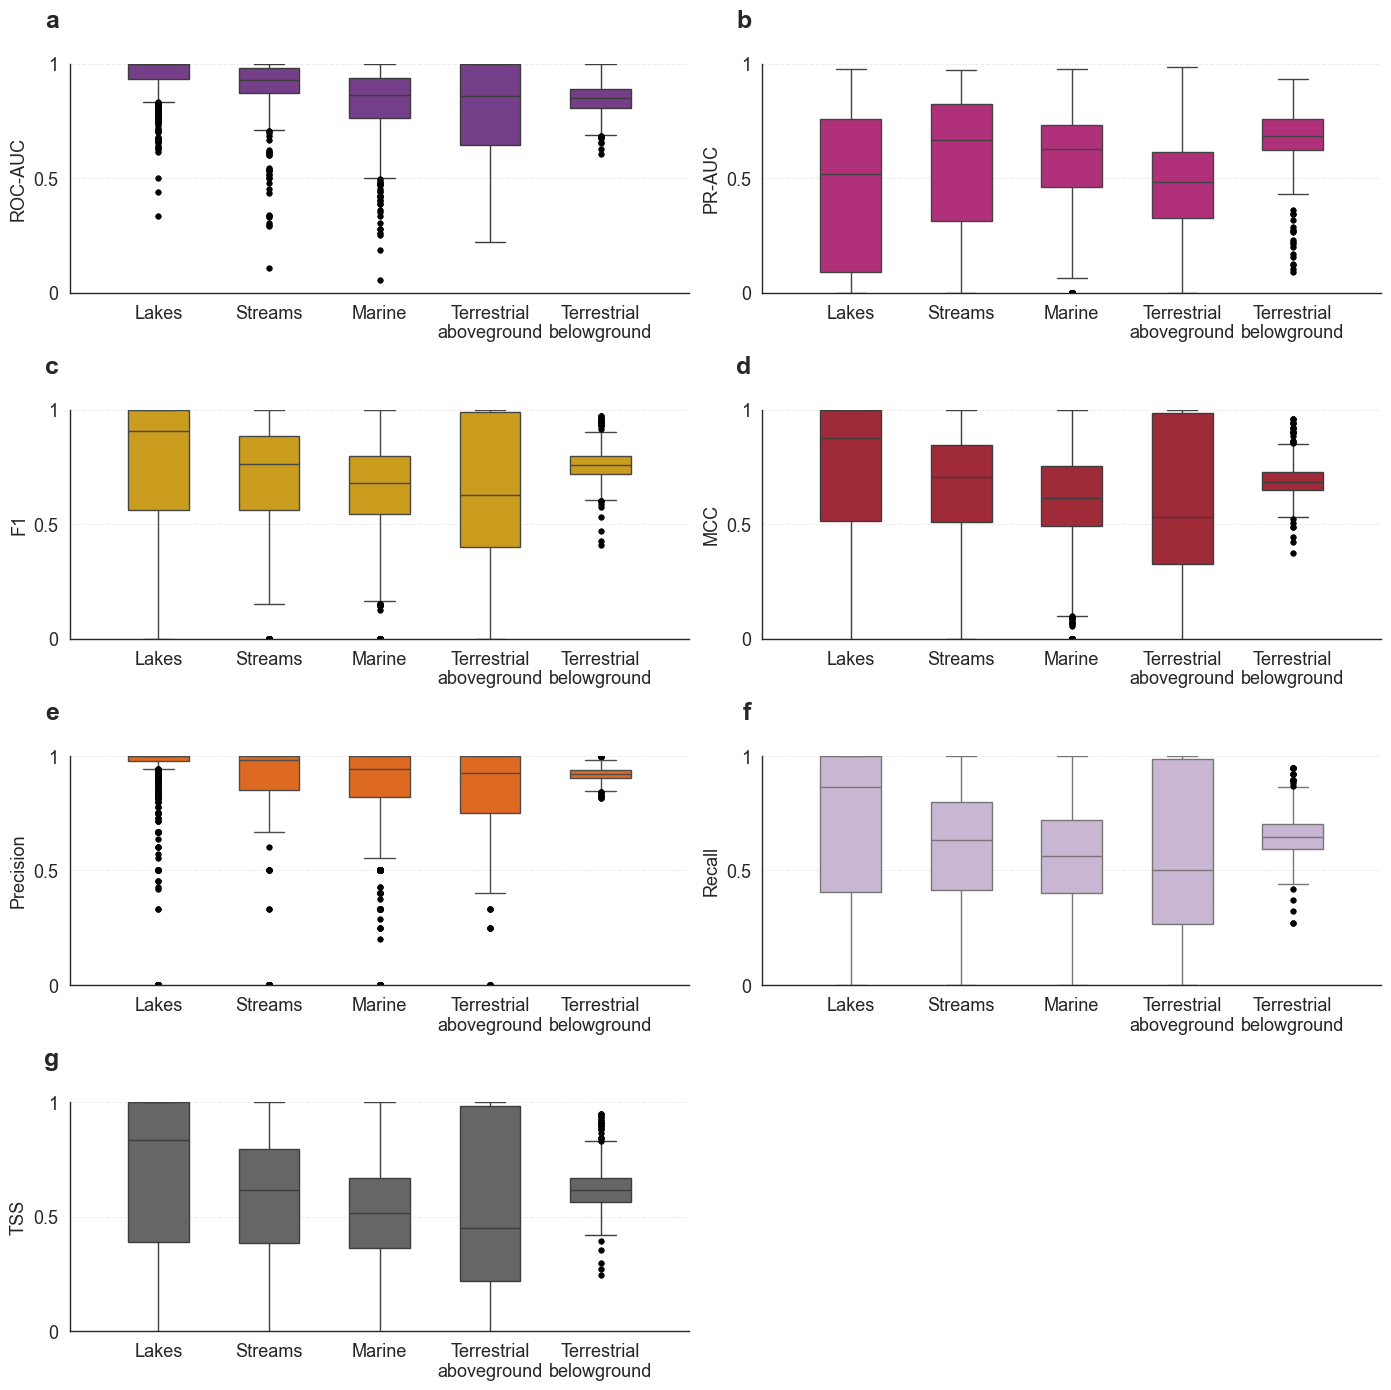

In [15]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]
xtick_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC", "Precision", "Recall", "TSS"]
MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"
Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",     # purple
    "PR_AUC": "#C51B7D",      # magenta
    "Precision": "#FE6100",   # orange
    "Recall": "#CAB2D6",      # violet
    "F1Score": "#E6AB02",     # mustard
    "TestMCC": "#B2182B",   # deep red / burgundy
    "TestTSS": "#666666",   # dark gray
    "TestTPR": "#1B9E77",   # teal-green
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
    "TestTPR": "TPR",
}

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Filter TrainRatio = 60 before merging/melting ===
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

print(f"Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# ============================================================
# Precision median by ecosystem: lowest/highest median
# Uses all repeated runs directly: 290 food webs × 20 runs
# ============================================================

if "Precision" not in df_merged.columns:
    raise RuntimeError("Column 'Precision' not found in df_merged.")

df_precision_runs = (
    df_merged
    .dropna(subset=["EcosystemType", "Precision"])
    .copy()
)

precision_summary = (
    df_precision_runs
    .groupby("EcosystemType", as_index=False)
    .agg(
        n_foodwebs=("Foodweb", "nunique"),
        n_runs=("Precision", "count"),
        Precision_Median=("Precision", "median"),
        Precision_Variance=("Precision", lambda x: x.var(ddof=1)),
    )
)

precision_summary["Precision_Median"] = precision_summary["Precision_Median"].round(4)
precision_summary["Precision_Variance"] = precision_summary["Precision_Variance"].round(6)

print("\n=== Precision median and variance by ecosystem using all runs ===")
print(precision_summary.to_string(index=False))

# Identify ecosystems with lowest/highest median precision
lowest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmin()]
highest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmax()]

# Identify ecosystems with lowest/highest precision variance
lowest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmin()]
highest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmax()]

print("\n=== Ecosystems with lowest/highest median precision and variance ===")

print(
    f"Lowest median precision:  {lowest_precision['EcosystemType']} "
    f"(median = {lowest_precision['Precision_Median']}, "
    f"variance = {lowest_precision['Precision_Variance']}, "
    f"n_runs = {lowest_precision['n_runs']})"
)

print(
    f"Highest median precision: {highest_precision['EcosystemType']} "
    f"(median = {highest_precision['Precision_Median']}, "
    f"variance = {highest_precision['Precision_Variance']}, "
    f"n_runs = {highest_precision['n_runs']})"
)

print(
    f"Lowest variance:          {lowest_variance['EcosystemType']} "
    f"(variance = {lowest_variance['Precision_Variance']}, "
    f"median = {lowest_variance['Precision_Median']}, "
    f"n_runs = {lowest_variance['n_runs']})"
)

print(
    f"Highest variance:         {highest_variance['EcosystemType']} "
    f"(variance = {highest_variance['Precision_Variance']}, "
    f"median = {highest_variance['Precision_Median']}, "
    f"n_runs = {highest_variance['n_runs']})"
)

print("\n=== Run-level observations after filtering ===")
print(f"Total rows in df_merged: {len(df_merged)}")
print("Rows per ecosystem:")
print(df_merged.groupby("EcosystemType").size())

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)
def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    label = label_replacements.get(eco_lower, eco_clean.capitalize())
    return f"{label}"

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

# === Data already filtered to TrainRatio = 60 ===
subset = df_plot.copy()

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

# === Plot: metric panels, with ecosystems placed next to each other ===
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 14),
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        legend=False,
        width=0.55,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)
    ax.set_ylim(0, 1.0)
    ax.grid(False, axis="x")
    
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)
plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[FINAL] Food webs retained after structural filters: 290

=== OLS linear regression: metric ~ empirical connectance ===
a) ROC-AUC: y = -0.3518x + 0.9138; F1,288 = 8.6305; R² = 0.0291; P = 0.0036; n = 290
b) PR-AUC: y = 1.5263x + 0.3666; F1,288 = 43.4428; R² = 0.1311; P < 0.0001; n = 290
c) F1: y = -0.9380x + 0.8163; F1,288 = 15.2961; R² = 0.0504; P = 0.0001; n = 290
d) MCC: y = -1.1923x + 0.7978; F1,288 = 23.0482; R² = 0.0741; P < 0.0001; n = 290
e) Precision: y = -0.5025x + 0.9415; F1,288 = 6.3947; R² = 0.0217; P = 0.0120; n = 290
f) Recall: y = -1.1585x + 0.7591; F1,288 = 19.4172; R² = 0.0632; P < 0.0001; n = 290
g) TSS: y = -1.3562x + 0.7536; F1,288 = 24.8649; R² = 0.0795; 

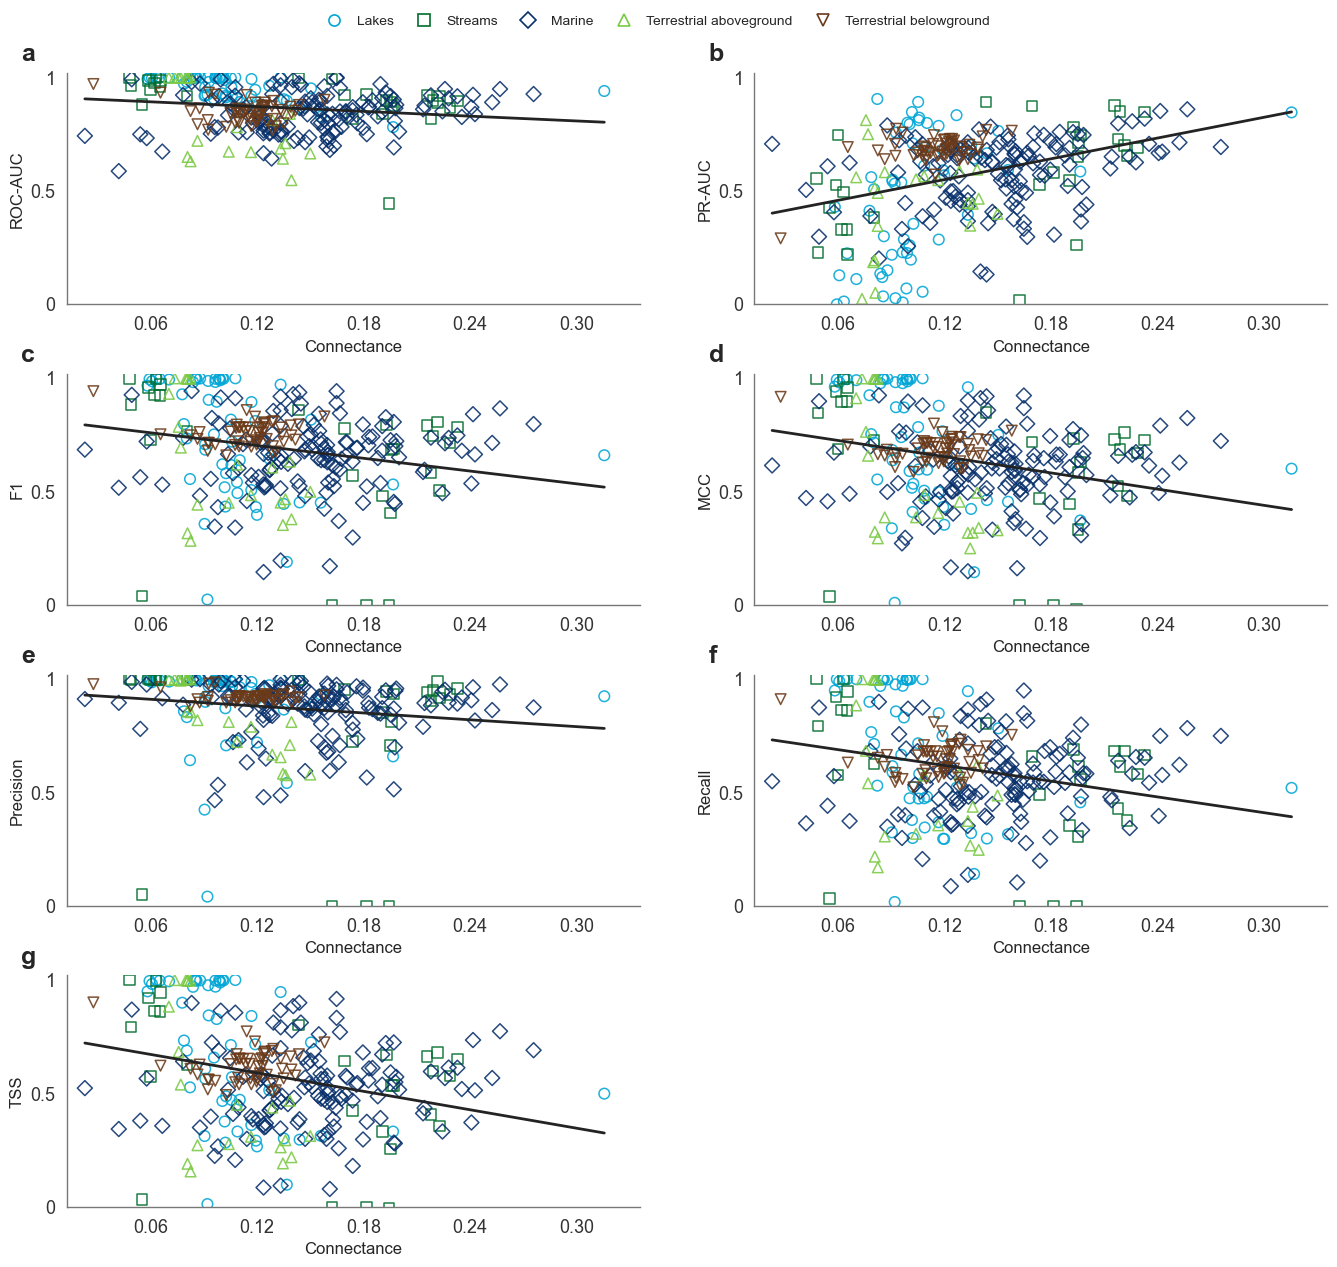

In [16]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    # Removed deprecated copy=False argument to avoid Pandas4Warning.
    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(
        meta["MetadataConnectance"],
        errors="coerce",
    )

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "TestTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )

    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (
            df.loc[can_compute_conn, "Nodes"]
            * (df.loc[can_compute_conn, "Nodes"] - 1)
        )
    )

    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO}", before, after)
    before = after

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"]).copy()
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_count("available connectance for x-axis", df_before_x, df_after_x)

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after structural filters: {df['Foodweb'].nunique()}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_linear_regression(data: pd.DataFrame, metric: str, n_points: int = 100):
    """
    Fits an OLS linear regression:

        metric ~ EmpiricalConnectanceForPlot

    Returns fitted line coordinates, equation coefficients, R², P-value,
    F-statistic, degrees of freedom, and n.
    """
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return None

    work["EmpiricalConnectanceForPlot"] = work["EmpiricalConnectanceForPlot"].astype(float)
    work[metric] = work[metric].astype(float)

    if len(work) < 3 or work["EmpiricalConnectanceForPlot"].nunique() < 2:
        return None

    x = work[["EmpiricalConnectanceForPlot"]]
    y = work[metric]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["EmpiricalConnectanceForPlot"]

    x_line = np.linspace(
        work["EmpiricalConnectanceForPlot"].min(),
        work["EmpiricalConnectanceForPlot"].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {"EmpiricalConnectanceForPlot": x_line}
    )
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["EmpiricalConnectanceForPlot"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def format_equation(slope: float, intercept: float) -> str:
    sign = "+" if intercept >= 0 else "-"
    return f"y = {slope:.4f}x {sign} {abs(intercept):.4f}"


def format_p_value(p_value: float) -> str:
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Connectance", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(axis="both", colors="#333333", labelsize=13)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    available_ecosystems = (
        plot_df["EcosystemType"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    available_by_label = {
        format_ecosystem_label(eco): eco
        for eco in available_ecosystems
    }

    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    eco_order += [
        eco
        for eco in available_ecosystems
        if eco not in eco_order
    ]

    plot_df = plot_df.copy()
    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
        for eco in eco_order
    }

    eco_markers = {
        eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
        for eco in eco_order
    }

    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        # figsize=(12.5, 4.6 * n_rows),
        figsize=(14, 14),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    total_foodwebs = plot_df["Foodweb"].nunique()

    x_min = plot_df["EmpiricalConnectanceForPlot"].min()
    x_max = plot_df["EmpiricalConnectanceForPlot"].max()

    print("\n=== OLS linear regression: metric ~ empirical connectance ===")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric]).copy()
        n_metric_foodwebs = data["Foodweb"].nunique()

        for eco in eco_order:
            sub = data[data["EcosystemType"] == eco]

            if sub.empty:
                continue

            ax.scatter(
                sub["EmpiricalConnectanceForPlot"],
                sub[metric],
                marker=eco_markers[eco],
                facecolors="none",
                edgecolors=eco_palette[eco],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(eco),
            )

        fit = fit_linear_regression(data, metric)

        if fit is not None:
            ax.plot(
                fit["x_line"],
                fit["y_line"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(fit["slope"], fit["intercept"])
            p_text = format_p_value(fit["p_value"])

            print(
                f"{panel_letters[i]}) {label}: "
                f"{equation}; "
                f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
                f"R² = {fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[i]}) {label}: "
                "regression not fitted; insufficient data."
            )

        style_axes(ax, label)

        # ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)

        ax.set_xlim(
            max(0.0, x_min - 0.01),
            x_max + 0.02,
        )

        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(["0", "0.5", "1"])

        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[eco],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[eco],
            markeredgewidth=1.2,
            label=format_ecosystem_label(eco),
        )
        for eco in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=min(len(eco_order), 5),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

1 new version of plot for "Reconstruction bias across train ratios\n" "Shaded: +/-15%; dashed: +/-10%; dotted: +/-20%",
with the same 4 metrics: connectance, mean generality, mean vulnerability, mean trophic height in each panel
relative error % on Y-axis
train ratio = 60
number of nodes on X-axis
number of links on X-axis

[INFO] Loaded ecosystem metadata: 290 food webs
[INFO] Using per-foodweb bias file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/statistical_tests/athen/athen_web_level_metrics_all_ratios.csv
[INFO] Plot data: 290 food webs, 1,160 metric rows


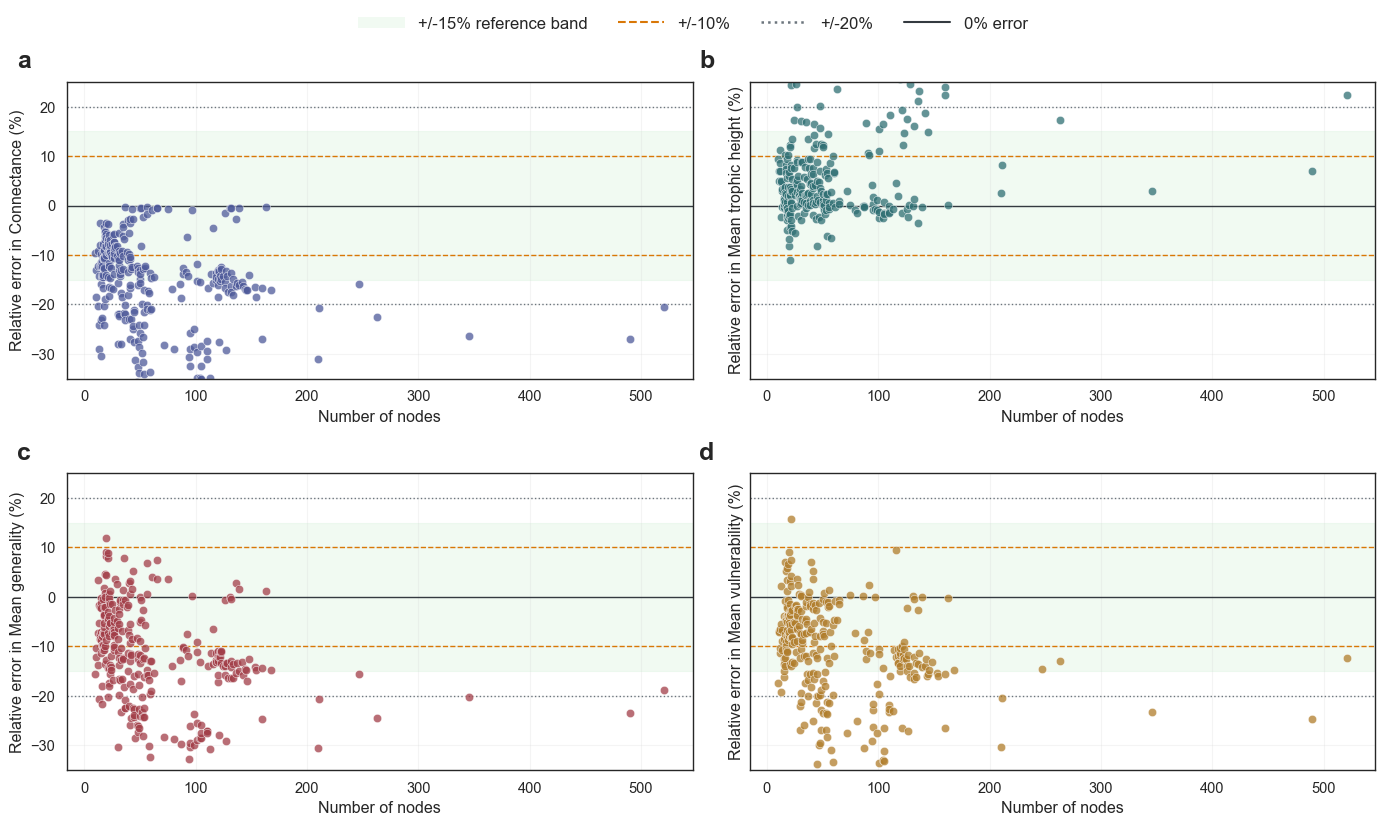

In [37]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ---------------------------------------------------------------------
# Paths and data
# ---------------------------------------------------------------------
def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src" / "matlab").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


def find_column(df, candidates, required=True):
    normalized = {
        re.sub(r"[^a-z0-9]", "", col.lower()): col
        for col in df.columns
    }

    for candidate in candidates:
        key = re.sub(r"[^a-z0-9]", "", candidate.lower())
        if key in normalized:
            return normalized[key]

    if required:
        raise KeyError(
            f"None of the candidate columns were found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )

    return None


def normalize_foodweb_name(value):
    value = str(value).strip()
    value = Path(value).stem

    suffixes = [
        "_tax_mass",
        "_tax",
        "_mass",
        ".mat",
    ]

    for suffix in suffixes:
        if value.lower().endswith(suffix):
            value = value[: -len(suffix)]

    return re.sub(r"[^a-z0-9]", "", value.lower())


ROOT = find_repo_root()
DATA_DIR = ROOT / "src/matlab/data"

ATHEN_DIR = (
    ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)

ECOSYSTEM_FILE = (
    DATA_DIR
    / "foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

FIGURE_DIR = ATHEN_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = True
TRAIN_RATIO_TARGET = 60

METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

METRIC_COLORS = {
    "Connectance": "#4E5A9A",
    "MeanGenerality": "#A23E48",
    "MeanVulnerability": "#B07D2B",
    "MeanTrophicHeight": "#2F6F73",
}


def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(
            FIGURE_DIR / filename,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
    plt.show()


# ============================================================
# Load ecosystem metadata with number of nodes
# ============================================================
if not ECOSYSTEM_FILE.exists():
    raise FileNotFoundError(f"Metadata file not found: {ECOSYSTEM_FILE}")

df_ecosystem = pd.read_csv(ECOSYSTEM_FILE).copy()

foodweb_col = find_column(
    df_ecosystem,
    ["foodweb", "food_web", "web", "network", "filename", "file"],
)

nodes_col = find_column(
    df_ecosystem,
    ["nodes", "n_nodes", "num_nodes", "nodecount", "s", "species", "numspecies"],
)

df_ecosystem = df_ecosystem.rename(
    columns={
        foodweb_col: "MetadataFoodweb",
        nodes_col: "Nodes",
    }
)

df_ecosystem = df_ecosystem[
    [
        "MetadataFoodweb",
        "Nodes",
    ]
].copy()

df_ecosystem["MetadataFoodweb"] = df_ecosystem["MetadataFoodweb"].astype(str)
df_ecosystem["FoodwebKey"] = df_ecosystem["MetadataFoodweb"].apply(
    normalize_foodweb_name
)

df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

df_ecosystem = (
    df_ecosystem
    .dropna(subset=["FoodwebKey", "Nodes"])
    .drop_duplicates(subset=["FoodwebKey"])
    .copy()
)

print(f"[INFO] Loaded ecosystem metadata: {len(df_ecosystem):,} food webs")


# ============================================================
# Load per-foodweb reconstruction-bias table
# ============================================================
def find_bias_input_file(search_dir):
    """
    Finds a per-foodweb CSV suitable for plotting relative error vs nodes.

    Required logical fields:
    - foodweb identifier
    - train ratio
    - metric name
    - either relative error %, or empirical + pseudo values
    """
    excluded_patterns = [
        "equivalence_sensitivity",
        "minimum_margin_required",
        "figures",
    ]

    candidate_files = sorted(search_dir.rglob("*.csv"))

    for path in candidate_files:
        name = path.name.lower()

        if any(pattern in name for pattern in excluded_patterns):
            continue

        try:
            preview = pd.read_csv(path, nrows=20)
        except Exception:
            continue

        has_foodweb = find_column(
            preview,
            ["foodweb", "food_web", "web", "network", "filename", "file"],
            required=False,
        ) is not None

        has_train_ratio = find_column(
            preview,
            ["trainratio", "train_ratio", "train", "trainingratio", "training_ratio"],
            required=False,
        ) is not None

        has_metric = find_column(
            preview,
            ["metric", "property", "networkproperty", "network_property"],
            required=False,
        ) is not None

        has_relative_error = find_column(
            preview,
            [
                "relativeerrorpercent",
                "relative_error_percent",
                "meanrelativeerrorpercent",
                "mean_relative_error_percent",
                "relativebiaspercent",
                "relative_bias_percent",
            ],
            required=False,
        ) is not None

        has_empirical = find_column(
            preview,
            [
                "empirical",
                "empiricalvalue",
                "empirical_value",
                "meanempirical",
                "mean_empirical",
            ],
            required=False,
        ) is not None

        has_pseudo = find_column(
            preview,
            [
                "pseudo",
                "pseudovalue",
                "pseudo_value",
                "meanpseudo",
                "mean_pseudo",
                "reconstructed",
                "reconstructedvalue",
                "reconstructed_value",
            ],
            required=False,
        ) is not None

        if has_foodweb and has_train_ratio and has_metric and (
            has_relative_error or (has_empirical and has_pseudo)
        ):
            print(f"[INFO] Using per-foodweb bias file: {path}")
            return path

    raise FileNotFoundError(
        "Could not find a per-foodweb reconstruction-bias CSV.\n"
        "The current eq60 / eq_all files are aggregate equivalence summaries, "
        "so they are not sufficient for plotting relative error against Nodes.\n"
        "You need a long-format CSV with Foodweb, TrainRatio, Metric, and either "
        "RelativeErrorPercent or Empirical + Pseudo values."
    )


BIAS_INPUT_FILE = find_bias_input_file(ATHEN_DIR)
df_bias_raw = pd.read_csv(BIAS_INPUT_FILE).copy()

foodweb_col = find_column(
    df_bias_raw,
    ["foodweb", "food_web", "web", "network", "filename", "file"],
)

train_col = find_column(
    df_bias_raw,
    ["trainratio", "train_ratio", "train", "trainingratio", "training_ratio"],
)

metric_col = find_column(
    df_bias_raw,
    ["metric", "property", "networkproperty", "network_property"],
)

relative_col = find_column(
    df_bias_raw,
    [
        "relativeerrorpercent",
        "relative_error_percent",
        "meanrelativeerrorpercent",
        "mean_relative_error_percent",
        "relativebiaspercent",
        "relative_bias_percent",
    ],
    required=False,
)

empirical_col = find_column(
    df_bias_raw,
    [
        "empirical",
        "empiricalvalue",
        "empirical_value",
        "meanempirical",
        "mean_empirical",
    ],
    required=False,
)

pseudo_col = find_column(
    df_bias_raw,
    [
        "pseudo",
        "pseudovalue",
        "pseudo_value",
        "meanpseudo",
        "mean_pseudo",
        "reconstructed",
        "reconstructedvalue",
        "reconstructed_value",
    ],
    required=False,
)

df_bias = df_bias_raw.rename(
    columns={
        foodweb_col: "Foodweb",
        train_col: "TrainRatio",
        metric_col: "Metric",
    }
).copy()

df_bias["Foodweb"] = df_bias["Foodweb"].astype(str)
df_bias["FoodwebKey"] = df_bias["Foodweb"].apply(normalize_foodweb_name)
df_bias["TrainRatio"] = pd.to_numeric(df_bias["TrainRatio"], errors="coerce")
df_bias["Metric"] = df_bias["Metric"].astype(str).str.strip()

if relative_col is not None:
    df_bias["RelativeErrorPercent"] = pd.to_numeric(
        df_bias_raw[relative_col],
        errors="coerce",
    )
else:
    df_bias["Empirical"] = pd.to_numeric(df_bias_raw[empirical_col], errors="coerce")
    df_bias["Pseudo"] = pd.to_numeric(df_bias_raw[pseudo_col], errors="coerce")

    df_bias["RelativeErrorPercent"] = np.where(
        df_bias["Empirical"].abs() > 0,
        100.0 * (df_bias["Pseudo"] - df_bias["Empirical"]) / df_bias["Empirical"],
        np.nan,
    )

# Optional: keep the primary analysis population only, if present.
analysis_population_col = find_column(
    df_bias_raw,
    ["analysispopulation", "analysis_population", "population"],
    required=False,
)

if analysis_population_col is not None:
    df_bias["AnalysisPopulation"] = df_bias_raw[analysis_population_col].astype(str)

    primary_mask = df_bias["AnalysisPopulation"].eq("PrimaryMean20")

    if primary_mask.any():
        df_bias = df_bias[primary_mask].copy()


# ============================================================
# Filter train ratio = 60 and aggregate repeated runs per web
# ============================================================
metrics_to_plot = list(METRIC_LABELS.keys())

plot_data = df_bias[
    (df_bias["TrainRatio"] == TRAIN_RATIO_TARGET)
    & (df_bias["Metric"].isin(metrics_to_plot))
].copy()

if plot_data.empty:
    raise ValueError(
        f"No rows found for TrainRatio == {TRAIN_RATIO_TARGET} "
        f"and metrics {metrics_to_plot}."
    )

plot_data = (
    plot_data
    .groupby(["FoodwebKey", "Foodweb", "Metric"], as_index=False)
    .agg(
        RelativeErrorPercent=("RelativeErrorPercent", "mean"),
    )
)

plot_data = plot_data.merge(
    df_ecosystem[["FoodwebKey", "Nodes"]],
    on="FoodwebKey",
    how="left",
)

missing_nodes = plot_data["Nodes"].isna().sum()

if missing_nodes > 0:
    print(f"[WARNING] Rows without node metadata removed: {missing_nodes:,}")

plot_data = plot_data.dropna(subset=["Nodes", "RelativeErrorPercent"]).copy()

print(
    "[INFO] Plot data:",
    f"{plot_data['FoodwebKey'].nunique():,} food webs,",
    f"{len(plot_data):,} metric rows",
)

# ============================================================
# New plot:
# Reconstruction bias at train ratio 60 vs number of nodes
# Zoomed y-axis shared across panels
# ============================================================

Y_LIMITS = (-35, 25)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=True)
axes = axes.ravel()
panel_letters = ["a", "b", "c", "d"]

for i, (ax, metric) in enumerate(zip(axes, metrics_to_plot)):
    data = plot_data[plot_data["Metric"] == metric].sort_values("Nodes")
    color = METRIC_COLORS[metric]

    ax.axhspan(-15, 15, color="#d8f3dc", alpha=0.35, zorder=0)
    ax.axhline(-10, color="#d97706", linestyle="--", linewidth=1, zorder=1)
    ax.axhline(10, color="#d97706", linestyle="--", linewidth=1, zorder=1)
    ax.axhline(-20, color="#6c757d", linestyle=":", linewidth=1, zorder=1)
    ax.axhline(20, color="#6c757d", linestyle=":", linewidth=1, zorder=1)
    ax.axhline(0, color="#343a40", linewidth=1, zorder=1)

    ax.scatter(
        data["Nodes"],
        data["RelativeErrorPercent"],
        color=color,
        s=36,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.4,
        zorder=2,
        clip_on=True,
    )

    ax.set_ylim(Y_LIMITS)

    outside_axis = (
        (data["RelativeErrorPercent"] < Y_LIMITS[0])
        | (data["RelativeErrorPercent"] > Y_LIMITS[1])
    ).sum()

    # if outside_axis > 0:
    #     ax.text(
    #         0.98,
    #         0.95,
    #         f"{outside_axis} points outside axis",
    #         transform=ax.transAxes,
    #         ha="right",
    #         va="top",
    #         fontsize=9,
    #         color="#555555",
    #     )

    ax.set_xlabel("Number of nodes")
    ax.set_ylabel(f"Relative error in {METRIC_LABELS[metric]} (%)")
    ax.grid(alpha=0.2)

    ax.text(
        -0.08,
        1.03,
        panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

legend_handles = [
    Patch(
        facecolor="#d8f3dc",
        edgecolor="none",
        alpha=0.35,
        label="+/-15% reference band",
    ),
    Line2D(
        [0],
        [0],
        color="#d97706",
        linestyle="--",
        linewidth=1.5,
        label="+/-10%",
    ),
    Line2D(
        [0],
        [0],
        color="#6c757d",
        linestyle=":",
        linewidth=1.8,
        label="+/-20%",
    ),
    Line2D(
        [0],
        [0],
        color="#343a40",
        linestyle="-",
        linewidth=1.5,
        label="0% error",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=4,
    frameon=False,
    fontsize=12,
    handlelength=2.8,
    columnspacing=1.8,
)

finish_figure(
    fig,
    "athen_relative_error_train60_vs_nodes_zoomed.png",
)

[INFO] Loaded ecosystem metadata: 290 food webs
[INFO] Using per-foodweb bias file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/statistical_tests/athen/athen_web_level_metrics_all_ratios.csv
[INFO] Plot data: 290 food webs, 1,160 metric rows


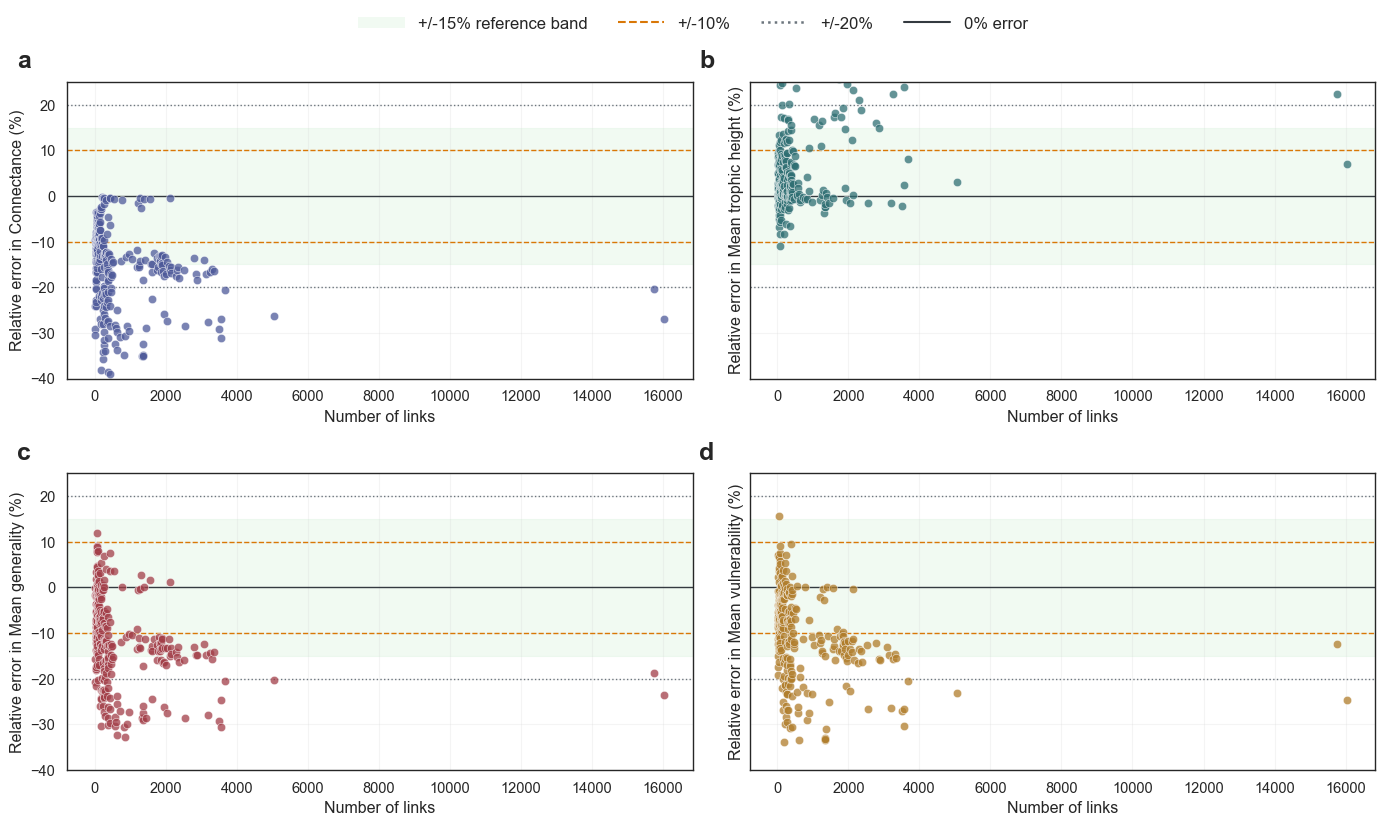

In [39]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ---------------------------------------------------------------------
# Paths and data
# ---------------------------------------------------------------------
def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src" / "matlab").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


def find_column(df, candidates, required=True):
    normalized = {
        re.sub(r"[^a-z0-9]", "", col.lower()): col
        for col in df.columns
    }

    for candidate in candidates:
        key = re.sub(r"[^a-z0-9]", "", candidate.lower())
        if key in normalized:
            return normalized[key]

    if required:
        raise KeyError(
            f"None of the candidate columns were found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )

    return None


def normalize_foodweb_name(value):
    value = str(value).strip()
    value = Path(value).stem

    suffixes = [
        "_tax_mass",
        "_tax",
        "_mass",
        ".mat",
    ]

    for suffix in suffixes:
        if value.lower().endswith(suffix):
            value = value[: -len(suffix)]

    return re.sub(r"[^a-z0-9]", "", value.lower())


ROOT = find_repo_root()
DATA_DIR = ROOT / "src/matlab/data"

ATHEN_DIR = (
    ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)

ECOSYSTEM_FILE = (
    DATA_DIR
    / "foodwebs_mat"
    / "foodweb_metrics_ecosystem.csv"
)

FIGURE_DIR = ATHEN_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = True
TRAIN_RATIO_TARGET = 60

METRIC_LABELS = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

METRIC_COLORS = {
    "Connectance": "#4E5A9A",
    "MeanGenerality": "#A23E48",
    "MeanVulnerability": "#B07D2B",
    "MeanTrophicHeight": "#2F6F73",
}


def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(
            FIGURE_DIR / filename,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
    plt.show()


# ============================================================
# Load ecosystem metadata with number of nodes
# ============================================================
if not ECOSYSTEM_FILE.exists():
    raise FileNotFoundError(f"Metadata file not found: {ECOSYSTEM_FILE}")

df_ecosystem = pd.read_csv(ECOSYSTEM_FILE).copy()

foodweb_col = find_column(
    df_ecosystem,
    ["foodweb", "food_web", "web", "network", "filename", "file"],
)

links_col = find_column(
    df_ecosystem,
    [
        "links",
        "n_links",
        "num_links",
        "linkcount",
        "l",
        "edges",
        "n_edges",
        "num_edges",
        "interactions",
        "n_interactions",
        "num_interactions",
    ],
)

df_ecosystem = df_ecosystem.rename(
    columns={
        foodweb_col: "MetadataFoodweb",
        links_col: "Links",
    }
)

df_ecosystem = df_ecosystem[
    [
        "MetadataFoodweb",
        "Links",
    ]
].copy()

df_ecosystem["MetadataFoodweb"] = df_ecosystem["MetadataFoodweb"].astype(str)
df_ecosystem["FoodwebKey"] = df_ecosystem["MetadataFoodweb"].apply(
    normalize_foodweb_name
)

df_ecosystem["Links"] = pd.to_numeric(df_ecosystem["Links"], errors="coerce")

df_ecosystem = (
    df_ecosystem
    .dropna(subset=["FoodwebKey", "Links"])
    .drop_duplicates(subset=["FoodwebKey"])
    .copy()
)

print(f"[INFO] Loaded ecosystem metadata: {len(df_ecosystem):,} food webs")


# ============================================================
# Load per-foodweb reconstruction-bias table
# ============================================================
def find_bias_input_file(search_dir):
    """
    Finds a per-foodweb CSV suitable for plotting relative error vs nodes.

    Required logical fields:
    - foodweb identifier
    - train ratio
    - metric name
    - either relative error %, or empirical + pseudo values
    """
    excluded_patterns = [
        "equivalence_sensitivity",
        "minimum_margin_required",
        "figures",
    ]

    candidate_files = sorted(search_dir.rglob("*.csv"))

    for path in candidate_files:
        name = path.name.lower()

        if any(pattern in name for pattern in excluded_patterns):
            continue

        try:
            preview = pd.read_csv(path, nrows=20)
        except Exception:
            continue

        has_foodweb = find_column(
            preview,
            ["foodweb", "food_web", "web", "network", "filename", "file"],
            required=False,
        ) is not None

        has_train_ratio = find_column(
            preview,
            ["trainratio", "train_ratio", "train", "trainingratio", "training_ratio"],
            required=False,
        ) is not None

        has_metric = find_column(
            preview,
            ["metric", "property", "networkproperty", "network_property"],
            required=False,
        ) is not None

        has_relative_error = find_column(
            preview,
            [
                "relativeerrorpercent",
                "relative_error_percent",
                "meanrelativeerrorpercent",
                "mean_relative_error_percent",
                "relativebiaspercent",
                "relative_bias_percent",
            ],
            required=False,
        ) is not None

        has_empirical = find_column(
            preview,
            [
                "empirical",
                "empiricalvalue",
                "empirical_value",
                "meanempirical",
                "mean_empirical",
            ],
            required=False,
        ) is not None

        has_pseudo = find_column(
            preview,
            [
                "pseudo",
                "pseudovalue",
                "pseudo_value",
                "meanpseudo",
                "mean_pseudo",
                "reconstructed",
                "reconstructedvalue",
                "reconstructed_value",
            ],
            required=False,
        ) is not None

        if has_foodweb and has_train_ratio and has_metric and (
            has_relative_error or (has_empirical and has_pseudo)
        ):
            print(f"[INFO] Using per-foodweb bias file: {path}")
            return path

    raise FileNotFoundError(
        "Could not find a per-foodweb reconstruction-bias CSV.\n"
        "The current eq60 / eq_all files are aggregate equivalence summaries, "
        "so they are not sufficient for plotting relative error against Nodes.\n"
        "You need a long-format CSV with Foodweb, TrainRatio, Metric, and either "
        "RelativeErrorPercent or Empirical + Pseudo values."
    )


BIAS_INPUT_FILE = find_bias_input_file(ATHEN_DIR)
df_bias_raw = pd.read_csv(BIAS_INPUT_FILE).copy()

foodweb_col = find_column(
    df_bias_raw,
    ["foodweb", "food_web", "web", "network", "filename", "file"],
)

train_col = find_column(
    df_bias_raw,
    ["trainratio", "train_ratio", "train", "trainingratio", "training_ratio"],
)

metric_col = find_column(
    df_bias_raw,
    ["metric", "property", "networkproperty", "network_property"],
)

relative_col = find_column(
    df_bias_raw,
    [
        "relativeerrorpercent",
        "relative_error_percent",
        "meanrelativeerrorpercent",
        "mean_relative_error_percent",
        "relativebiaspercent",
        "relative_bias_percent",
    ],
    required=False,
)

empirical_col = find_column(
    df_bias_raw,
    [
        "empirical",
        "empiricalvalue",
        "empirical_value",
        "meanempirical",
        "mean_empirical",
    ],
    required=False,
)

pseudo_col = find_column(
    df_bias_raw,
    [
        "pseudo",
        "pseudovalue",
        "pseudo_value",
        "meanpseudo",
        "mean_pseudo",
        "reconstructed",
        "reconstructedvalue",
        "reconstructed_value",
    ],
    required=False,
)

df_bias = df_bias_raw.rename(
    columns={
        foodweb_col: "Foodweb",
        train_col: "TrainRatio",
        metric_col: "Metric",
    }
).copy()

df_bias["Foodweb"] = df_bias["Foodweb"].astype(str)
df_bias["FoodwebKey"] = df_bias["Foodweb"].apply(normalize_foodweb_name)
df_bias["TrainRatio"] = pd.to_numeric(df_bias["TrainRatio"], errors="coerce")
df_bias["Metric"] = df_bias["Metric"].astype(str).str.strip()

if relative_col is not None:
    df_bias["RelativeErrorPercent"] = pd.to_numeric(
        df_bias_raw[relative_col],
        errors="coerce",
    )
else:
    df_bias["Empirical"] = pd.to_numeric(df_bias_raw[empirical_col], errors="coerce")
    df_bias["Pseudo"] = pd.to_numeric(df_bias_raw[pseudo_col], errors="coerce")

    df_bias["RelativeErrorPercent"] = np.where(
        df_bias["Empirical"].abs() > 0,
        100.0 * (df_bias["Pseudo"] - df_bias["Empirical"]) / df_bias["Empirical"],
        np.nan,
    )

# Optional: keep the primary analysis population only, if present.
analysis_population_col = find_column(
    df_bias_raw,
    ["analysispopulation", "analysis_population", "population"],
    required=False,
)

if analysis_population_col is not None:
    df_bias["AnalysisPopulation"] = df_bias_raw[analysis_population_col].astype(str)

    primary_mask = df_bias["AnalysisPopulation"].eq("PrimaryMean20")

    if primary_mask.any():
        df_bias = df_bias[primary_mask].copy()


# ============================================================
# Filter train ratio = 60 and aggregate repeated runs per web
# ============================================================
metrics_to_plot = list(METRIC_LABELS.keys())

plot_data = df_bias[
    (df_bias["TrainRatio"] == TRAIN_RATIO_TARGET)
    & (df_bias["Metric"].isin(metrics_to_plot))
].copy()

if plot_data.empty:
    raise ValueError(
        f"No rows found for TrainRatio == {TRAIN_RATIO_TARGET} "
        f"and metrics {metrics_to_plot}."
    )

plot_data = (
    plot_data
    .groupby(["FoodwebKey", "Foodweb", "Metric"], as_index=False)
    .agg(
        RelativeErrorPercent=("RelativeErrorPercent", "mean"),
    )
)

plot_data = plot_data.merge(
    df_ecosystem[["FoodwebKey", "Links"]],
    on="FoodwebKey",
    how="left",
)

missing_links = plot_data["Links"].isna().sum()

if missing_links > 0:
    print(f"[WARNING] Rows without link metadata removed: {missing_links:,}")

plot_data = plot_data.dropna(subset=["Links", "RelativeErrorPercent"]).copy()

print(
    "[INFO] Plot data:",
    f"{plot_data['FoodwebKey'].nunique():,} food webs,",
    f"{len(plot_data):,} metric rows",
)


# ============================================================
# New plot:
# Reconstruction bias at train ratio 60 vs number of links
# Zoomed y-axis shared across all panels
# ============================================================

Y_LIMITS = (-40, 25)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=True)
axes = axes.ravel()
panel_letters = ["a", "b", "c", "d"]

for i, (ax, metric) in enumerate(zip(axes, metrics_to_plot)):
    data = plot_data[plot_data["Metric"] == metric].sort_values("Links")
    color = METRIC_COLORS[metric]

    ax.axhspan(-15, 15, color="#d8f3dc", alpha=0.35, zorder=0)
    ax.axhline(-10, color="#d97706", linestyle="--", linewidth=1, zorder=1)
    ax.axhline(10, color="#d97706", linestyle="--", linewidth=1, zorder=1)
    ax.axhline(-20, color="#6c757d", linestyle=":", linewidth=1, zorder=1)
    ax.axhline(20, color="#6c757d", linestyle=":", linewidth=1, zorder=1)
    ax.axhline(0, color="#343a40", linewidth=1, zorder=1)

    ax.scatter(
        data["Links"],
        data["RelativeErrorPercent"],
        color=color,
        s=36,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.4,
        zorder=2,
        clip_on=True,
    )

    ax.set_ylim(Y_LIMITS)

    outside_axis = (
        (data["RelativeErrorPercent"] < Y_LIMITS[0])
        | (data["RelativeErrorPercent"] > Y_LIMITS[1])
    ).sum()

    # if outside_axis > 0:
    #     ax.text(
    #         0.98,
    #         0.95,
    #         f"{outside_axis} points outside axis",
    #         transform=ax.transAxes,
    #         ha="right",
    #         va="top",
    #         fontsize=9,
    #         color="#555555",
    #     )

    ax.set_xlabel("Number of links")
    ax.set_ylabel(f"Relative error in {METRIC_LABELS[metric]} (%)")
    ax.grid(alpha=0.2)

    ax.text(
        -0.08,
        1.03,
        panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

legend_handles = [
    Patch(
        facecolor="#d8f3dc",
        edgecolor="none",
        alpha=0.35,
        label="+/-15% reference band",
    ),
    Line2D(
        [0],
        [0],
        color="#d97706",
        linestyle="--",
        linewidth=1.5,
        label="+/-10%",
    ),
    Line2D(
        [0],
        [0],
        color="#6c757d",
        linestyle=":",
        linewidth=1.8,
        label="+/-20%",
    ),
    Line2D(
        [0],
        [0],
        color="#343a40",
        linestyle="-",
        linewidth=1.5,
        label="0% error",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=4,
    frameon=False,
    fontsize=12,
    handlelength=2.8,
    columnspacing=1.8,
)

finish_figure(
    fig,
    "athen_relative_error_train60_vs_links_zoomed.png",
)

[INFO] Loaded final Athen web-level data: 1,160 food-web x metric rows
[INFO] Plotting rows after empirical/mean-pseudo expansion: 2,320
[INFO] This figure uses one mean pseudo value per empirical food web, not Eoin run-level pseudo values.
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/statistical_tests/athen/athen_final_web_level_boxplots_train60.png


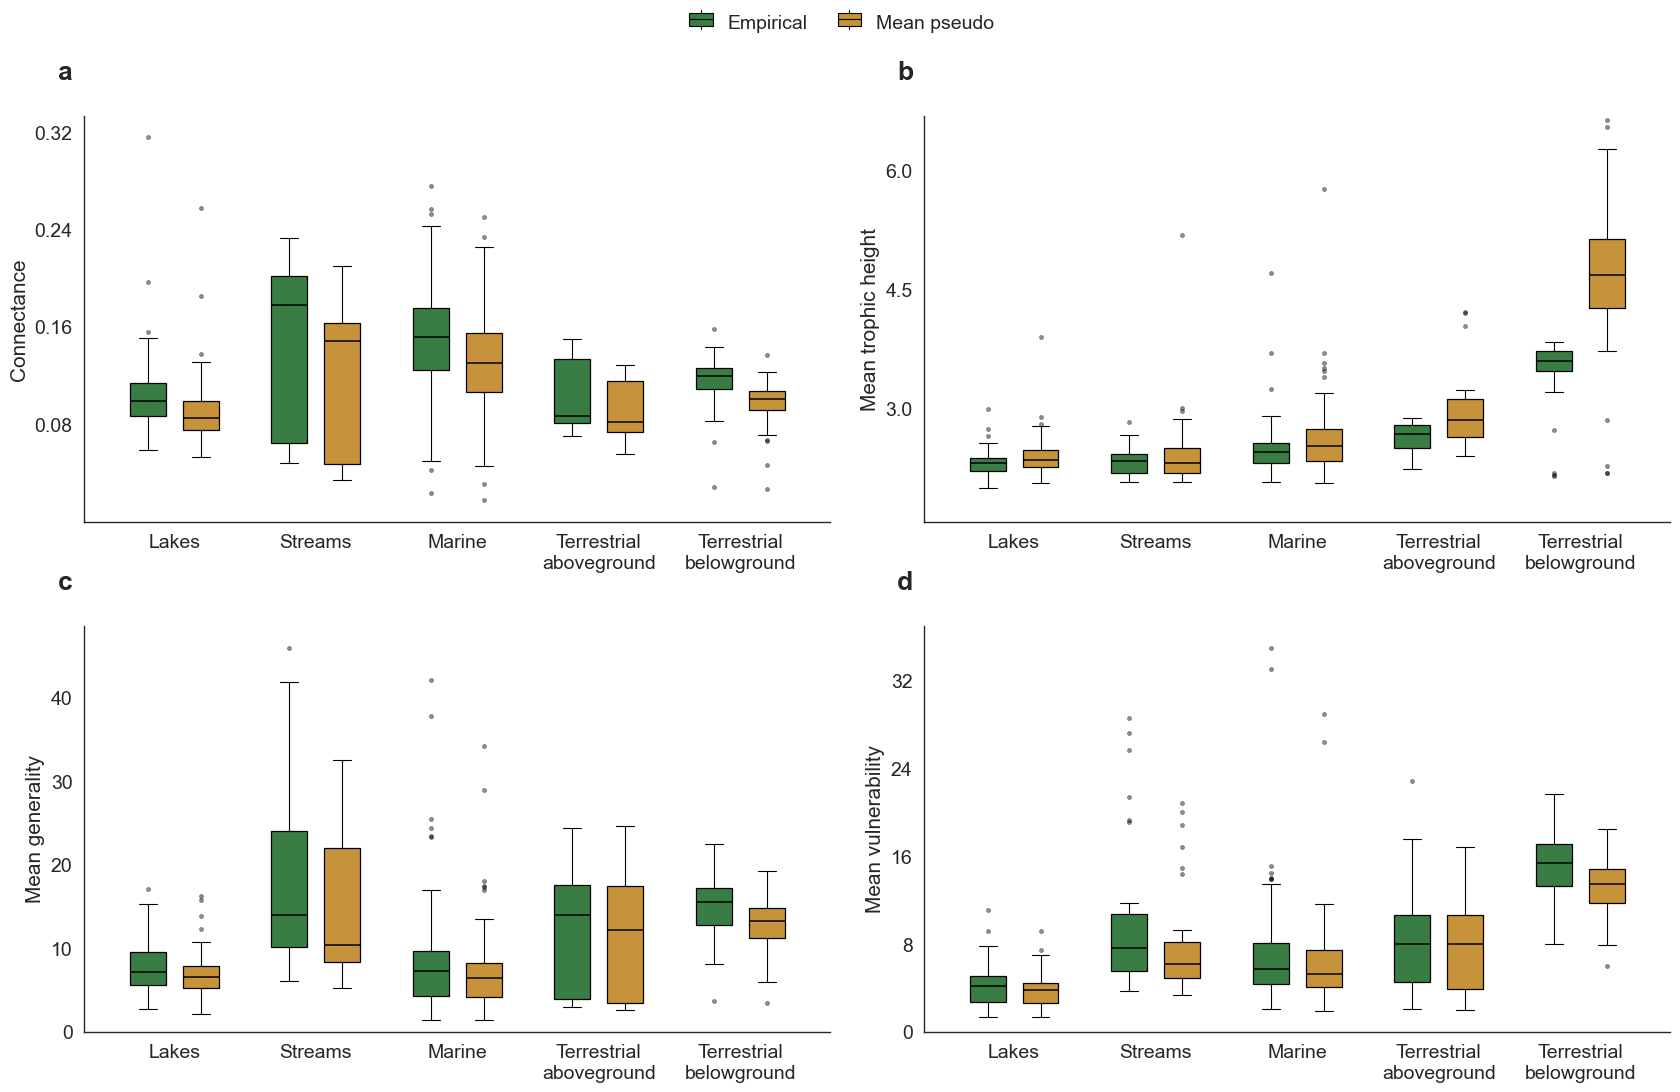

In [40]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()
TRAIN_RATIO = 60

ATHEN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)

ATHEN_WEB_LEVEL = ATHEN_DIR / "athen_web_level_metrics_all_ratios.csv"

OUT_PATH = ATHEN_DIR / f"athen_final_web_level_boxplots_train{TRAIN_RATIO}.png"

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Mean pseudo": "#C6923A",
}

# Hide only extreme plotted fliers for readability if needed.
# The boxplot statistics still use all values.
HIDE_FLIERS_METRICS = set()

# Focus trophic-height panel on the boxplot range, because a few webs have high values.
ZOOM_TO_BOXPLOT_RANGE_METRICS = {
    "MeanTrophicHeight",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())


def draw_box(ax, values, position, facecolor, showfliers=True):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_zoom_ylim_with_some_outliers(
    grouped_values,
    lower_bound=0.0,
    pad_fraction=0.10,
    upper_percentile=97.5,
):
    visible_lows = []
    visible_highs = []
    all_values = []

    for values in grouped_values:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        all_values.extend(values.tolist())

        q1, q3 = np.nanpercentile(values, [25, 75])
        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr
            non_fliers = values[(values >= lower_fence) & (values <= upper_fence)]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(non_fliers)
            upper_whisker = np.nanmax(non_fliers)

        visible_lows.extend([q1, lower_whisker])
        visible_highs.extend([q3, upper_whisker])

    if not visible_lows or not visible_highs:
        return None

    all_values = np.asarray(all_values, dtype=float)
    all_values = all_values[np.isfinite(all_values)]

    whisker_min = np.nanmin(visible_lows)
    whisker_max = np.nanmax(visible_highs)
    percentile_cap = np.nanpercentile(all_values, upper_percentile)

    local_min = whisker_min
    local_max = max(whisker_max, percentile_cap)

    data_range = local_max - local_min if local_max > local_min else 0.05

    local_min = max(lower_bound, local_min - pad_fraction * data_range)
    local_max = local_max + pad_fraction * data_range

    if np.isclose(local_min, local_max):
        local_min = max(lower_bound, local_min - 0.02)
        local_max = local_max + 0.02

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# LOAD FINAL ATHEN WEB-LEVEL DATA
# ============================================================
athen = pd.read_csv(ATHEN_WEB_LEVEL)

athen["TrainRatio"] = pd.to_numeric(athen["TrainRatio"], errors="coerce")
athen["EmpiricalValue"] = pd.to_numeric(athen["EmpiricalValue"], errors="coerce")
athen["MeanPseudo"] = pd.to_numeric(athen["MeanPseudo"], errors="coerce")

if "IncludedPrimary" in athen.columns:
    athen["IncludedPrimary"] = pd.to_numeric(athen["IncludedPrimary"], errors="coerce").fillna(0).astype(int)
else:
    athen["IncludedPrimary"] = 1

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & (athen["Metric"].isin(metric_order))
        & (athen["IncludedPrimary"] == 1)
    ]
    .copy()
)

plot_source["ecosystem"] = plot_source["EcosystemType"].astype(str).str.strip().str.lower()

# Build plotting dataframe:
# one empirical value per food web and one mean pseudo value per food web.
empirical_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "EmpiricalValue"]
].rename(columns={"EmpiricalValue": "value"})
empirical_df["Web type"] = "Empirical"

pseudo_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "MeanPseudo"]
].rename(columns={"MeanPseudo": "value"})
pseudo_df["Web type"] = "Mean pseudo"

plot_df = pd.concat([empirical_df, pseudo_df], ignore_index=True)
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
plot_df = plot_df.dropna(subset=["value", "ecosystem", "Metric", "Web type"])

print(f"[INFO] Loaded final Athen web-level data: {len(plot_source):,} food-web x metric rows")
print(f"[INFO] Plotting rows after empirical/mean-pseudo expansion: {len(plot_df):,}")
print("[INFO] This figure uses one mean pseudo value per empirical food web, not Eoin run-level pseudo values.")

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Mean pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Mean pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = plot_df[plot_df["Metric"] == metric].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING

    all_values = []
    boxplot_groups = []
    show_fliers = metric not in HIDE_FLIERS_METRICS

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        empirical_values = (
            eco_df[eco_df["Web type"] == "Empirical"]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            eco_df[eco_df["Web type"] == "Mean pseudo"]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
                showfliers=show_fliers,
            )
            all_values.extend(empirical_values)
            boxplot_groups.append(empirical_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Mean pseudo"],
                showfliers=show_fliers,
            )
            all_values.extend(pseudo_values)
            boxplot_groups.append(pseudo_values)

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    panel_vals = np.asarray(all_values, dtype=float)
    panel_vals = panel_vals[np.isfinite(panel_vals)]

    if panel_vals.size:
        if metric in ZOOM_TO_BOXPLOT_RANGE_METRICS:
            ylim = get_boxplot_zoom_ylim_with_some_outliers(
                boxplot_groups,
                lower_bound=0.0,
                pad_fraction=0.10,
                upper_percentile=97.5,
            )
            if ylim is not None:
                ax.set_ylim(*ylim)
        else:
            local_min = np.nanmin(panel_vals)
            local_max = np.nanmax(panel_vals)
            data_range = local_max - local_min if local_max > local_min else 0.05

            local_min = max(0.0, local_min - 0.06 * data_range)
            local_max = local_max + 0.06 * data_range

            if np.isclose(local_min, local_max):
                local_min = max(0.0, local_min - 0.02)
                local_max = local_max + 0.02

            ax.set_ylim(local_min, local_max)

        ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

# ============================================================
# GLOBAL LEGEND
# ============================================================
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={dict: HandlerMiniBoxplot()},
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=0)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Loaded final Athen web-level data: 1,160 food-web x metric rows
[INFO] Plotting rows after empirical/mean-pseudo expansion: 2,320
[INFO] This figure uses one mean pseudo value per empirical food web, not Eoin run-level pseudo values.
[INFO] Outlier points are not displayed in any panel.
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/statistical_tests/athen/athen_final_web_level_boxplots_train60_no_outliers.png


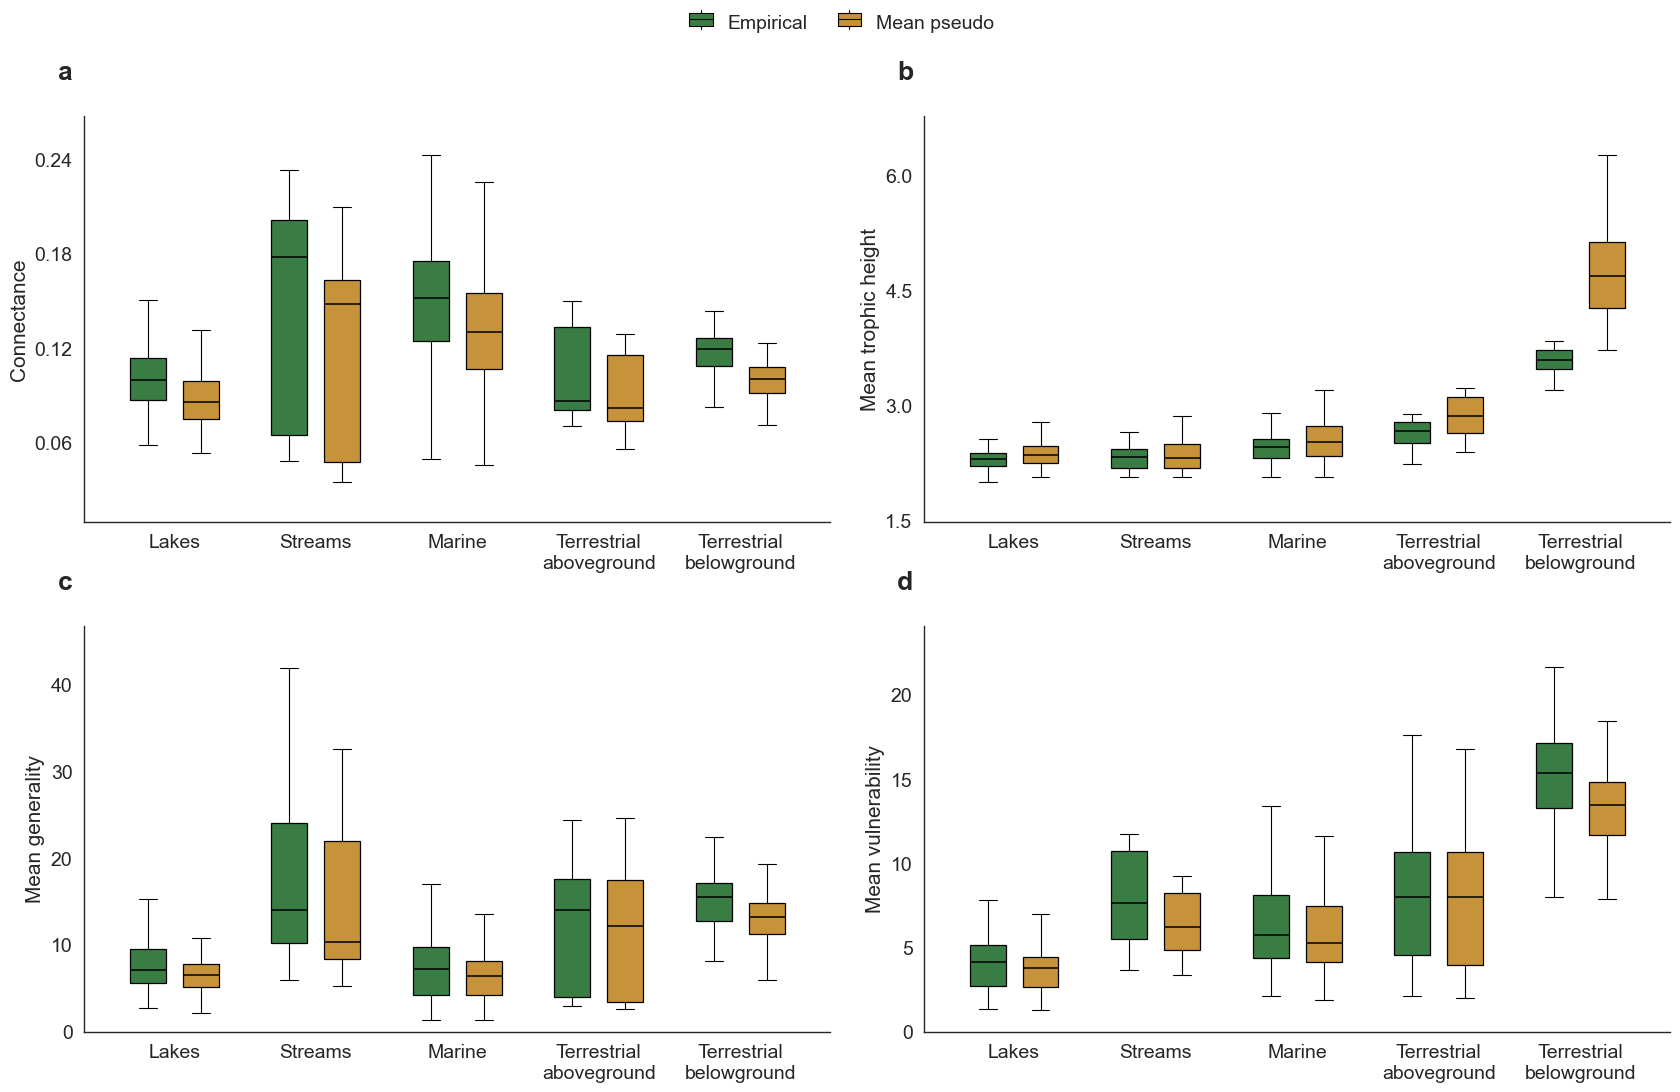

In [41]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()
TRAIN_RATIO = 60

ATHEN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)

ATHEN_WEB_LEVEL = ATHEN_DIR / "athen_web_level_metrics_all_ratios.csv"

OUT_PATH = ATHEN_DIR / f"athen_final_web_level_boxplots_train{TRAIN_RATIO}_no_outliers.png"

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Mean pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())


def draw_box(ax, values, position, facecolor):
    """
    Draw a boxplot without plotted outliers.

    Important:
    - Outlier points are not displayed.
    - Box, median and whiskers are still calculated from the full input values.
    """
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
    )


def get_boxplot_visible_ylim(grouped_values, lower_bound=0.0, pad_fraction=0.12):
    """
    Compute y-limits from visible boxplot components only:
    Q1, Q3, lower whisker and upper whisker.

    This prevents hidden outliers from controlling the panel scale.
    """
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(values, [25, 75])
        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr

            non_fliers = values[
                (values >= lower_fence)
                & (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(non_fliers)
            upper_whisker = np.nanmax(non_fliers)

        visible_lows.extend([lower_whisker, q1])
        visible_highs.extend([upper_whisker, q3])

    if not visible_lows or not visible_highs:
        return None

    local_min = np.nanmin(visible_lows)
    local_max = np.nanmax(visible_highs)

    data_range = local_max - local_min if local_max > local_min else 0.05

    local_min = max(lower_bound, local_min - pad_fraction * data_range)
    local_max = local_max + pad_fraction * data_range

    if np.isclose(local_min, local_max):
        local_min = max(lower_bound, local_min - 0.02)
        local_max = local_max + 0.02

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# LOAD FINAL ATHEN WEB-LEVEL DATA
# ============================================================
athen = pd.read_csv(ATHEN_WEB_LEVEL)

athen["TrainRatio"] = pd.to_numeric(athen["TrainRatio"], errors="coerce")
athen["EmpiricalValue"] = pd.to_numeric(athen["EmpiricalValue"], errors="coerce")
athen["MeanPseudo"] = pd.to_numeric(athen["MeanPseudo"], errors="coerce")

if "IncludedPrimary" in athen.columns:
    athen["IncludedPrimary"] = (
        pd.to_numeric(athen["IncludedPrimary"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
else:
    athen["IncludedPrimary"] = 1

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & (athen["Metric"].isin(metric_order))
        & (athen["IncludedPrimary"] == 1)
    ]
    .copy()
)

plot_source["ecosystem"] = (
    plot_source["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Build plotting dataframe:
# one empirical value per food web and one mean pseudo value per food web.
empirical_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "EmpiricalValue"]
].rename(columns={"EmpiricalValue": "value"})
empirical_df["Web type"] = "Empirical"

pseudo_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "MeanPseudo"]
].rename(columns={"MeanPseudo": "value"})
pseudo_df["Web type"] = "Mean pseudo"

plot_df = pd.concat([empirical_df, pseudo_df], ignore_index=True)
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
plot_df = plot_df.dropna(subset=["value", "ecosystem", "Metric", "Web type"])

print(f"[INFO] Loaded final Athen web-level data: {len(plot_source):,} food-web x metric rows")
print(f"[INFO] Plotting rows after empirical/mean-pseudo expansion: {len(plot_df):,}")
print("[INFO] This figure uses one mean pseudo value per empirical food web, not Eoin run-level pseudo values.")
print("[INFO] Outlier points are not displayed in any panel.")

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Mean pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Mean pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = plot_df[plot_df["Metric"] == metric].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING

    boxplot_groups = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        empirical_values = (
            eco_df[eco_df["Web type"] == "Empirical"]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            eco_df[eco_df["Web type"] == "Mean pseudo"]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
            )
            boxplot_groups.append(empirical_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Mean pseudo"],
            )
            boxplot_groups.append(pseudo_values)

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    ylim = get_boxplot_visible_ylim(
        boxplot_groups,
        lower_bound=0.0,
        pad_fraction=0.12,
    )

    if ylim is not None:
        ax.set_ylim(*ylim)
        ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

# ============================================================
# GLOBAL LEGEND
# ============================================================
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={dict: HandlerMiniBoxplot()},
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=0)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/statistical_tests/athen/outlier_filtered/train_ratio_60/athen_web_level_metrics_train60_outlier_filtered.csv
[INFO] Loaded outlier-filtered web-level rows: 1,159
[INFO] Plotting rows after empirical/mean-pseudo expansion: 2,318
[INFO] Each food web contributes one empirical value and one filtered mean pseudo value.
[INFO] Mean pseudo values were calculated after removing pseudo-run outliers.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,202,14,20.0
1,MeanGenerality,290,227,14,20.0
2,MeanTrophicHeight,289,447,11,18.0
3,MeanVulnerability,290,178,14,20.0


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/statistical_tests/athen/outlier_filtered/train_ratio_60/fig5_wlnm_dir_neg_train60_web_level_outlier_filtered.png


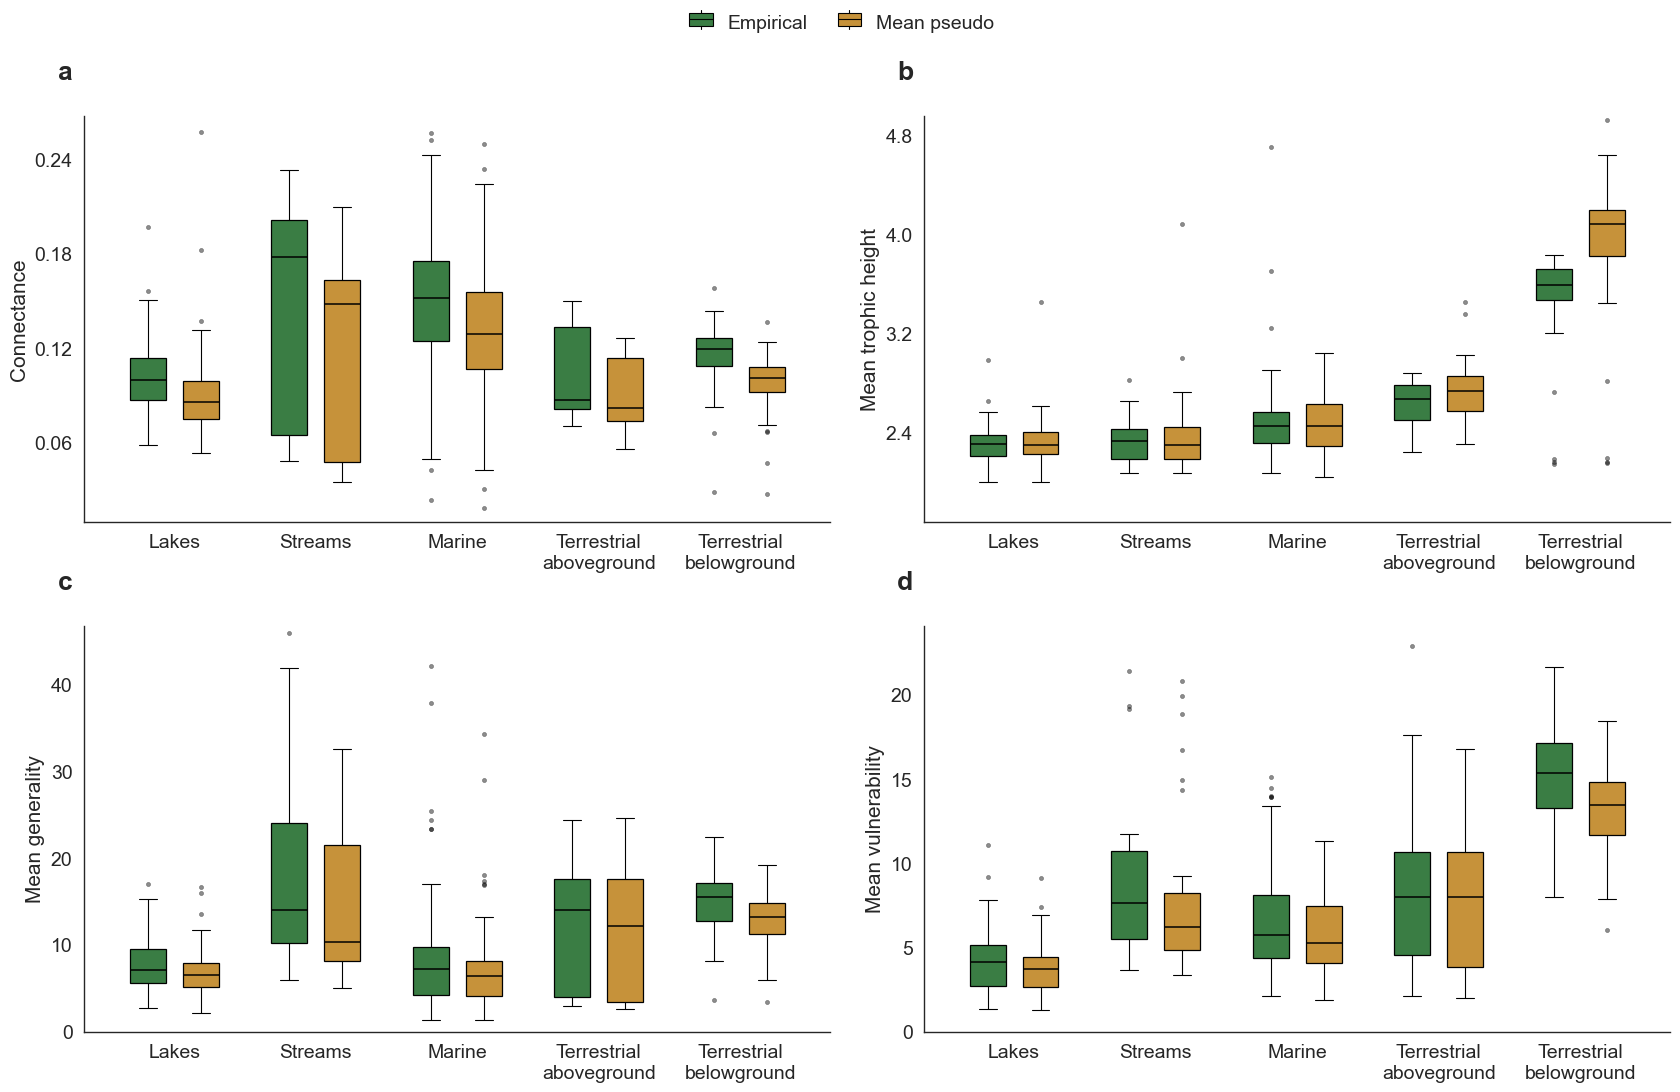

In [43]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()
TRAIN_RATIO = 60

ATHEN_OUTLIER_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen/outlier_filtered"
    / f"train_ratio_{TRAIN_RATIO}"
)

ATHEN_WEB_LEVEL_FILTERED = (
    ATHEN_OUTLIER_DIR
    / f"athen_web_level_metrics_train{TRAIN_RATIO}_outlier_filtered.csv"
)

OUT_PATH = (
    ATHEN_OUTLIER_DIR
    / f"fig5_wlnm_dir_neg_train{TRAIN_RATIO}_web_level_outlier_filtered.png"
)

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

# These are web-level boxplot fliers, not the pseudo-run outliers.
# Pseudo-run outliers have already been removed before MeanPseudoAfterFiltering.
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Mean pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())


def draw_box(ax, values, position, facecolor, showfliers=False):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(grouped_values, lower_bound=0.0, pad_fraction=0.12):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(values, [25, 75])
        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr

            non_fliers = values[
                (values >= lower_fence)
                & (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(non_fliers)
            upper_whisker = np.nanmax(non_fliers)

        visible_lows.extend([lower_whisker, q1])
        visible_highs.extend([upper_whisker, q3])

    if not visible_lows or not visible_highs:
        return None

    local_min = np.nanmin(visible_lows)
    local_max = np.nanmax(visible_highs)

    data_range = local_max - local_min if local_max > local_min else 0.05

    local_min = max(lower_bound, local_min - pad_fraction * data_range)
    local_max = local_max + pad_fraction * data_range

    if np.isclose(local_min, local_max):
        local_min = max(lower_bound, local_min - 0.02)
        local_max = local_max + 0.02

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# LOAD OUTLIER-FILTERED WEB-LEVEL DATA
# ============================================================
athen = pd.read_csv(ATHEN_WEB_LEVEL_FILTERED)

athen["TrainRatio"] = pd.to_numeric(athen["TrainRatio"], errors="coerce")
athen["EmpiricalValue"] = pd.to_numeric(athen["EmpiricalValue"], errors="coerce")
athen["MeanPseudoAfterFiltering"] = pd.to_numeric(
    athen["MeanPseudoAfterFiltering"],
    errors="coerce",
)
athen["IncludedAfterFiltering"] = (
    pd.to_numeric(athen["IncludedAfterFiltering"], errors="coerce")
    .fillna(0)
    .astype(int)
)
athen["OutlierRunsRemoved"] = pd.to_numeric(
    athen["OutlierRunsRemoved"],
    errors="coerce",
).fillna(0).astype(int)
athen["ValidRunsAfterFiltering"] = pd.to_numeric(
    athen["ValidRunsAfterFiltering"],
    errors="coerce",
).fillna(0).astype(int)

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & (athen["Metric"].isin(metric_order))
        & (athen["IncludedAfterFiltering"] == 1)
    ]
    .copy()
)

plot_source["ecosystem"] = (
    plot_source["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Build plotting dataframe:
# one empirical value per food web and one filtered mean pseudo value per food web.
empirical_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "EmpiricalValue"]
].rename(columns={"EmpiricalValue": "value"})
empirical_df["Web type"] = "Empirical"

pseudo_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "MeanPseudoAfterFiltering"]
].rename(columns={"MeanPseudoAfterFiltering": "value"})
pseudo_df["Web type"] = "Mean pseudo"

plot_df = pd.concat([empirical_df, pseudo_df], ignore_index=True)
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
plot_df = plot_df.dropna(subset=["value", "ecosystem", "Metric", "Web type"])

print(f"[INFO] Source file: {ATHEN_WEB_LEVEL_FILTERED}")
print(f"[INFO] Loaded outlier-filtered web-level rows: {len(plot_source):,}")
print(f"[INFO] Plotting rows after empirical/mean-pseudo expansion: {len(plot_df):,}")
print("[INFO] Each food web contributes one empirical value and one filtered mean pseudo value.")
print("[INFO] Mean pseudo values were calculated after removing pseudo-run outliers.")

removed_summary = (
    plot_source
    .groupby("Metric", as_index=False)
    .agg(
        FoodWebs=("FoodWeb", "nunique"),
        TotalPseudoRunOutliersRemoved=("OutlierRunsRemoved", "sum"),
        MinRetainedRuns=("ValidRunsAfterFiltering", "min"),
        MedianRetainedRuns=("ValidRunsAfterFiltering", "median"),
    )
)

display(removed_summary)

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Mean pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Mean pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = plot_df[plot_df["Metric"] == metric].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING
    boxplot_groups = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        empirical_values = (
            eco_df[eco_df["Web type"] == "Empirical"]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            eco_df[eco_df["Web type"] == "Mean pseudo"]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
                showfliers=SHOW_WEB_LEVEL_FLIERS,
            )
            boxplot_groups.append(empirical_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Mean pseudo"],
                showfliers=SHOW_WEB_LEVEL_FLIERS,
            )
            boxplot_groups.append(pseudo_values)

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    ylim = get_boxplot_visible_ylim(
        boxplot_groups,
        lower_bound=0.0,
        pad_fraction=0.12,
    )

    if ylim is not None:
        ax.set_ylim(*ylim)
        ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

# ============================================================
# GLOBAL LEGEND
# ============================================================
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={dict: HandlerMiniBoxplot()},
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=0)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in run-level results before node filter: 290
[INFO] Applied TrainRatio filter: TrainRatio == 90
[INFO] Run-level rows after filtering: 11,460
Version
dir_neg     5800
original    5660
dtype: int64
[INFO] Web-level rows after averaging runs: 573
          FoodWebs  MinRuns  MedianRuns  MaxRuns
Version                                         
dir_neg        290       20        20.0       20
original       283       20        20.0       20

=== Web-level predictive metric summary ===


,Version,Metric,N food webs,Mean,Median,SD,Variance
0,Original,ROC-AUC,283,0.7686,0.8244,0.1812,0.0328
1,Original,PR-AUC,283,0.5328,0.5946,0.2201,0.0484
2,Original,F1,283,0.5700,0.6471,0.2576,0.0664
3,Original,MCC,283,0.4415,0.5218,0.2910,0.0847
4,Original,Precision,283,0.6046,0.7000,0.2594,0.0673
5,Original,Recall,283,0.5642,0.6250,0.2650,0.0702
6,Original,TSS,283,0.4359,0.5000,0.2796,0.0782
7,Directed-negative,ROC-AUC,290,0.8352,0.8440,0.1194,0.0142
8,Directed-negative,PR-AUC,290,0.5461,0.5870,0.1751,0.0307
9,Directed-negative,F1,290,0.6196,0.6528,0.2239,0.0501


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/statistical_tests/athen/figures/predictive_metrics_original_vs_dir_neg_train90_web_level.png


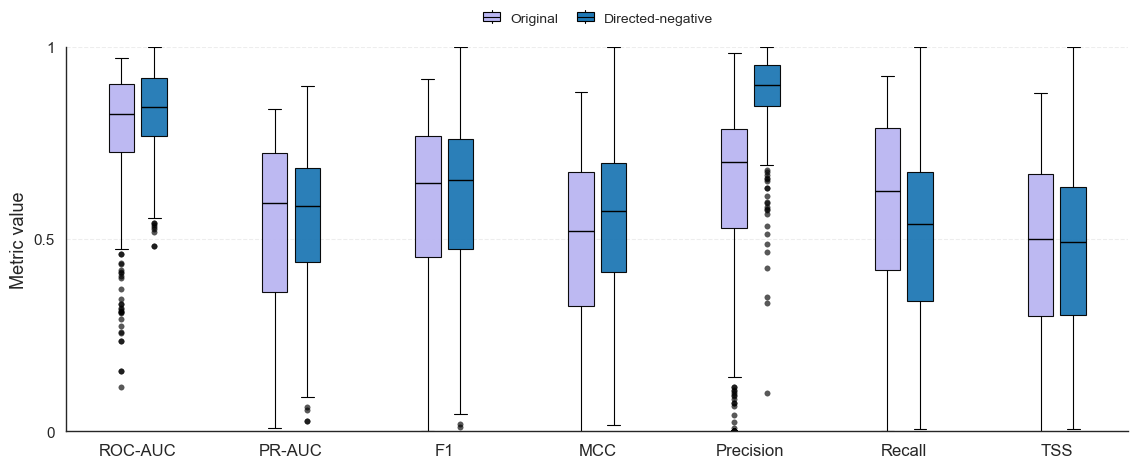

In [45]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.1)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
TRAIN_RATIO_TARGET = 90
NODES_THRESHOLD = 0

RESULTS_DIR_ORIGINAL = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "prediction_scores_logs"
)

RESULTS_DIR_DIR_NEG = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "prediction_scores_logs"
)

FOODWEB_CSV = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / f"predictive_metrics_original_vs_dir_neg_train{TRAIN_RATIO_TARGET}_web_level.png"

METRICS = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]

K_TARGET = None
K_COL = "K"
TRAIN_RATIO_COL = "TrainRatio"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIR_NEG = "*_tax_mass_results_random_wlnm_dir_neg.csv"

SHOW_WEB_LEVEL_FLIERS = True

# ============================================================
# Helpers
# ============================================================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])

    if TRAIN_RATIO_COL not in df.columns:
        print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
        return None

    df = df[df[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

    if df.empty:
        return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    records = []
    foodweb = parse_foodweb_from_name(csv_path.name)

    for run_idx, row in df.reset_index(drop=True).iterrows():
        out = {
            "Foodweb": foodweb,
            "Version": version,
            "Run": run_idx + 1,
            "n_runs_in_file_after_filter": int(len(df)),
            "file": csv_path.name,
            "folder": str(csv_path.parent),
        }

        valid_any = False

        for metric in METRICS:
            if metric in df.columns:
                val = row[metric]
                out[metric] = float(val) if pd.notna(val) else np.nan
                if pd.notna(val):
                    valid_any = True
            else:
                out[metric] = np.nan

        if valid_any:
            records.append(out)

    return records if records else None


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        recs = load_one_csv(p, version=version)
        if recs is not None:
            rows.extend(recs)

    return rows


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# Load run-level CSVs
# ============================================================
rows = []
rows += load_folder(
    RESULTS_DIR_ORIGINAL,
    GLOB_PATTERN_ORIGINAL,
    version="original",
)
rows += load_folder(
    RESULTS_DIR_DIR_NEG,
    GLOB_PATTERN_DIR_NEG,
    version="dir_neg",
)

run_df = pd.DataFrame(rows)

if run_df.empty:
    raise RuntimeError("No valid rows after loading folders. Check paths or CSV columns.")

# ============================================================
# Apply node filter
# ============================================================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
run_df["FW_KEY"] = run_df["Foodweb"].apply(normalize_fw_label)

allowed_fw_keys = set(
    meta.loc[meta[nodes_col] >= NODES_THRESHOLD, "FW_KEY"].unique()
)

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in run-level results before node filter: {run_df['FW_KEY'].nunique()}")

run_df = run_df[run_df["FW_KEY"].isin(allowed_fw_keys)].copy()

if run_df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")
print(f"[INFO] Run-level rows after filtering: {len(run_df):,}")
print(run_df.groupby("Version").size())

# ============================================================
# Web-level aggregation
# ============================================================
# This is the key correction:
# one row per Foodweb × Version, after averaging repeated runs.
agg_dict = {metric: "mean" for metric in METRICS}
agg_dict["Run"] = "count"

web_df = (
    run_df
    .groupby(["Foodweb", "FW_KEY", "Version"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"Run": "ValidRuns"})
)

print(f"[INFO] Web-level rows after averaging runs: {len(web_df):,}")
print(web_df.groupby("Version").agg(
    FoodWebs=("Foodweb", "nunique"),
    MinRuns=("ValidRuns", "min"),
    MedianRuns=("ValidRuns", "median"),
    MaxRuns=("ValidRuns", "max"),
))

# ============================================================
# Summary table
# ============================================================
order = ["original", "dir_neg"]

label_map = {
    "original": "Original",
    "dir_neg": "Directed-negative",
}

palette = {
    "original": "#bab6f2",
    "dir_neg": "#1f78b4",
}

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

summary_rows = []

for version in order:
    for metric_col, metric_label in plot_metrics:
        vals = web_df.loc[web_df["Version"] == version, metric_col].dropna()

        summary_rows.append({
            "Version": label_map.get(version, version),
            "Metric": metric_label,
            "N food webs": int(vals.shape[0]),
            "Mean": vals.mean(),
            "Median": vals.median(),
            "SD": vals.std(ddof=1),
            "Variance": vals.var(ddof=1),
        })

summary_table = pd.DataFrame(summary_rows)
for col in ["Mean", "Median", "SD", "Variance"]:
    summary_table[col] = summary_table[col].round(4)

print("\n=== Web-level predictive metric summary ===")
display(summary_table)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

offsets = np.array([-0.16, 0.16])
box_width = 0.25

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            web_df.loc[web_df["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.65,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [label for _, label in plot_metrics],
    rotation=0,
    ha="center",
    fontsize=12,
)

ax.set_ylabel("Metric value", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(order),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(ax=ax)
plt.tight_layout()

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Using LOG_DIR: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs
[INFO] Found 870 CSV files matching pattern: *tax_mass_results_random_wlnm_dir_neg_kfold*.csv

[INFO] Run-level data shape:
(104400, 13)

[INFO] Foodweb count per CvK before web-level averaging:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64

[INFO] Raw row count per CvK before web-level averaging:
CvK
3     17400
5     29000
10    58000
dtype: int64

[INFO] Web-level data shape after averaging repeated run/fold rows:
(870, 13)

[INFO] Web-level count and rows averaged per CvK:


,CvK,FoodWebs,TrainRatio,MinRowsAveraged,MedianRowsAveraged,MaxRowsAveraged
0,3,290,66.6667,60,60.0,60
1,5,290,80.0000,100,100.0,100
2,10,290,90.0000,200,200.0,200



=== Web-level k-fold predictive metric summary ===


,CvK,Label,Metric,N food webs,Mean,Median,SD,Variance
0,3,3-fold (66.7% train),ROC-AUC,290,0.8075,0.8069,0.1148,0.0132
1,3,3-fold (66.7% train),PR-AUC,290,0.5637,0.6172,0.1585,0.0251
2,3,3-fold (66.7% train),F1,290,0.6090,0.6319,0.2005,0.0402
3,3,3-fold (66.7% train),MCC,290,0.5351,0.5360,0.2096,0.0439
4,3,3-fold (66.7% train),Precision,290,0.8275,0.8449,0.1278,0.0163
5,3,3-fold (66.7% train),Recall,290,0.5194,0.5227,0.2206,0.0487
6,3,3-fold (66.7% train),TSS,290,0.4667,0.4646,0.2314,0.0535
7,5,5-fold (80% train),ROC-AUC,290,0.8210,0.8235,0.1136,0.0129
8,5,5-fold (80% train),PR-AUC,290,0.5621,0.6111,0.1612,0.0260
9,5,5-fold (80% train),F1,290,0.6165,0.6507,0.2081,0.0433


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/athen/figures/predictive_metrics_wlnm_dir_neg_kfold_web_level.png


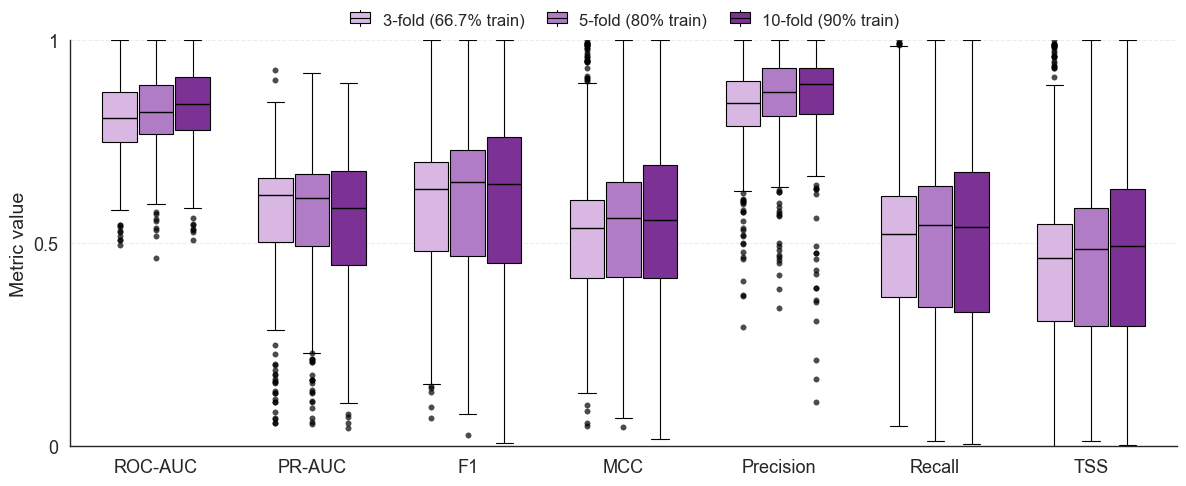

In [46]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
LOG_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "prediction_scores_logs"
)

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / "predictive_metrics_wlnm_dir_neg_kfold_web_level.png"

PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold*.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]

SHOW_WEB_LEVEL_FLIERS = True

METRIC_SOURCES = {
    "ROC_AUC": ["ROC_AUC"],
    "PR_AUC": ["PR_AUC"],
    "F1Score": ["F1Score", "TestF1Score", "PseudoF1Score"],
    "TestMCC": ["TestMCC", "PseudoMCC"],
    "Precision": ["Precision", "TestPrecision", "PseudoPrecision"],
    "Recall": ["Recall", "TestRecall", "PseudoRecall"],
    "TestTSS": ["TestTSS", "PseudoTSS"],
}

METRICS = list(METRIC_SOURCES.keys())

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

# ============================================================
# Helpers
# ============================================================
def cvk_label(k: int) -> str:
    train_ratio_map = {
        3: "66.7%",
        5: "80%",
        10: "90%",
    }
    if k in train_ratio_map:
        return f"{k}-fold ({train_ratio_map[k]} train)"
    return f"{k}-fold"


def foodweb_name_from_path(p: str) -> str:
    name = Path(p).name
    return re.sub(
        r"_tax_mass_results_random_wlnm_dir_neg_kfold(?:_cvK\d+)?\.csv$",
        "",
        name,
    )


def find_metric_columns(df: pd.DataFrame):
    selected = {}
    missing = []

    for metric, candidates in METRIC_SOURCES.items():
        source_col = next((col for col in candidates if col in df.columns), None)

        if source_col is None:
            missing.append(f"{metric} ({' / '.join(candidates)})")
        else:
            selected[metric] = source_col

    return selected, missing


def collect_run_level_metrics(log_dir: Path, pattern: str) -> pd.DataFrame:
    expected_cols = [
        "CvK",
        "CvK_label",
        "Foodweb",
        "RunRow",
        "TrainRatio",
        "K",
        *METRICS,
    ]

    rows = []
    csv_files = sorted(glob.glob(str(Path(log_dir) / pattern)))

    print(f"[INFO] Using LOG_DIR: {log_dir}")
    print(f"[INFO] Found {len(csv_files)} CSV files matching pattern: {pattern}")

    if not csv_files:
        return pd.DataFrame(columns=expected_cols)

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {Path(csv_path).name} read error: {e}")
            continue

        if "CvK" not in df.columns:
            print(f"[SKIP] {Path(csv_path).name} missing column: CvK")
            continue

        metric_sources, missing_metrics = find_metric_columns(df)
        if missing_metrics:
            print(f"[SKIP] {Path(csv_path).name} missing metrics: {missing_metrics}")
            continue

        df = df.copy()
        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce")
        df["TrainRatio"] = pd.to_numeric(df.get("TrainRatio"), errors="coerce")

        if "K" in df.columns:
            df["K"] = pd.to_numeric(df["K"], errors="coerce")
            if K_TARGET is not None:
                df = df[df["K"] == K_TARGET].copy()
        else:
            df["K"] = np.nan

        df = df[df["CvK"].isin(cvk_order)].copy()

        if df.empty:
            continue

        for metric, source_col in metric_sources.items():
            df[metric] = pd.to_numeric(df[source_col], errors="coerce")

        df["CvK"] = df["CvK"].astype("Int64")
        df["Foodweb"] = foodweb_name_from_path(csv_path)
        df["RunRow"] = df.groupby("CvK").cumcount() + 1

        rows.append(df[["CvK", "Foodweb", "RunRow", "TrainRatio", "K", *METRICS]].copy())

    if not rows:
        return pd.DataFrame(columns=expected_cols)

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out[expected_cols]


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_kfold_web_level_metrics(df_web: pd.DataFrame) -> None:
    if df_web.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if (df_web["CvK"] == k).any()]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        k: cvk_label(k)
        for k in present_cvks
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.linspace(-0.34, 0.34, len(present_cvks))
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = df_web.loc[df_web["CvK"] == cvk, metric].dropna().values

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])

        if not data_for_cvk:
            continue

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=SHOW_WEB_LEVEL_FLIERS,
            boxprops=dict(edgecolor="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box in bp["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [label for _, label in plot_metrics],
        ha="center",
        fontsize=13,
    )

    ax.set_ylabel("Metric value", fontsize=14)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
        columnspacing=1.2,
    )

    plt.tight_layout()

    fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved figure: {OUT_PATH}")

    plt.show()


# ============================================================
# Run
# ============================================================
df_run = collect_run_level_metrics(LOG_DIR, PATTERN)

print("\n[INFO] Run-level data shape:")
print(df_run.shape)

if df_run.empty:
    print("\nNo data collected. Check LOG_DIR, PATTERN, K_TARGET, CvK values, and skipped-file messages above.")
else:
    print("\n[INFO] Foodweb count per CvK before web-level averaging:")
    print(df_run.groupby("CvK")["Foodweb"].nunique())

    print("\n[INFO] Raw row count per CvK before web-level averaging:")
    print(df_run.groupby("CvK").size())

    # ========================================================
    # Key correction:
    # average all repeated run/fold rows within Foodweb × CvK.
    # Each food web contributes one observation per CvK.
    # ========================================================
    agg_dict = {metric: "mean" for metric in METRICS}
    agg_dict.update({
        "RunRow": "count",
        "TrainRatio": "median",
        "K": "median",
    })

    df_web = (
        df_run
        .groupby(["Foodweb", "CvK", "CvK_label"], as_index=False)
        .agg(agg_dict)
        .rename(columns={"RunRow": "RowsAveraged"})
    )

    print("\n[INFO] Web-level data shape after averaging repeated run/fold rows:")
    print(df_web.shape)

    print("\n[INFO] Web-level count and rows averaged per CvK:")
    display(
        df_web
        .groupby("CvK")
        .agg(
            FoodWebs=("Foodweb", "nunique"),
            TrainRatio=("TrainRatio", "median"),
            MinRowsAveraged=("RowsAveraged", "min"),
            MedianRowsAveraged=("RowsAveraged", "median"),
            MaxRowsAveraged=("RowsAveraged", "max"),
        )
        .reset_index()
    )

    summary_rows = []
    for cvk in cvk_order:
        for metric, metric_label in plot_metrics:
            vals = df_web.loc[df_web["CvK"] == cvk, metric].dropna()
            if vals.empty:
                continue

            summary_rows.append({
                "CvK": cvk,
                "Label": cvk_label(cvk),
                "Metric": metric_label,
                "N food webs": int(vals.shape[0]),
                "Mean": vals.mean(),
                "Median": vals.median(),
                "SD": vals.std(ddof=1),
                "Variance": vals.var(ddof=1),
            })

    summary_table = pd.DataFrame(summary_rows)
    for col in ["Mean", "Median", "SD", "Variance"]:
        summary_table[col] = summary_table[col].round(4)

    print("\n=== Web-level k-fold predictive metric summary ===")
    display(summary_table)

    plot_kfold_web_level_metrics(df_web)

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_43743/4057931161.py:109: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Foodweb"] = os.path.basename(file).split("_results_")[0]


[INFO] Filtered results by TrainRatio: kept only TrainRatio = 90.
[INFO] Run-level rows after TrainRatio filter: 5,800
[INFO] Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

[INFO] Run-level observations after filtering:
Total rows in df_merged: 5,800
Rows per ecosystem:
EcosystemType
lakes                      1100
marine                     2680
streams                     560
terrestrial aboveground     420
terrestrial belowground    1040
dtype: int64

[INFO] Web-level observations after averaging repeated runs:
Total web-level rows: 290


,EcosystemType,FoodWebs,MinRunsAveraged,MedianRunsAveraged,MaxRunsAveraged
0,lakes,55,20,20.0,20
1,marine,134,20,20.0,20
2,streams,28,20,20.0,20
3,terrestrial aboveground,21,20,20.0,20
4,terrestrial belowground,52,20,20.0,20



=== Web-level precision median and variance by ecosystem ===


,EcosystemType,n_foodwebs,Precision_Median,Precision_Variance
0,lakes,55,0.9833,0.012574
1,marine,134,0.8696,0.013383
2,streams,28,0.9148,0.041421
3,terrestrial aboveground,21,0.8456,0.025302
4,terrestrial belowground,52,0.9104,0.000422



=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial aboveground (median = 0.8456, variance = 0.025302, n_foodwebs = 21)
Highest median precision: lakes (median = 0.9833, variance = 0.012574, n_foodwebs = 55)
Lowest variance:          terrestrial belowground (variance = 0.000422, median = 0.9104, n_foodwebs = 52)
Highest variance:         streams (variance = 0.041421, median = 0.9148, n_foodwebs = 28)
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita/statistical_tests/athen/figures/predictive_metrics_wlnm_dir_neg_train60_by_ecosystem_web_level.png


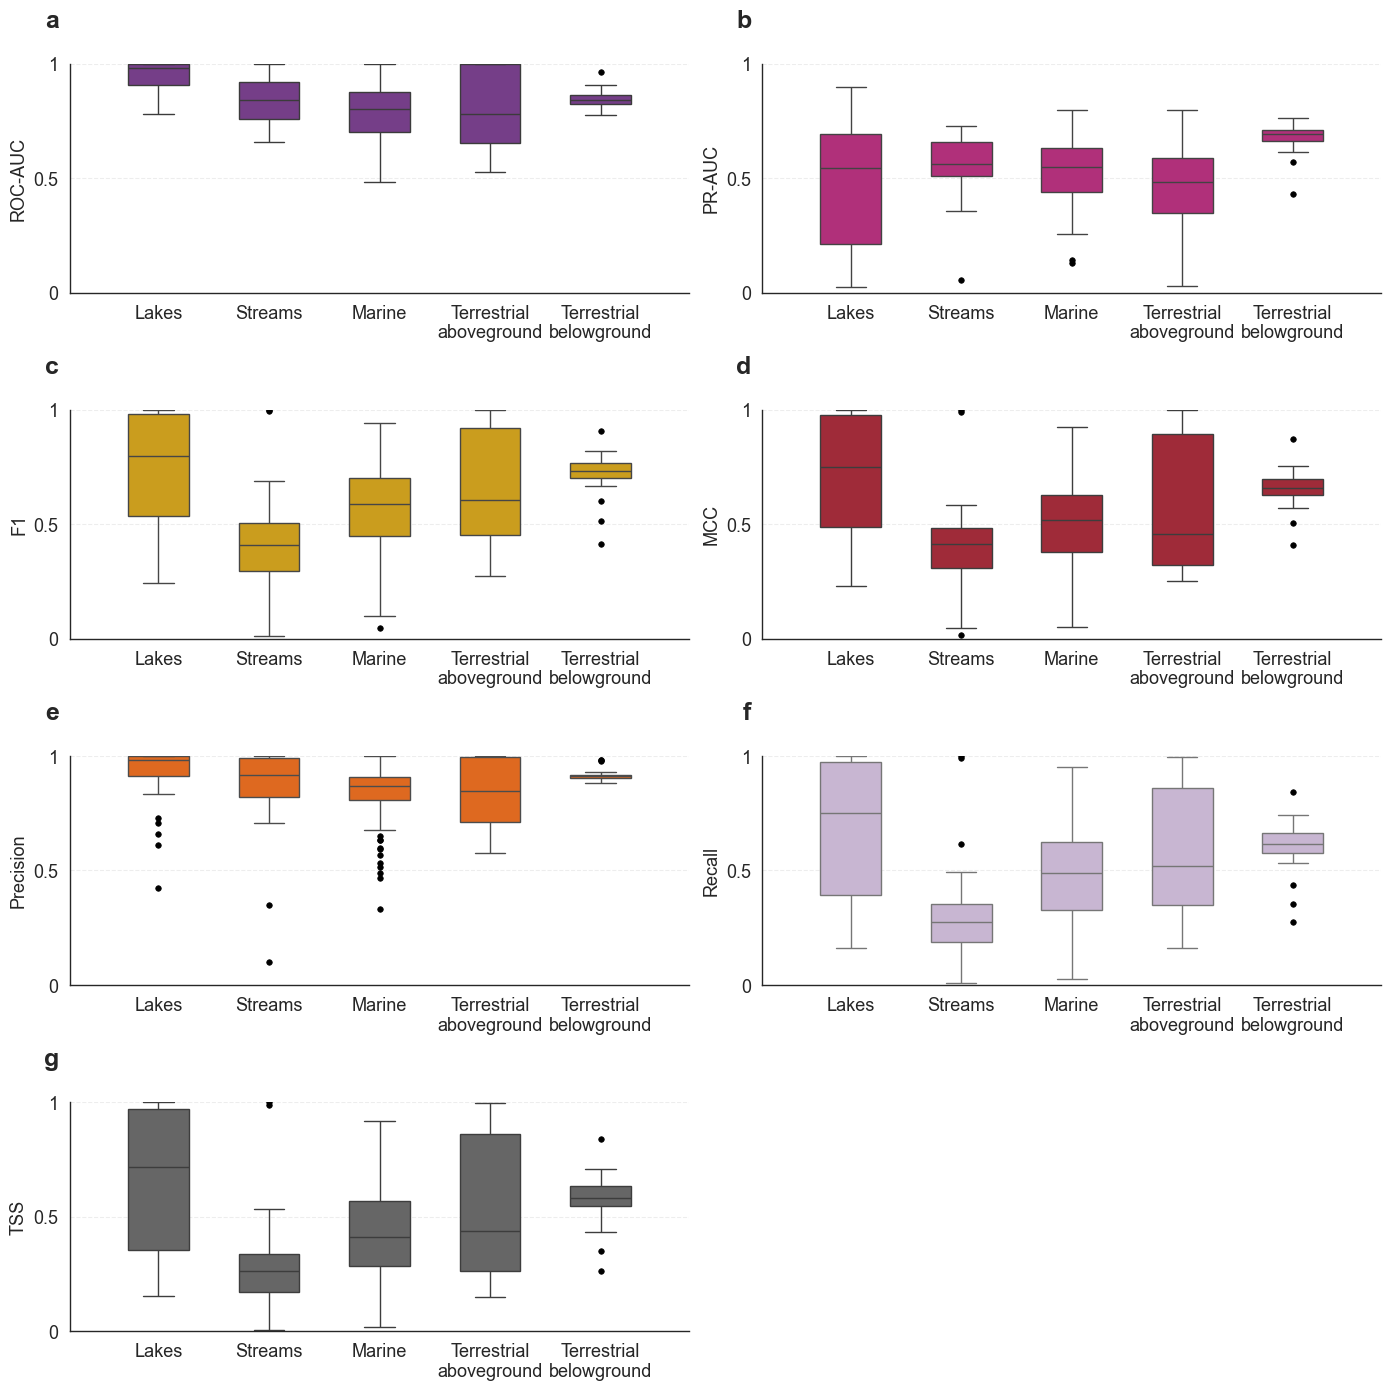

In [49]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_context("paper")
sns.set_style("white")

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
results_dir = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "prediction_scores_logs"
)

ecosystem_file = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / "predictive_metrics_wlnm_dir_neg_train60_by_ecosystem_web_level.png"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]
xtick_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC", "Precision", "Recall", "TSS"]

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

SHOW_WEB_LEVEL_FLIERS = True

metric_palette = {
    "ROC_AUC": "#7B3294",
    "PR_AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1Score": "#E6AB02",
    "TestMCC": "#B2182B",
    "TestTSS": "#666666",
    "TestTPR": "#1B9E77",
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
    "TestTPR": "TPR",
}

# ============================================================
# Load ecosystem metadata
# ============================================================
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one, e.g. 'S', 'nodes', 'num_species', or 'node_count'."
    )

# ============================================================
# Load result CSVs
# ============================================================
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# ============================================================
# Filter TrainRatio = 60
# ============================================================
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

for metric in METRIC_ORDER:
    if metric in df_all.columns:
        df_all[metric] = pd.to_numeric(df_all[metric], errors="coerce")
    else:
        raise RuntimeError(f"Metric column '{metric}' not found in result CSVs.")

print(f"[INFO] Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")
print(f"[INFO] Run-level rows after TrainRatio filter: {len(df_all):,}")

# ============================================================
# Merge metrics with ecosystem metadata
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left",
)

# ============================================================
# Apply node-count filter
# ============================================================
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"[INFO] Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

if df_merged.empty:
    raise ValueError(f"No food webs left after filtering Nodes >= {MIN_NODES}.")

print("\n[INFO] Run-level observations after filtering:")
print(f"Total rows in df_merged: {len(df_merged):,}")
print("Rows per ecosystem:")
print(df_merged.groupby("EcosystemType").size())

# ============================================================
# Key correction: web-level aggregation
# ============================================================
# Each food web contributes one observation per metric.
# The 20 repeated WLNM runs are averaged before plotting.
agg_dict = {metric: "mean" for metric in METRIC_ORDER}
agg_dict.update({
    "Iteration": "count",
    node_col: "first",
})

df_web = (
    df_merged
    .groupby(["Foodweb", "EcosystemType"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"Iteration": "RunsAveraged"})
)

print("\n[INFO] Web-level observations after averaging repeated runs:")
print(f"Total web-level rows: {len(df_web):,}")
display(
    df_web
    .groupby("EcosystemType")
    .agg(
        FoodWebs=("Foodweb", "nunique"),
        MinRunsAveraged=("RunsAveraged", "min"),
        MedianRunsAveraged=("RunsAveraged", "median"),
        MaxRunsAveraged=("RunsAveraged", "max"),
    )
    .reset_index()
)

# ============================================================
# Precision summary by ecosystem, web-level
# ============================================================
precision_summary = (
    df_web
    .dropna(subset=["EcosystemType", "Precision"])
    .groupby("EcosystemType", as_index=False)
    .agg(
        n_foodwebs=("Foodweb", "nunique"),
        Precision_Median=("Precision", "median"),
        Precision_Variance=("Precision", lambda x: x.var(ddof=1)),
    )
)

precision_summary["Precision_Median"] = precision_summary["Precision_Median"].round(4)
precision_summary["Precision_Variance"] = precision_summary["Precision_Variance"].round(6)

print("\n=== Web-level precision median and variance by ecosystem ===")
display(precision_summary)

lowest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmin()]
highest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmax()]
lowest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmin()]
highest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmax()]

print("\n=== Ecosystems with lowest/highest median precision and variance ===")
print(
    f"Lowest median precision:  {lowest_precision['EcosystemType']} "
    f"(median = {lowest_precision['Precision_Median']}, "
    f"variance = {lowest_precision['Precision_Variance']}, "
    f"n_foodwebs = {lowest_precision['n_foodwebs']})"
)
print(
    f"Highest median precision: {highest_precision['EcosystemType']} "
    f"(median = {highest_precision['Precision_Median']}, "
    f"variance = {highest_precision['Precision_Variance']}, "
    f"n_foodwebs = {highest_precision['n_foodwebs']})"
)
print(
    f"Lowest variance:          {lowest_variance['EcosystemType']} "
    f"(variance = {lowest_variance['Precision_Variance']}, "
    f"median = {lowest_variance['Precision_Median']}, "
    f"n_foodwebs = {lowest_variance['n_foodwebs']})"
)
print(
    f"Highest variance:         {highest_variance['EcosystemType']} "
    f"(variance = {highest_variance['Precision_Variance']}, "
    f"median = {highest_variance['Precision_Median']}, "
    f"n_foodwebs = {highest_variance['n_foodwebs']})"
)

# ============================================================
# Prepare long-format web-level data
# ============================================================
df_plot = df_web.melt(
    id_vars=["Foodweb", "EcosystemType", "RunsAveraged"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)

# ============================================================
# Preferred ecosystem order
# ============================================================
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_web["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# ============================================================
# Labels
# ============================================================
labels_map = (
    df_web[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)

def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    return label_replacements.get(eco_lower, eco_clean.capitalize())

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

subset = df_plot.copy()
subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)

# ============================================================
# Plot
# ============================================================
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        width=0.55,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)
    ax.set_ylim(0, 1.0)
    ax.grid(False, axis="x")

    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()